# Raw Data Audit

## Focus of this stage
- inspect dataset shape and columns
- review data types
- inspect missing and irregular values
- examine the target variable readmitted
- identify likely identifier columns and other issues to address in the cleaning stage

## 1. Load the raw dataset

In this step, I load the main diabetes dataset for the analysis and also keep the ID mapping file available as a reference for interpreting coded variables later if needed. The mapping file is not analysed at this stage.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "README.md").exists()
            or (candidate / "group46_solution.ipynb").exists()
            or (candidate / ".git").exists()
        ):
            return candidate
    return start.resolve()

def resolve_input_file(project_root: Path, filename: str) -> Path:
    candidates = [
        project_root / "data" / "raw" / filename,
        project_root / filename,
        Path.cwd() / "data" / "raw" / filename,
        Path.cwd() / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {filename} in data/raw/ or project root."
    )

def resolve_processed_file(project_root: Path, filename: str) -> Path:
    candidates = [
        project_root / "data" / "processed" / filename,
        project_root / filename,
        Path.cwd() / "data" / "processed" / filename,
        Path.cwd() / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {filename} in data/processed/ or project root."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
MAIN_DATA_PATH = resolve_input_file(PROJECT_ROOT, "diabetic_data.csv")
IDS_MAP_PATH = resolve_input_file(PROJECT_ROOT, "IDS_mapping.csv")

if (PROJECT_ROOT / "data" / "processed").exists():
    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
else:
    PROCESSED_DIR = PROJECT_ROOT

df_raw = pd.read_csv(MAIN_DATA_PATH, dtype=str, keep_default_na=False)
df = df_raw.copy()

print("Project root:", PROJECT_ROOT)
print("Main data path:", MAIN_DATA_PATH, "| exists:", MAIN_DATA_PATH.exists())
print("ID map path:", IDS_MAP_PATH, "| exists:", IDS_MAP_PATH.exists())
print("Processed outputs will save to:", PROCESSED_DIR)
print("Raw dataframe loaded successfully.")
print("Raw shape:", df_raw.shape)
print("Working copy shape:", df.shape)

Project root: /Users/shayan/big data coursework/Group_46
Main data path: /Users/shayan/big data coursework/Group_46/diabetic_data.csv | exists: True
ID map path: /Users/shayan/big data coursework/Group_46/IDS_mapping.csv | exists: True
Processed outputs will save to: /Users/shayan/big data coursework/Group_46
Raw dataframe loaded successfully.
Raw shape: (101766, 50)
Working copy shape: (101766, 50)


## 2. Basic dataset overview


In [2]:
n_rows, n_cols = df_raw.shape

print(f"Raw dataset shape: {n_rows:,} rows x {n_cols} columns")
print("\nColumn names:")
display(pd.DataFrame({"column_name": df_raw.columns}))

print("\nFirst 5 rows:")
display(df_raw.head())

Raw dataset shape: 101,766 rows x 50 columns

Column names:


,column_name
0,encounter_id
1,patient_nbr
2,race
3,gender
4,age
5,weight
6,admission_type_id
7,discharge_disposition_id
8,admission_source_id
9,time_in_hospital



First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Data types audit

In [3]:
print("Loaded pandas dtypes:")
display(df_raw.dtypes.rename("loaded_dtype").to_frame())

print("\nLoaded dtype counts:")
display(df_raw.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="count"))

Loaded pandas dtypes:


,loaded_dtype
encounter_id,str
patient_nbr,str
race,str
gender,str
age,str
weight,str
admission_type_id,str
discharge_disposition_id,str
admission_source_id,str
time_in_hospital,str



Loaded dtype counts:


,dtype,count
0,str,50


In [4]:
def numeric_like_ratio(series):
    temp = series.replace({"": np.nan, "?": np.nan})
    temp = temp[temp.notna()]
    if len(temp) == 0:
        return np.nan
    converted = pd.to_numeric(temp, errors="coerce")
    return converted.notna().mean()

type_audit = pd.DataFrame({
    "loaded_dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(dropna=False),
    "numeric_like_ratio": [numeric_like_ratio(df_raw[col]) for col in df_raw.columns]
}, index=df_raw.columns)

type_audit["likely_future_type"] = np.select(
    [
        type_audit["numeric_like_ratio"].eq(1.0),
        type_audit["numeric_like_ratio"].ge(0.8)
    ],
    [
        "numeric-looking or coded-ID",
        "mostly numeric-looking"
    ],
    default="categorical/text-looking"
)

display(type_audit.sort_values(["likely_future_type", "n_unique"]))

,loaded_dtype,n_unique,numeric_like_ratio,likely_future_type
examide,str,1,0.000000,categorical/text-looking
citoglipton,str,1,0.000000,categorical/text-looking
acetohexamide,str,2,0.000000,categorical/text-looking
tolbutamide,str,2,0.000000,categorical/text-looking
troglitazone,str,2,0.000000,categorical/text-looking
glipizide-metformin,str,2,0.000000,categorical/text-looking
glimepiride-pioglitazone,str,2,0.000000,categorical/text-looking
metformin-rosiglitazone,str,2,0.000000,categorical/text-looking
metformin-pioglitazone,str,2,0.000000,categorical/text-looking
change,str,2,0.000000,categorical/text-looking


In [5]:
key_cols = [
    "encounter_id", "patient_nbr", "age", "time_in_hospital",
    "num_lab_procedures", "num_procedures", "num_medications",
    "number_outpatient", "number_emergency", "number_inpatient",
    "number_diagnoses", "readmitted"
]

display(type_audit.loc[key_cols])

,loaded_dtype,n_unique,numeric_like_ratio,likely_future_type
encounter_id,str,101766,1.0,numeric-looking or coded-ID
patient_nbr,str,71518,1.0,numeric-looking or coded-ID
age,str,10,0.0,categorical/text-looking
time_in_hospital,str,14,1.0,numeric-looking or coded-ID
num_lab_procedures,str,118,1.0,numeric-looking or coded-ID
num_procedures,str,7,1.0,numeric-looking or coded-ID
num_medications,str,75,1.0,numeric-looking or coded-ID
number_outpatient,str,39,1.0,numeric-looking or coded-ID
number_emergency,str,33,1.0,numeric-looking or coded-ID
number_inpatient,str,21,1.0,numeric-looking or coded-ID


## 4. Missing and irregular values audit

In [6]:
raw_missing_snapshot = pd.DataFrame({
    "na_count_raw_load": df_raw.isna().sum(),
    "empty_string_count": df_raw.eq("").sum(),
    "question_mark_count": df_raw.eq("?").sum(),
    "literal_None_count": df_raw.eq("None").sum()
}, index=df_raw.columns)

display(raw_missing_snapshot.sort_values(
    by=["question_mark_count", "empty_string_count", "literal_None_count", "na_count_raw_load"],
    ascending=False
).head(20))

,na_count_raw_load,empty_string_count,question_mark_count,literal_None_count
weight,0,0,98569,0
medical_specialty,0,0,49949,0
payer_code,0,0,40256,0
race,0,0,2273,0
diag_3,0,0,1423,0
diag_2,0,0,358,0
diag_1,0,0,21,0
max_glu_serum,0,0,0,96420
A1Cresult,0,0,0,84748
encounter_id,0,0,0,0


In [7]:
df_audit_missing = df_raw.replace({"?": np.nan, "": np.nan})

missing_summary = pd.DataFrame({
    "missing_count_if_standardised": df_audit_missing.isna().sum(),
    "missing_pct_if_standardised": (df_audit_missing.isna().sum() / len(df_audit_missing) * 100).round(2),
    "question_mark_count": df_raw.eq("?").sum(),
    "empty_string_count": df_raw.eq("").sum(),
    "literal_None_count": df_raw.eq("None").sum()
}, index=df_raw.columns).sort_values("missing_pct_if_standardised", ascending=False)

display(missing_summary.head(25))

,missing_count_if_standardised,missing_pct_if_standardised,question_mark_count,empty_string_count,literal_None_count
weight,98569,96.86,98569,0,0
medical_specialty,49949,49.08,49949,0,0
payer_code,40256,39.56,40256,0,0
race,2273,2.23,2273,0,0
diag_3,1423,1.40,1423,0,0
diag_2,358,0.35,358,0,0
diag_1,21,0.02,21,0,0
encounter_id,0,0.00,0,0,0
tolazamide,0,0.00,0,0,0
glyburide,0,0.00,0,0,0


## 5. Target variable audit: readmitted

In [8]:
print("Unique raw values in readmitted:")
print(sorted(df_raw["readmitted"].unique().tolist()))

target_counts = df_raw["readmitted"].value_counts(dropna=False)
target_props = (df_raw["readmitted"].value_counts(dropna=False, normalize=True) * 100).round(2)

target_audit = pd.DataFrame({
    "count": target_counts,
    "percentage": target_props
})

display(target_audit)

Unique raw values in readmitted:
['<30', '>30', 'NO']


,count,percentage
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


In [9]:
minority_class = target_counts.idxmin()
minority_count = target_counts.min()
majority_count = target_counts.max()

print(f"Minority class: {minority_class}")
print(f"Minority count: {minority_count:,}")
print(f"Majority count: {majority_count:,}")
print(f"Minority / majority ratio: {minority_count / majority_count:.4f}")

Minority class: <30
Minority count: 11,357
Majority count: 54,864
Minority / majority ratio: 0.2070



## 6. Likely identifier and low-information columns

In [10]:
uniqueness_summary = pd.DataFrame({
    "n_unique": df_raw.nunique(dropna=False),
    "unique_ratio": (df_raw.nunique(dropna=False) / len(df_raw)).round(4)
}, index=df_raw.columns).sort_values("unique_ratio", ascending=False)

display(uniqueness_summary.head(15))

,n_unique,unique_ratio
encounter_id,101766,1.0000
patient_nbr,71518,0.7028
diag_3,790,0.0078
diag_2,749,0.0074
diag_1,717,0.0070
num_lab_procedures,118,0.0012
num_medications,75,0.0007
medical_specialty,73,0.0007
number_outpatient,39,0.0004
discharge_disposition_id,26,0.0003


In [11]:
for col in ["encounter_id", "patient_nbr"]:
    unique_count = df_raw[col].nunique(dropna=False)
    print(f"{col}: {unique_count:,} unique values out of {len(df_raw):,} rows")

encounter_id: 101,766 unique values out of 101,766 rows
patient_nbr: 71,518 unique values out of 101,766 rows


In [12]:
def top_frequency_pct(series):
    return float(series.value_counts(dropna=False, normalize=True).iloc[0] * 100)

low_info_summary = pd.DataFrame({
    "n_unique": df_raw.nunique(dropna=False),
    "top_value": [df_raw[col].value_counts(dropna=False).index[0] for col in df_raw.columns],
    "top_value_pct": [round(top_frequency_pct(df_raw[col]), 2) for col in df_raw.columns]
}, index=df_raw.columns).sort_values(
    by=["n_unique", "top_value_pct"], ascending=[True, False]
)

constant_columns = low_info_summary[low_info_summary["n_unique"] == 1]
near_zero_candidates = low_info_summary[
    (low_info_summary["n_unique"] <= 3) &
    (low_info_summary["top_value_pct"] >= 99)
]

print("Constant columns:")
display(constant_columns)

print("\nNear-zero-variation candidates:")
display(near_zero_candidates)

Constant columns:


,n_unique,top_value,top_value_pct
examide,1,No,100.0
citoglipton,1,No,100.0



Near-zero-variation candidates:


,n_unique,top_value,top_value_pct
examide,1,No,100.00
citoglipton,1,No,100.00
acetohexamide,2,No,100.00
troglitazone,2,No,100.00
glimepiride-pioglitazone,2,No,100.00
metformin-rosiglitazone,2,No,100.00
metformin-pioglitazone,2,No,100.00
glipizide-metformin,2,No,99.99
tolbutamide,2,No,99.98
tolazamide,3,No,99.96


## 7. Duplicate row check

In [13]:
duplicate_row_count = df_raw.duplicated().sum()

print(f"Number of duplicate full rows: {duplicate_row_count:,}")
print(f"Percentage of duplicate full rows: {duplicate_row_count / len(df_raw) * 100:.4f}%")

Number of duplicate full rows: 0
Percentage of duplicate full rows: 0.0000%


In [14]:
if duplicate_row_count > 0:
    display(df_raw[df_raw.duplicated(keep=False)].head(20))
else:
    print("No duplicate full rows found.")

No duplicate full rows found.


## 8. Patient repeat audit

In [15]:
patient_counts = df_raw["patient_nbr"].value_counts(dropna=False)

n_unique_patients = patient_counts.shape[0]
n_total_rows = len(df_raw)
n_patients_multiple = (patient_counts > 1).sum()
pct_rows_unique_patient = (n_unique_patients / n_total_rows) * 100
pct_patients_multiple = (n_patients_multiple / n_unique_patients) * 100

print(f"Total rows (encounters): {n_total_rows:,}")
print(f"Unique patients: {n_unique_patients:,}")
print(f"Patients with multiple encounters: {n_patients_multiple:,}")
print(f"Unique patients as % of rows: {pct_rows_unique_patient:.2f}%")
print(f"Patients with multiple encounters as % of unique patients: {pct_patients_multiple:.2f}%")

Total rows (encounters): 101,766
Unique patients: 71,518
Patients with multiple encounters: 16,773
Unique patients as % of rows: 70.28%
Patients with multiple encounters as % of unique patients: 23.45%


In [16]:
patient_repeat_summary = patient_counts.value_counts().sort_index().rename_axis("encounter_count").reset_index(name="number_of_patients")
display(patient_repeat_summary.head(15))

,encounter_count,number_of_patients
0,1,54745
1,2,10434
2,3,3328
3,4,1421
4,5,717
5,6,346
6,7,207
7,8,111
8,9,70
9,10,42


## 9. Key category audit

In [17]:
key_categorical_cols = [
    "gender",
    "race",
    "age",
    "change",
    "diabetesMed",
    "max_glu_serum",
    "A1Cresult"
]

for col in key_categorical_cols:
    print(f"\n--- {col} ---")
    display(df_raw[col].value_counts(dropna=False).to_frame(name="count"))


--- gender ---


,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3



--- race ---


,count
race,
Caucasian,76099
AfricanAmerican,19210
?,2273
Hispanic,2037
Other,1506
Asian,641



--- age ---


...

,count
diabetesMed,
Yes,78363
No,23403



--- max_glu_serum ---


,count
max_glu_serum,
None,96420
Norm,2597
>200,1485
>300,1264



--- A1Cresult ---


,count
A1Cresult,
None,84748
>8,8216
Norm,4990
>7,3812


## 10. Diagnosis code format audit

In [18]:
diag_cols = ["diag_1", "diag_2", "diag_3"]

for col in diag_cols:
    temp = df_raw[col].replace({"?": np.nan, "": np.nan})
    non_numeric_values = temp[pd.to_numeric(temp, errors="coerce").isna() & temp.notna()]
    
    print(f"\n--- {col} ---")
    print(f"Unique non-numeric examples: {non_numeric_values.nunique()}")
    display(non_numeric_values.value_counts().head(20).to_frame(name="count"))


--- diag_1 ---
Unique non-numeric examples: 19


,count
diag_1,
V57,1207
V58,228
V55,71
V54,45
V53,44
V56,16
V71,9
V63,8
V45,5



--- diag_2 ---
Unique non-numeric examples: 98


,count
diag_2,
V45,408
V42,264
V85,169
V58,157
V43,130
V15,128
E878,113
E885,112
E888,109



--- diag_3 ---
Unique non-numeric examples: 119


,count
diag_3,
V45,1389
V58,501
V15,334
V42,243
V10,239
E849,219
V43,211
V12,204
E878,164


## 11. Numeric-like range audit

In [19]:
numeric_like_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

numeric_range_summary = []

for col in numeric_like_cols:
    temp = pd.to_numeric(df_raw[col], errors="coerce")
    numeric_range_summary.append({
        "column": col,
        "min": temp.min(),
        "max": temp.max(),
        "mean": round(temp.mean(), 2),
        "median": temp.median(),
        "n_missing_after_numeric_cast": temp.isna().sum()
    })

numeric_range_summary = pd.DataFrame(numeric_range_summary)
display(numeric_range_summary)

,column,min,max,mean,median,n_missing_after_numeric_cast
0,time_in_hospital,1,14,4.40,4.0,0
1,num_lab_procedures,1,132,43.10,44.0,0
2,num_procedures,0,6,1.34,1.0,0
3,num_medications,1,81,16.02,15.0,0
4,number_outpatient,0,42,0.37,0.0,0
5,number_emergency,0,76,0.20,0.0,0
6,number_inpatient,0,21,0.64,0.0,0
7,number_diagnoses,1,16,7.42,8.0,0


In [20]:
for col in numeric_like_cols:
    temp = pd.to_numeric(df_raw[col], errors="coerce")
    print(f"\n--- {col} ---")
    display(temp.describe().to_frame(name="value"))


--- time_in_hospital ---


,value
count,101766.000000
mean,4.395987
std,2.985108
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,14.000000



--- num_lab_procedures ---


,value
count,101766.000000
mean,43.095641
std,19.674362
min,1.000000
25%,31.000000
50%,44.000000
75%,57.000000
max,132.000000



--- num_procedures ---


...

,value
count,101766.000000
mean,0.197836
std,0.930472
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,76.000000



--- number_inpatient ---


,value
count,101766.000000
mean,0.635566
std,1.262863
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,21.000000



--- number_diagnoses ---


,value
count,101766.000000
mean,7.422607
std,1.933600
min,1.000000
25%,6.000000
50%,8.000000
75%,9.000000
max,16.000000


## 12. Initial audit summary

### 12. Initial audit summary

The raw dataset contains 101,766 rows and 50 columns. It was loaded as text for audit purposes so that placeholders, mixed-format values, and coded categories could be inspected safely before cleaning. Missingness is concentrated mainly in a few columns, especially weight, medical_specialty, and payer_code, while max_glu_serum and A1Cresult contain many literal None values that require careful interpretation. The target variable readmitted contains the raw classes <30, >30, and NO, with <30 forming the minority class. The dataset is encounter-level rather than patient-level, identifier columns such as encounter_id and patient_nbr were flagged, and the diagnosis fields diag_1, diag_2, and diag_3 were identified as mixed-format clinical code fields that should not be treated as ordinary numeric variables.

# Cleaning and Preprocessing

## Focus of this stage
- create a working copy of the raw dataset
- standardise missing-value placeholders
- reassess missingness after standardisation
- review identifier and low-information columns
- justify high-missingness decisions
- prepare the target variable for later modelling
- convert suitable columns into analysis-ready types
- save cleaned outputs for downstream tasks

## 1. Load the raw dataset and create a working copy

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "README.md").exists()
            or (candidate / "group46_solution.ipynb").exists()
            or (candidate / ".git").exists()
        ):
            return candidate
    return start.resolve()

def resolve_input_file(project_root: Path, filename: str) -> Path:
    candidates = [
        project_root / "data" / "raw" / filename,
        project_root / filename,
        Path.cwd() / "data" / "raw" / filename,
        Path.cwd() / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {filename} in data/raw/ or project root."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
MAIN_DATA_PATH = resolve_input_file(PROJECT_ROOT, "diabetic_data.csv")


if (PROJECT_ROOT / "data" / "processed").exists():
    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
else:
    PROCESSED_DIR = PROJECT_ROOT

df_raw = pd.read_csv(MAIN_DATA_PATH, dtype=str, keep_default_na=False)
df = df_raw.copy()

print("Project root:", PROJECT_ROOT)
print("Raw data path:", MAIN_DATA_PATH)
print("Processed outputs will save to:", PROCESSED_DIR)
print("Raw shape:", df_raw.shape)
print("Working copy shape:", df.shape)
print("Raw and working copy created successfully.")

Project root: /Users/shayan/big data coursework/Group_46
Raw data path: /Users/shayan/big data coursework/Group_46/diabetic_data.csv
Processed outputs will save to: /Users/shayan/big data coursework/Group_46
Raw shape: (101766, 50)
Working copy shape: (101766, 50)
Raw and working copy created successfully.


### Observation
The raw dataset was loaded successfully and a separate working dataframe was created so that all cleaning steps remain reproducible without altering the original raw file.

## 2. Standardise missing-value placeholders

In this step, the placeholder ? is converted into NaN within the working dataframe so that missingness can be measured and handled consistently in later stages. At this point, literal values such as None are not converted automatically because they may carry specific meaning in some categorical laboratory-result fields.

In [22]:
question_mark_before = df.eq("?").sum().sort_values(ascending=False)
question_mark_before_nonzero = question_mark_before[question_mark_before > 0]

print("Columns containing '?' before standardisation:")
display(question_mark_before_nonzero.to_frame(name="question_mark_count"))

Columns containing '?' before standardisation:


,question_mark_count
weight,98569
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21


In [23]:
df = df.replace("?", np.nan)

question_mark_after = df.eq("?").sum().sum()
total_missing_after = df.isna().sum().sum()

print("Total '?' remaining after standardisation:", question_mark_after)
print("Total missing values after standardising '?':", int(total_missing_after))

Total '?' remaining after standardisation: 0
Total missing values after standardising '?': 192849


### Observation
After standardising ? to NaN, missingness becomes explicit in the working dataframe, with no ? values remaining. The missingness is concentrated mainly in weight, medical_specialty, and payer_code, rather than being spread evenly across the dataset.

## 3. Reassess missingness after standardisation

This section reassesses missingness after standardising ? to NaN in the working dataframe. The goal is to identify which columns are genuinely affected by missingness and to quantify how concentrated that missingness is.


In [24]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)

display(missing_summary.head(20))

,missing_count,missing_pct
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
encounter_id,0,0.00
tolazamide,0,0.00
glyburide,0,0.00


In [25]:
missing_nonzero = missing_summary[missing_summary["missing_count"] > 0]
display(missing_nonzero)

,missing_count,missing_pct
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


In [26]:
n_cols_with_missing = (missing_summary["missing_count"] > 0).sum()
n_total_cols = df.shape[1]
top3_missing_pct = missing_summary.head(3)["missing_pct"].tolist()

print(f"Columns with non-zero missingness: {n_cols_with_missing} out of {n_total_cols}")
print(f"Top 3 missingness percentages: {top3_missing_pct}")

Columns with non-zero missingness: 7 out of 50
Top 3 missingness percentages: [96.86, 49.08, 39.56]


### Observation
After standardisation, non-zero missingness is limited to only 7 of the 50 columns, showing that missingness is concentrated rather than widespread. The most affected features are weight, medical_specialty, and payer_code, which are therefore the main candidates for closer review in the next cleaning decisions.

## 4. Review special categorical values

This section reviews unusual categorical values that may require careful interpretation during cleaning. In particular, it distinguishes between placeholder-style missingness and values that may represent meaningful categories, such as laboratory tests that were not measured.

In [27]:
special_cols = ["gender", "race", "max_glu_serum", "A1Cresult"]

for col in special_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).to_frame(name="count"))


--- gender ---


,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3



--- race ---


,count
race,
Caucasian,76099
AfricanAmerican,19210
NaN,2273
Hispanic,2037
Other,1506
Asian,641



--- max_glu_serum ---


,count
max_glu_serum,
None,96420
Norm,2597
>200,1485
>300,1264



--- A1Cresult ---


,count
A1Cresult,
None,84748
>8,8216
Norm,4990
>7,3812


### Observation
This review shows that unusual categorical values do not all represent the same issue. While race now contains explicit missing values after placeholder standardisation, the value None in max_glu_serum and A1Cresult appears to represent a meaningful test-status category rather than ordinary missingness and should therefore be preserved at this stage.

## 5. Remove identifier columns

The identifier columns are removed at this stage because they do not represent general clinical predictors and are unlikely to support meaningful generalisation in later modelling.

In [28]:
shape_before_id_drop = df.shape
id_columns_to_drop = ["encounter_id", "patient_nbr"]

df = df.drop(columns=id_columns_to_drop)

shape_after_id_drop = df.shape

print("Shape before dropping identifier columns:", shape_before_id_drop)
print("Shape after dropping identifier columns:", shape_after_id_drop)
print("Dropped columns:", id_columns_to_drop)

Shape before dropping identifier columns: (101766, 50)
Shape after dropping identifier columns: (101766, 48)
Dropped columns: ['encounter_id', 'patient_nbr']


### Observation
The two identifier columns were removed without affecting the number of rows in the dataset. This reduces the risk of including non-generalisable record identifiers in later modelling while preserving all encounter observations.

## 6. Remove constant columns

Columns with only a single repeated value provide no discriminative information for later modelling. These are removed directly at this stage.

In [29]:
nunique_current = df.nunique(dropna=False)
constant_columns_to_drop = nunique_current[nunique_current == 1].index.tolist()

shape_before_constant_drop = df.shape
df = df.drop(columns=constant_columns_to_drop)
shape_after_constant_drop = df.shape

print("Constant columns identified:", constant_columns_to_drop)
print("Shape before dropping constant columns:", shape_before_constant_drop)
print("Shape after dropping constant columns:", shape_after_constant_drop)

Constant columns identified: ['examide', 'citoglipton']
Shape before dropping constant columns: (101766, 48)
Shape after dropping constant columns: (101766, 46)


### Observation
The two constant columns, examide and citoglipton, were removed because they contained no variation and therefore no useful predictive signal. This reduced the dataset from 48 to 46 columns without affecting the number of rows.

## 7. Review near-zero-variation features

Features with extremely low variation may contribute limited predictive value, especially when one category dominates almost all observations. This section reviews such columns before deciding whether any should be removed.

In [30]:
def top_frequency_pct(series):
    return float(series.value_counts(dropna=False, normalize=True).iloc[0] * 100)

nzv_summary = pd.DataFrame({
    "n_unique": df.nunique(dropna=False),
    "top_value": [df[col].value_counts(dropna=False).index[0] for col in df.columns],
    "top_value_pct": [round(top_frequency_pct(df[col]), 2) for col in df.columns]
}, index=df.columns).sort_values(
    by=["n_unique", "top_value_pct"], ascending=[True, False]
)

near_zero_candidates = nzv_summary[
    (nzv_summary["n_unique"] <= 3) &
    (nzv_summary["top_value_pct"] >= 99)
]

display(near_zero_candidates)

,n_unique,top_value,top_value_pct
acetohexamide,2,No,100.00
troglitazone,2,No,100.00
glimepiride-pioglitazone,2,No,100.00
metformin-rosiglitazone,2,No,100.00
metformin-pioglitazone,2,No,100.00
glipizide-metformin,2,No,99.99
tolbutamide,2,No,99.98
tolazamide,3,No,99.96


### Observation
Several medication-related columns show extremely low variation, with No accounting for almost all observations. These features are therefore strong candidates for removal or careful review, although they are not dropped automatically at this stage without explicit justification.

## 8. Review high-missingness columns


Features with very high levels of missingness may contribute less reliable information and can complicate later modelling. This section reviews high-missingness columns explicitly so that any removals remain transparent and evidence-based.


In [31]:
high_missing_threshold = 30.0

high_missing_cols = missing_summary[missing_summary["missing_pct"] >= high_missing_threshold].copy()
display(high_missing_cols)

,missing_count,missing_pct
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56


### Observation
Using a 30% missingness threshold, only three columns qualify as high-missingness features: weight, medical_specialty, and payer_code. These columns therefore require explicit review before constructing the aggressively cleaned dataset.

## 9. Drop high-missingness columns for the aggressive cleaned dataset

For the aggressively cleaned dataset, columns with very high missingness are removed to simplify the initial preprocessing pipeline and reduce reliance on weakly supported imputations. This decision is specific to the aggressive-cleaning version and may be revisited differently in the improved modelling stage.

In [32]:
high_missing_cols_to_drop = high_missing_cols.index.tolist()

shape_before_high_missing_drop = df.shape
df = df.drop(columns=high_missing_cols_to_drop)
shape_after_high_missing_drop = df.shape

print("Dropped high-missingness columns:", high_missing_cols_to_drop)
print("Shape before dropping high-missingness columns:", shape_before_high_missing_drop)
print("Shape after dropping high-missingness columns:", shape_after_high_missing_drop)

Dropped high-missingness columns: ['weight', 'medical_specialty', 'payer_code']
Shape before dropping high-missingness columns: (101766, 46)
Shape after dropping high-missingness columns: (101766, 43)


### Observation
The three high-missingness columns were removed from the aggressive cleaned dataset without reducing the number of rows. This simplifies the initial preprocessing pipeline while avoiding dependence on weakly supported imputations for features with substantial missingness.

## 10. Prepare the target variable

The original readmitted column is transformed into a binary target for early readmission. In this formulation, <30 is treated as the positive class, while >30 and NO are grouped into the non-early-readmission class.

In [33]:
df["readmitted_binary"] = df["readmitted"].map({
    "<30": 1,
    ">30": 0,
    "NO": 0
})

target_binary_counts = df["readmitted_binary"].value_counts(dropna=False).sort_index()
target_binary_pct = (df["readmitted_binary"].value_counts(dropna=False, normalize=True) * 100).round(2).sort_index()

target_binary_summary = pd.DataFrame({
    "count": target_binary_counts,
    "percentage": target_binary_pct
})

display(target_binary_summary)
print("Missing values in readmitted_binary:", int(df["readmitted_binary"].isna().sum()))

,count,percentage
readmitted_binary,,
0,90409,88.84
1,11357,11.16


Missing values in readmitted_binary: 0


### Observation
The target variable was successfully converted into a binary early-readmission outcome with no missing values introduced. The resulting class distribution remains clearly imbalanced, with early readmission (`1`) representing 11.16% of the dataset.

## 11. Convert columns to analysis-ready types

This section converts columns according to their analytical role. Count-style hospital-use variables are converted to numeric form, while coded identifiers and mixed-format clinical code fields are kept out of naive continuous numeric casting.

In [34]:
numeric_count_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "readmitted_binary"
]

for col in numeric_count_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

dtype_summary_after_conversion = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "n_unique": df.nunique(dropna=False)
}).sort_values(["dtype", "n_unique"])

display(dtype_summary_after_conversion)

,dtype,missing_count,n_unique
readmitted_binary,int64,0,2
num_procedures,int64,0,7
time_in_hospital,int64,0,14
number_diagnoses,int64,0,16
number_inpatient,int64,0,21
number_emergency,int64,0,33
number_outpatient,int64,0,39
num_medications,int64,0,75
num_lab_procedures,int64,0,118
acetohexamide,str,0,2


### Observation
The main count-style hospital-use variables were successfully converted into numeric form without introducing missing values. Categorical fields and mixed-format diagnosis-code columns were intentionally retained as non-numeric values so that they are not mistakenly treated as continuous measurements.

## 12. Review numeric summaries and preprocessing needs

This section reviews the main numeric variables after datatype conversion. The goal is to confirm that the converted features remain structurally sensible and to identify any preprocessing considerations such as skewness, scaling needs, or potential outlier sensitivity.

In [35]:
numeric_summary = df[numeric_count_cols].describe().T
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0
readmitted_binary,101766.0,0.111599,0.314874,0.0,0.0,0.0,0.0,1.0


In [36]:
skew_like_summary = pd.DataFrame({
    "median": df[numeric_count_cols].median(),
    "mean": df[numeric_count_cols].mean().round(2),
    "max": df[numeric_count_cols].max(),
    "zero_count": (df[numeric_count_cols] == 0).sum()
}).sort_values("max", ascending=False)

display(skew_like_summary)

,median,mean,max,zero_count
num_lab_procedures,44.0,43.10,132,0
num_medications,15.0,16.02,81,0
number_emergency,0.0,0.20,76,90383
number_outpatient,0.0,0.37,42,85027
number_inpatient,0.0,0.64,21,67630
number_diagnoses,8.0,7.42,16,0
time_in_hospital,4.0,4.40,14,0
num_procedures,1.0,1.34,6,46652
readmitted_binary,0.0,0.11,1,90409


### Observation
The converted numeric features appear structurally plausible and consistent with encounter-level healthcare data. Several visit-count variables are strongly right-skewed, with many zero values and relatively high maxima, indicating that later preprocessing decisions such as scaling or outlier-sensitive handling should depend on the modelling method rather than automatic removal.

## 13. Load and inspect the ID mapping file

This section inspects the ID mapping file so that coded fields such as admission_type_id, discharge_disposition_id, and admission_source_id can be interpreted correctly before further cleaning decisions are made.

In [37]:
ids_mapping_path = resolve_input_file(PROJECT_ROOT, "IDS_mapping.csv")
ids_raw = pd.read_csv(ids_mapping_path, header=None)

print("IDS mapping path:", ids_mapping_path)
print("IDS mapping raw shape:", ids_raw.shape)
display(ids_raw.head(40))

IDS mapping path: /Users/shayan/big data coursework/Group_46/IDS_mapping.csv
IDS mapping raw shape: (68, 2)


,0,1
0,admission_type_id,description
1,1,Emergency
2,2,Urgent
3,3,Elective
4,4,Newborn
5,5,Not Available
6,6,NaN
7,7,Trauma Center
8,8,Not Mapped
9,NaN,NaN


In [38]:
display(ids_raw.tail(40))

,0,1
28,18,NaN
29,19,"Expired at home. Medicaid only, hospice."
30,20,"Expired in a medical facility. Medicaid only, ..."
31,21,"Expired, place unknown. Medicaid only, hospice."
32,22,Discharged/transferred to another rehab fac in...
33,23,Discharged/transferred to a long term care hos...
34,24,Discharged/transferred to a nursing facility c...
35,25,Not Mapped
36,26,Unknown/Invalid
37,30,Discharged/transferred to another Type of Heal...


### Observation
The ID mapping file is not a single clean lookup table; instead, it contains three stacked mapping sections for admission_type_id, discharge_disposition_id, and admission_source_id. This means the file must be parsed carefully before it can be used for cleaning decisions such as identifying expired discharge outcomes.

## 14. Review admission type and admission source mappings

This section reviews the admission_type_id and admission_source_id fields using the ID mapping file. These variables are coded categorical fields rather than ordinary numeric measurements, so their meanings should be checked before later exploratory analysis and modelling.

In [39]:
admission_type_start = ids_raw.index[ids_raw[0] == "admission_type_id"][0] + 1
discharge_start_raw = ids_raw.index[ids_raw[0] == "discharge_disposition_id"][0]

admission_type_map = ids_raw.iloc[admission_type_start:discharge_start_raw].copy()
admission_type_map.columns = ["admission_type_id", "description"]
admission_type_map = admission_type_map.dropna(how="all")
admission_type_map["admission_type_id"] = pd.to_numeric(admission_type_map["admission_type_id"], errors="coerce")
admission_type_map = admission_type_map.dropna(subset=["admission_type_id"])
admission_type_map["admission_type_id"] = admission_type_map["admission_type_id"].astype(int).astype(str)

admission_source_start = ids_raw.index[ids_raw[0] == "admission_source_id"][0] + 1

admission_source_map = ids_raw.iloc[admission_source_start:].copy()
admission_source_map.columns = ["admission_source_id", "description"]
admission_source_map = admission_source_map.dropna(how="all")
admission_source_map["admission_source_id"] = pd.to_numeric(admission_source_map["admission_source_id"], errors="coerce")
admission_source_map = admission_source_map.dropna(subset=["admission_source_id"])
admission_source_map["admission_source_id"] = admission_source_map["admission_source_id"].astype(int).astype(str)

display(admission_type_map)
display(admission_source_map)

,admission_type_id,description
1,1,Emergency
2,2,Urgent
3,3,Elective
4,4,Newborn
5,5,Not Available
6,6,NaN
7,7,Trauma Center
8,8,Not Mapped


,admission_source_id,description
43,1,Physician Referral
44,2,Clinic Referral
45,3,HMO Referral
46,4,Transfer from a hospital
47,5,Transfer from a Skilled Nursing Facility (SNF)
48,6,Transfer from another health care facility
49,7,Emergency Room
50,8,Court/Law Enforcement
51,9,Not Available
52,10,Transfer from critial access hospital


In [40]:
admission_type_counts = (
    df["admission_type_id"]
    .astype(str)
    .value_counts(dropna=False)
    .rename_axis("admission_type_id")
    .reset_index(name="count")
)

admission_source_counts = (
    df["admission_source_id"]
    .astype(str)
    .value_counts(dropna=False)
    .rename_axis("admission_source_id")
    .reset_index(name="count")
)

admission_type_review = admission_type_counts.merge(admission_type_map, on="admission_type_id", how="left")
admission_source_review = admission_source_counts.merge(admission_source_map, on="admission_source_id", how="left")

display(admission_type_review)
display(admission_source_review)

,admission_type_id,count,description
0,1,53990,Emergency
1,3,18869,Elective
2,2,18480,Urgent
3,6,5291,NaN
4,5,4785,Not Available
5,8,320,Not Mapped
6,7,21,Trauma Center
7,4,10,Newborn


,admission_source_id,count,description
0,7,57494,Emergency Room
1,1,29565,Physician Referral
2,17,6781,NaN
3,4,3187,Transfer from a hospital
4,6,2264,Transfer from another health care facility
5,2,1104,Clinic Referral
6,5,855,Transfer from a Skilled Nursing Facility (SNF)
7,3,187,HMO Referral
8,20,161,Not Mapped
9,9,125,Not Available


### Observation
The admission type and admission source fields contain meaningful hospital-context categories rather than ordinary numeric values. They also include placeholder-style categories such as NaN, Not Available, and Not Mapped, so these variables should be retained as categorical fields and handled carefully in later exploratory analysis and modelling.

## 15. Extract discharge disposition meanings

This step extracts the discharge disposition mapping so that discharge outcomes can be interpreted directly. This is especially important for identifying encounters where readmission is logically impossible, such as expired cases.


In [41]:
discharge_start = ids_raw.index[ids_raw[0] == "discharge_disposition_id"][0] + 1
admission_source_start = ids_raw.index[ids_raw[0] == "admission_source_id"][0]

discharge_map = ids_raw.iloc[discharge_start:admission_source_start].copy()
discharge_map.columns = ["discharge_disposition_id", "description"]
discharge_map = discharge_map.dropna(how="all")
discharge_map["discharge_disposition_id"] = pd.to_numeric(discharge_map["discharge_disposition_id"], errors="coerce")
discharge_map = discharge_map.dropna(subset=["discharge_disposition_id"])
discharge_map["discharge_disposition_id"] = discharge_map["discharge_disposition_id"].astype(int)

display(discharge_map)

,discharge_disposition_id,description
11,1,Discharged to home
12,2,Discharged/transferred to another short term h...
13,3,Discharged/transferred to SNF
14,4,Discharged/transferred to ICF
15,5,Discharged/transferred to another type of inpa...
16,6,Discharged/transferred to home with home healt...
17,7,Left AMA
18,8,Discharged/transferred to home under care of H...
19,9,Admitted as an inpatient to this hospital
20,10,Neonate discharged to another hospital for neo...


In [42]:
expired_rows = discharge_map[discharge_map["description"].str.contains("Expired", case=False, na=False)]
display(expired_rows)

,discharge_disposition_id,description
21,11,Expired
29,19,"Expired at home. Medicaid only, hospice."
30,20,"Expired in a medical facility. Medicaid only, ..."
31,21,"Expired, place unknown. Medicaid only, hospice."


### Observation
The discharge disposition mapping confirms that multiple codes correspond to expired outcomes, not just a single value. In particular, discharge disposition IDs 11, 19, 20, and 21 all represent death-related outcomes, making these rows strong candidates for exclusion in a readmission prediction task.

## 16. Review remaining demographic missingness decisions

This section records the remaining demographic-quality issues that were identified earlier but not altered during the aggressive cleaning workflow. The aim is to make these decisions explicit so that no small missingness or rare-category issue is left undocumented before later modelling.

In [43]:
race_missing_count = int(df["race"].isna().sum())
race_missing_pct = round((race_missing_count / len(df)) * 100, 2)

gender_unknown_count = int((df["gender"] == "Unknown/Invalid").sum())
gender_unknown_pct = round((gender_unknown_count / len(df)) * 100, 4)

print("Missing race values:", race_missing_count)
print("Missing race percentage:", race_missing_pct)
print("Unknown/Invalid gender rows:", gender_unknown_count)
print("Unknown/Invalid gender percentage:", gender_unknown_pct)

Missing race values: 2273
Missing race percentage: 2.23
Unknown/Invalid gender rows: 3
Unknown/Invalid gender percentage: 0.0029


At this stage, the remaining demographic-quality issues are recorded rather than altered directly in the aggressive cleaned dataset. Missing race values are retained for now so that they can later be handled explicitly during model input preparation, most likely through a dedicated Unknown category rather than weak imputation of a demographic attribute. The very small Unknown/Invalid category in gender is also retained at this stage because it appears in only 3 rows and has negligible effect on the overall dataset size, but it will likewise be handled explicitly during later categorical encoding.

### Observation
The remaining demographic-quality issues are limited in scale relative to the full cleaned dataset, with missing race values accounting for 2.24% of rows and Unknown/Invalid in gender appearing in only 3 records. These values were intentionally retained in the aggressive cleaned dataset to avoid premature or weak demographic imputation, with the expectation that later model input preparation will handle them explicitly through categorical encoding.

## 17. Remove expired discharge outcomes

This step removes encounters with discharge outcomes indicating death. Such cases are excluded because a deceased patient cannot later experience readmission, making these rows inconsistent with the modelling objective.

In [44]:
expired_disposition_ids = [11, 19, 20, 21]

shape_before_expired_drop = df.shape

discharge_numeric = pd.to_numeric(df["discharge_disposition_id"], errors="coerce")
expired_mask = discharge_numeric.isin(expired_disposition_ids)

expired_row_count = int(expired_mask.sum())
df = df.loc[~expired_mask].copy()

shape_after_expired_drop = df.shape

print("Expired discharge disposition IDs removed:", expired_disposition_ids)
print("Rows removed:", expired_row_count)
print("Shape before removing expired outcomes:", shape_before_expired_drop)
print("Shape after removing expired outcomes:", shape_after_expired_drop)

Expired discharge disposition IDs removed: [11, 19, 20, 21]
Rows removed: 1652
Shape before removing expired outcomes: (101766, 44)
Shape after removing expired outcomes: (100114, 44)


### Observation
A total of 1,652 encounters with death-related discharge outcomes were removed from the dataset. This reduced the number of rows from 101,766 to 100,114 while preserving the feature set, making the cleaned dataset more logically consistent for a readmission prediction task.


## 18. Drop near-zero-variation medication columns


This step removes the medication-related features previously identified as near-zero-variation columns. These variables are dominated almost entirely by a single value and are therefore unlikely to contribute useful predictive information in the aggressively cleaned dataset.

In [45]:
nzv_cols_to_drop = [
    "acetohexamide",
    "troglitazone",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
    "glipizide-metformin",
    "tolbutamide",
    "tolazamide"
]

shape_before_nzv_drop = df.shape
df = df.drop(columns=nzv_cols_to_drop)
shape_after_nzv_drop = df.shape

print("Dropped near-zero-variation columns:", nzv_cols_to_drop)
print("Shape before dropping NZV columns:", shape_before_nzv_drop)
print("Shape after dropping NZV columns:", shape_after_nzv_drop)

Dropped near-zero-variation columns: ['acetohexamide', 'troglitazone', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'glipizide-metformin', 'tolbutamide', 'tolazamide']
Shape before dropping NZV columns: (100114, 44)
Shape after dropping NZV columns: (100114, 36)


### Observation
The eight near-zero-variation medication columns were removed from the aggressively cleaned dataset because they were dominated almost entirely by a single value. This reduced the dataset from 44 to 36 columns without affecting the number of rows.

## 19. Define the outlier strategy for skewed visit-count variables

This section reviews the most strongly right-skewed visit-count variables in order to record a defensible outlier-handling strategy. The aim is not to alter the dataset blindly, but to show explicitly whether these upper-tail values should be retained, capped, or deferred for later model-specific treatment.

In [46]:
outlier_cols = ["number_outpatient", "number_emergency", "number_inpatient"]

iqr_rows = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((df[col] < lower_bound) | (df[col] > upper_bound)).sum())
    outlier_pct = round((outlier_count / len(df)) * 100, 2)

    iqr_rows.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_pct": outlier_pct,
        "median": df[col].median(),
        "max": df[col].max()
    })

iqr_summary = pd.DataFrame(iqr_rows)
display(iqr_summary)

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct,median,max
0,number_outpatient,0.0,0.0,0.0,0.0,0.0,16490,16.47,0.0,42
1,number_emergency,0.0,0.0,0.0,0.0,0.0,11189,11.18,0.0,76
2,number_inpatient,0.0,1.0,1.0,-1.5,2.5,6897,6.89,0.0,21


### Observation
The visit-count variables number_outpatient, number_emergency, and number_inpatient are strongly right-skewed and heavily concentrated at low values, with median values of 0 in all three cases. Although the IQR rule flags a non-trivial number of upper-tail observations, these values appear to represent clinically plausible healthcare-use counts rather than obvious data-entry errors, so no automatic outlier capping is applied in the aggressive cleaned dataset at this stage. This decision avoids removing potentially meaningful clinical variation too early. Instead, these variables will be revisited later in the model-ready pipeline and, if distance-sensitive or scaling-sensitive methods are used, IQR-based capping will be tested on the training split only for number_outpatient, number_emergency, and number_inpatient, with capped and uncapped versions then compared to assess the effect on model performance.

## 20. Record the scaling decision for later modelling

At this cleaning and preprocessing stage, feature scaling is not applied even though the dataset contains numeric variables with different ranges and strong skewness. This decision was made because fitting a scaler before train/test splitting would risk data leakage. Instead, scaling is deferred to later model-specific pipelines, where any transformation can be fitted only on the training split. This is appropriate because tree-based models do not require scaling, whereas distance-sensitive or coefficient-based models may benefit from it. If capped versions of the skewed visit-count variables are tested later, scaling and outlier handling will be evaluated together within the same leakage-safe modelling workflow.

## 21. Document the diagnosis-code handling plan

This section records the handling plan for the diagnosis-code fields diag_1, diag_2, and diag_3. These variables were identified earlier as mixed-format ICD-style code fields, so they require a documented decision before later modelling begins.

In [47]:
diag_plan_summary = pd.DataFrame({
    "missing_count": df[["diag_1", "diag_2", "diag_3"]].isna().sum(),
    "n_unique": df[["diag_1", "diag_2", "diag_3"]].nunique(dropna=True),
    "sample_non_numeric_values": [
        df.loc[
            ~df[col].fillna("").str.match(r"^[0-9.]+$"),
            col
        ].dropna().astype(str).unique()[:10].tolist()
        for col in ["diag_1", "diag_2", "diag_3"]
    ]
})

display(diag_plan_summary)

,missing_count,n_unique,sample_non_numeric_values
diag_1,21,715,"[V57, V58, V55, V53, V45, V66, V56, V26, V71, ..."
diag_2,358,747,"[V45, V15, V10, V42, E878, V44, V65, V12, E932..."
diag_3,1421,787,"[V27, V45, V43, V42, E888, V70, V10, V15, E932..."


The diagnosis-code fields are retained as object-type variables in the aggressive cleaned dataset because their mixed ICD-style format makes naive numeric conversion inappropriate. They are not forced into premature encoding at this stage, and broader clinical grouping or other careful handling will be considered later in the modelling workflow before these variables are used as predictors.

### Observation
The diagnosis fields contain substantial diversity as well as clear mixed-format ICD-style values, including non-numeric examples such as V57, E878, and V27. Because diag_1, diag_2, and diag_3 also retain missing values and high cardinality, they are not treated as ordinary numeric predictors in the aggressive cleaned dataset and will require more careful grouping or encoding later.

## 22. Review dataset shape after cleaning

This section summarises how the dataset changed during the aggressive cleaning stage. It provides a concise before-and-after view so that feature-removal decisions remain transparent and reproducible.

In [48]:
final_shape_summary = pd.DataFrame({
    "stage": ["raw dataset", "aggressively cleaned dataset"],
    "rows": [df_raw.shape[0], df.shape[0]],
    "columns": [df_raw.shape[1], df.shape[1]]
})

display(final_shape_summary)

row_change_pct = ((df.shape[0] - df_raw.shape[0]) / df_raw.shape[0]) * 100
col_change_pct = ((df.shape[1] - df_raw.shape[1]) / df_raw.shape[1]) * 100

print(f"Row change (%): {row_change_pct:.2f}")
print(f"Column change (%): {col_change_pct:.2f}")

,stage,rows,columns
0,raw dataset,101766,50
1,aggressively cleaned dataset,100114,36


Row change (%): -1.62
Column change (%): -28.00


### Observation
After all aggressive cleaning updates, the dataset was reduced from 101,766 to 100,114 rows and from 50 to 36 columns. This reflects a targeted cleaning strategy that removed logically inconsistent expired outcomes and low-information features while preserving the large majority of encounter records.

## 23. Save the aggressively cleaned dataset

This final aggressively cleaned dataset is saved after incorporating all major cleaning updates, including the removal of expired discharge outcomes and near-zero-variation features.

In [49]:
if (PROJECT_ROOT / "data" / "processed").exists():
    save_dir = PROJECT_ROOT / "data" / "processed"
else:
    save_dir = PROJECT_ROOT

aggressive_output_path = save_dir / "cleaned_aggressive.csv"
df.to_csv(aggressive_output_path, index=False)

print("Saved file:", aggressive_output_path)
print("Saved shape:", df.shape)

Saved file: /Users/shayan/big data coursework/Group_46/cleaned_aggressive.csv
Saved shape: (100114, 36)


### Observation
The final aggressively cleaned dataset was saved successfully with 100,114 rows and 36 columns. This file now serves as the stable cleaned input for downstream exploratory analysis and baseline modelling.

## 24. Cleaning summary

The raw dataset was cleaned in a separate working copy so that the original file remained unchanged. The placeholder ? was standardised to NaN, high-missingness columns were removed, and meaningful categories such as None in laboratory-result fields were retained rather than treated as ordinary missing values. Identifier columns, constant columns, and eight near-zero-variation medication variables were excluded, and the target was converted into the binary outcome readmitted_binary. Coded hospital fields were reviewed using the ID mapping file, expired discharge outcomes were removed, and the diagnosis fields were retained as object-type variables because their mixed ICD-style format was not suitable for naive numeric conversion. Outliers in the skewed visit-count variables were reviewed but not capped at this stage, and feature scaling was deferred to later leakage-safe modelling pipelines. Overall, the aggressive cleaning workflow reduced the dataset from 101,766 rows and 50 columns to 100,114 rows and 36 columns, and the cleaned dataset was saved for downstream analysis.

# Exploratory Data Analysis and Visualisation

## Focus of this stage
- inspect the final aggressively cleaned dataset used for EDA
- examine the class distribution of the target variable
- explore how readmission varies across age groups
- investigate the relationship between medication burden and readmission
- produce broader exploratory visuals to support later modelling decisions
- record interpretation after every figure rather than showing plots alone

## 1. Load the cleaned dataset for exploratory analysis

This section loads the final aggressively cleaned dataset created in the previous notebook. The dataset is checked before visualisation so that all later plots are based on the correct cleaned shape and feature set.

In [50]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "README.md").exists()
            or (candidate / "group46_solution.ipynb").exists()
            or (candidate / ".git").exists()
        ):
            return candidate
    return start.resolve()

def resolve_processed_file(project_root: Path, filename: str) -> Path:
    candidates = [
        project_root / "data" / "processed" / filename,
        project_root / filename,
        Path.cwd() / "data" / "processed" / filename,
        Path.cwd() / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {filename} in data/processed/ or project root."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
eda_data_path = resolve_processed_file(PROJECT_ROOT, "cleaned_aggressive.csv")

df_eda = pd.read_csv(eda_data_path)

print("EDA dataset path:", eda_data_path)
print("EDA dataset shape:", df_eda.shape)
display(df_eda.head())
display(df_eda.dtypes.rename("dtype").to_frame())

EDA dataset path: /Users/shayan/big data coursework/Group_46/cleaned_aggressive.csv
EDA dataset shape: (100114, 36)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,acarbose,miglitol,insulin,glyburide-metformin,change,diabetesMed,readmitted,readmitted_binary
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,Up,No,Ch,Yes,>30,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Yes,NO,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,Up,No,Ch,Yes,NO,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,Steady,No,No,No,No,No,Steady,No,Ch,Yes,NO,0


,dtype
race,str
gender,str
age,str
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64
num_lab_procedures,int64
num_procedures,int64
num_medications,int64


### Observation
The aggressively cleaned dataset loaded successfully and is ready for exploratory analysis. This notebook will use the 100,114-row, 36-column cleaned dataset as the basis for all visualisations and interpretations.

## 2. Target variable distribution

This visual shows the distribution of the binary early-readmission target. It is useful for confirming the extent of class imbalance before moving into deeper exploratory analysis and later modelling.

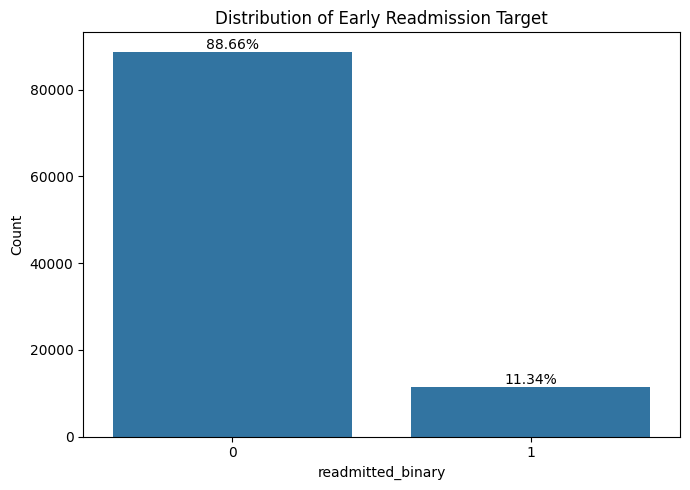

,count,percentage
readmitted_binary,,
0,88757,88.66
1,11357,11.34


In [51]:
target_summary = pd.DataFrame({
    "count": df_eda["readmitted_binary"].value_counts().sort_index(),
    "percentage": (df_eda["readmitted_binary"].value_counts(normalize=True).sort_index() * 100).round(2)
})

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_eda, x="readmitted_binary")

total = len(df_eda)
for p in ax.patches:
    count = int(p.get_height())
    pct = (count / total) * 100
    ax.annotate(f"{pct:.2f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.title("Distribution of Early Readmission Target")
plt.xlabel("readmitted_binary")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

display(target_summary)

### Observation
The target variable is clearly imbalanced, with non-early readmission (`0`) accounting for 88.66% of the cleaned dataset and early readmission (`1`) accounting for only 11.34%. This confirms that later modelling should not rely on accuracy alone and will need imbalance-aware evaluation and handling.

## 3. Readmission rate by age group

This visual examines how the rate of early readmission varies across age bands. A rate-based comparison is more informative than raw counts because the age groups differ in size.

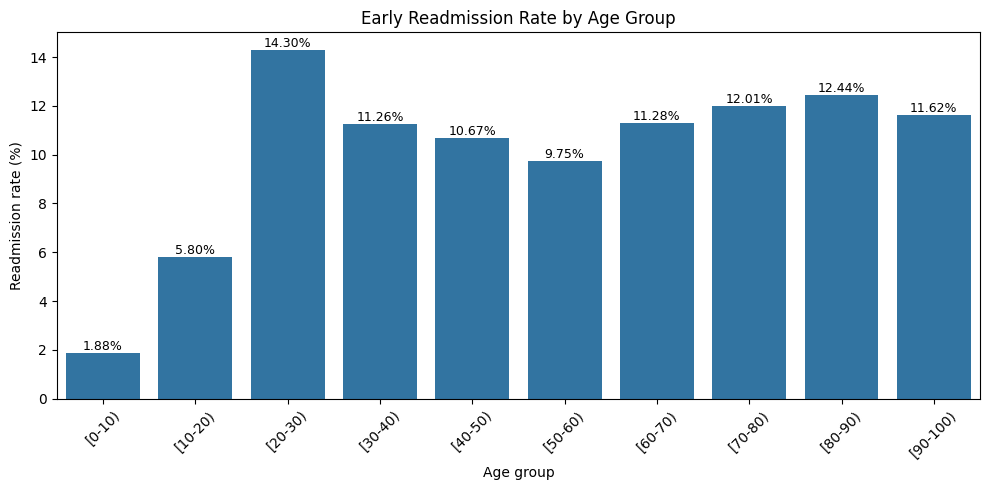

,age,readmission_rate_pct
0,[0-10),1.88
1,[10-20),5.80
2,[20-30),14.30
3,[30-40),11.26
4,[40-50),10.67
5,[50-60),9.75
6,[60-70),11.28
7,[70-80),12.01
8,[80-90),12.44
9,[90-100),11.62


In [52]:
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_readmit_rate = (
    df_eda.groupby("age", observed=False)["readmitted_binary"]
    .mean()
    .reset_index()
)

age_readmit_rate["age"] = pd.Categorical(
    age_readmit_rate["age"],
    categories=age_order,
    ordered=True
)

age_readmit_rate = age_readmit_rate.sort_values("age")
age_readmit_rate["readmission_rate_pct"] = (
    age_readmit_rate["readmitted_binary"] * 100
).round(2)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=age_readmit_rate, x="age", y="readmission_rate_pct")

for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.2f}%",
                (p.get_x() + p.get_width() / 2, value),
                ha="center", va="bottom", fontsize=9)

plt.title("Early Readmission Rate by Age Group")
plt.xlabel("Age group")
plt.ylabel("Readmission rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(age_readmit_rate[["age", "readmission_rate_pct"]])

### Observation
Early readmission rates are much lower in the youngest age groups and generally higher across adult and older patient groups. The highest observed rate appears in the [20-30) band (14.30%), while most middle-aged and older groups cluster around roughly 10–12%, suggesting that age is related to readmission risk but not in a purely monotonic way.

## 4. Medication burden versus readmission

This visual examines whether early readmission becomes more common as medication burden increases. Medication count is a useful proxy for treatment complexity and overall clinical burden.

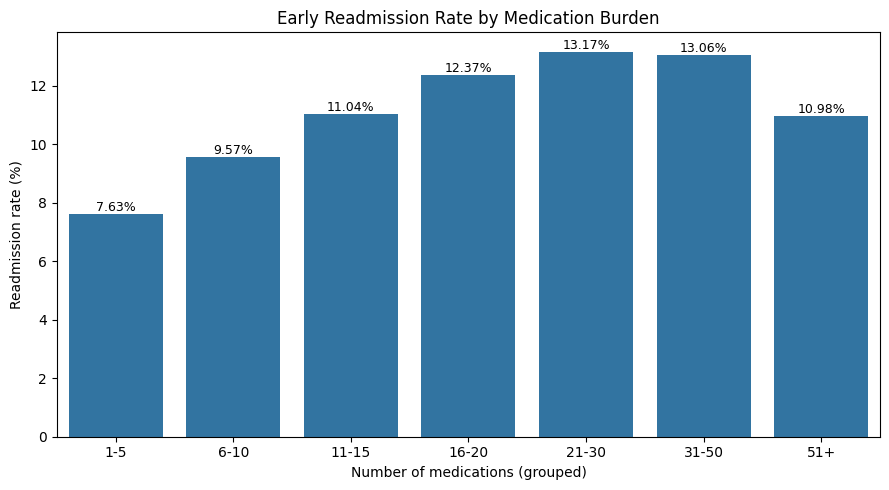

,num_medications_group,readmission_rate_pct
0,1-5,7.63
1,6-10,9.57
2,11-15,11.04
3,16-20,12.37
4,21-30,13.17
5,31-50,13.06
6,51+,10.98


In [53]:
med_bins = [0, 5, 10, 15, 20, 30, 50, 100]
med_labels = ["1-5", "6-10", "11-15", "16-20", "21-30", "31-50", "51+"]

df_eda["num_medications_group"] = pd.cut(
    df_eda["num_medications"],
    bins=med_bins,
    labels=med_labels,
    include_lowest=True
)

med_readmit_rate = (
    df_eda.groupby("num_medications_group", observed=False)["readmitted_binary"]
    .mean()
    .reset_index()
)

med_readmit_rate["readmission_rate_pct"] = (med_readmit_rate["readmitted_binary"] * 100).round(2)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=med_readmit_rate, x="num_medications_group", y="readmission_rate_pct")

for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.2f}%",
                (p.get_x() + p.get_width() / 2, value),
                ha="center", va="bottom", fontsize=9)

plt.title("Early Readmission Rate by Medication Burden")
plt.xlabel("Number of medications (grouped)")
plt.ylabel("Readmission rate (%)")
plt.tight_layout()
plt.show()

display(med_readmit_rate[["num_medications_group", "readmission_rate_pct"]])

### Observation
Early readmission rates generally increase as medication burden rises from the lowest groups up to the 21-30 and 31-50 ranges. The highest observed rates appear in the 21-30 (13.17%) and 31-50 (13.06%) groups, suggesting that greater treatment complexity may be associated with higher early readmission risk, although the slight decline in the 51+ group shows that the pattern is not perfectly linear.

## 5. Medication burden by readmission outcome

This visual compares the distribution of medication burden across the two readmission classes. A violin plot is useful here because it shows both the spread and density of the medication-count distribution rather than only grouped averages.

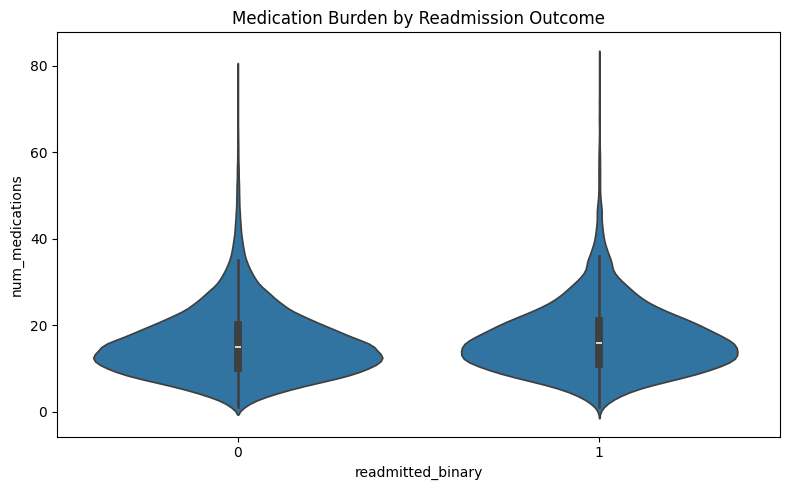

,count,mean,50%,std,min,max
readmitted_binary,,,,,,
0,88757.0,15.86,15.0,8.08,1.0,79.0
1,11357.0,16.90,16.0,8.10,1.0,81.0


In [54]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_eda, x="readmitted_binary", y="num_medications")
plt.title("Medication Burden by Readmission Outcome")
plt.xlabel("readmitted_binary")
plt.ylabel("num_medications")
plt.tight_layout()
plt.show()

med_violin_summary = (
    df_eda.groupby("readmitted_binary")["num_medications"]
    .describe()[["count", "mean", "50%", "std", "min", "max"]]
    .round(2)
)

display(med_violin_summary)

### Observation
The medication-count distribution is slightly shifted upward in the early-readmission group. Patients with readmitted_binary = 1 have a higher median number of medications (16 vs 15) and a higher mean (16.90 vs 15.86), suggesting that greater treatment burden is associated with increased early readmission risk, although the difference is moderate rather than dramatic.

## 6. Correlation heatmap of key numerical features

This visual summarises the linear relationships among the main numeric variables in the cleaned dataset. It is useful for identifying potentially related features and for highlighting where multicollinearity may need to be considered in later modelling.

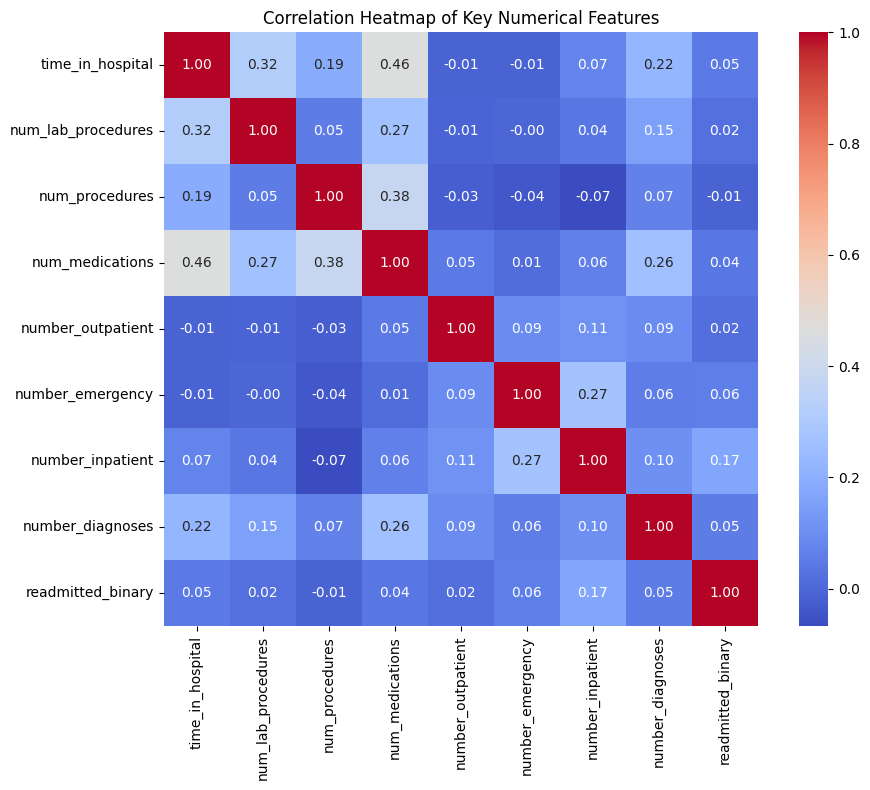

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_binary
time_in_hospital,1.00,0.32,0.19,0.46,-0.01,-0.01,0.07,0.22,0.05
num_lab_procedures,0.32,1.00,0.05,0.27,-0.01,-0.00,0.04,0.15,0.02
num_procedures,0.19,0.05,1.00,0.38,-0.03,-0.04,-0.07,0.07,-0.01
num_medications,0.46,0.27,0.38,1.00,0.05,0.01,0.06,0.26,0.04
number_outpatient,-0.01,-0.01,-0.03,0.05,1.00,0.09,0.11,0.09,0.02
number_emergency,-0.01,-0.00,-0.04,0.01,0.09,1.00,0.27,0.06,0.06
number_inpatient,0.07,0.04,-0.07,0.06,0.11,0.27,1.00,0.10,0.17
number_diagnoses,0.22,0.15,0.07,0.26,0.09,0.06,0.10,1.00,0.05
readmitted_binary,0.05,0.02,-0.01,0.04,0.02,0.06,0.17,0.05,1.00


In [55]:
numeric_cols_for_heatmap = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "readmitted_binary"
]

corr_matrix = df_eda[numeric_cols_for_heatmap].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Key Numerical Features")
plt.tight_layout()
plt.show()

display(corr_matrix.round(2))

### Observation
The strongest positive correlations among the numeric predictors are between time_in_hospital and num_medications (0.46), num_procedures and num_medications (0.38), and time_in_hospital and num_lab_procedures (0.32). Correlations with readmitted_binary are generally weak, with the largest being number_inpatient (0.17), which suggests that no single numeric feature dominates the target on its own and that readmission risk is likely influenced by a combination of factors.

## 7. Scatter matrix of selected numerical features

This visual explores pairwise relationships among selected numerical features while also showing their distributions. Because the full dataset is large, a sampled subset is used here to keep the plot readable and computationally manageable.

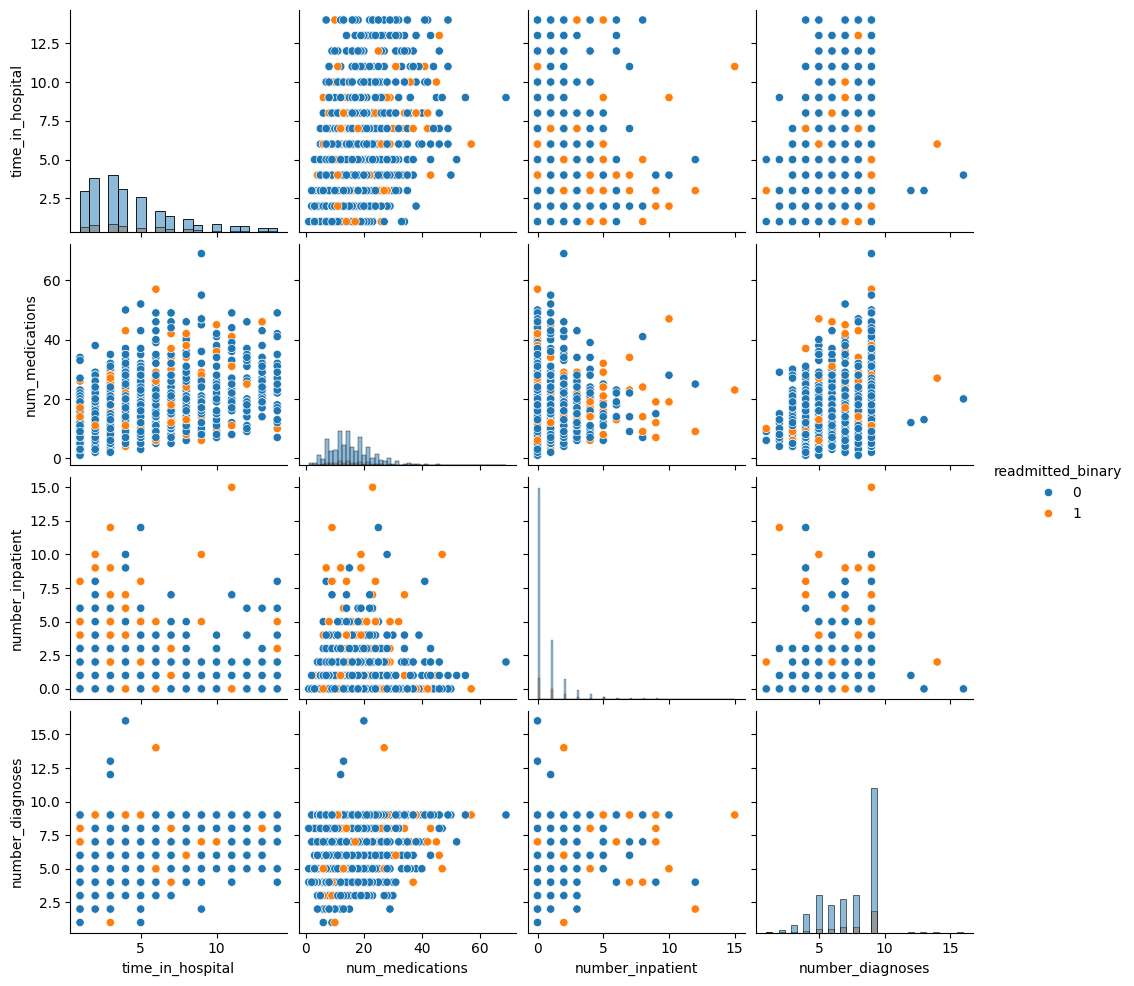

In [56]:
pairplot_cols = [
    "time_in_hospital",
    "num_medications",
    "number_inpatient",
    "number_diagnoses",
    "readmitted_binary"
]

pairplot_sample = df_eda[pairplot_cols].sample(n=2000, random_state=42)

sns.pairplot(
    pairplot_sample,
    vars=["time_in_hospital", "num_medications", "number_inpatient", "number_diagnoses"],
    hue="readmitted_binary",
    diag_kind="hist"
)


plt.show()

### Observation
The scatter matrix shows substantial overlap between the two readmission classes across the selected numerical features, indicating that no single variable cleanly separates early-readmission cases from non-readmission cases on its own. At the same time, num_medications tends to increase with time_in_hospital and number_diagnoses, while number_inpatient remains strongly right-skewed with a small set of higher-use patients. This supports the view that early readmission is influenced by a combination of burden-related factors rather than by one dominant numerical predictor.

## 8. Key numerical variables by readmission outcome

This section compares the distributions of selected numeric variables across the two readmission classes. Boxplots are useful here because they show differences in central tendency, spread, and upper-tail behaviour between the target groups.

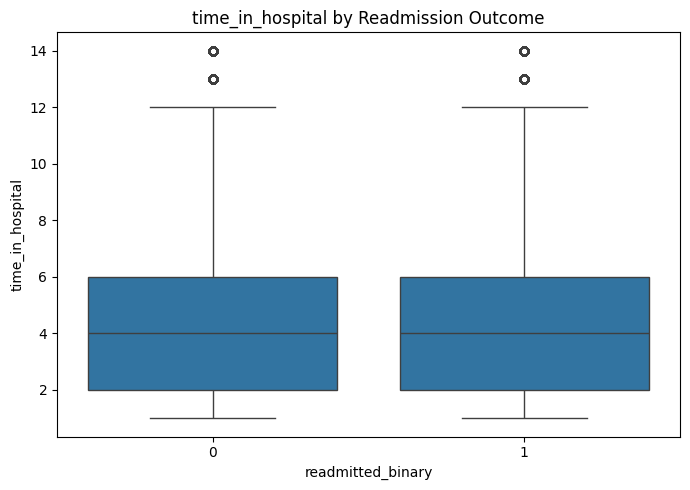

,count,mean,50%,std,min,max
readmitted_binary,,,,,,
0,88757.0,4.34,4.0,2.96,1.0,14.0
1,11357.0,4.77,4.0,3.03,1.0,14.0


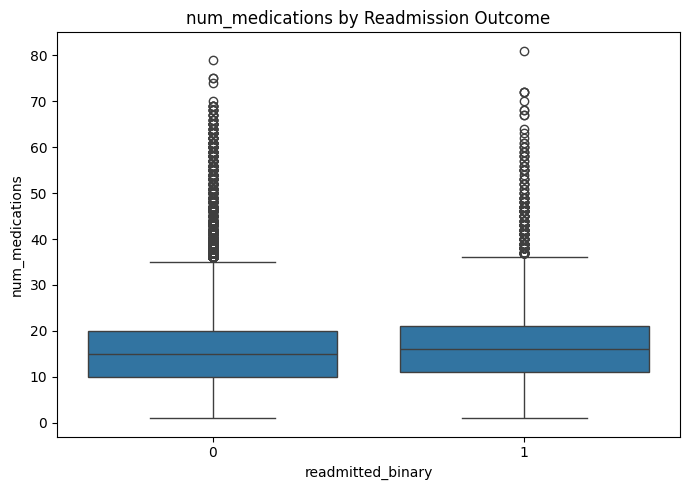

,count,mean,50%,std,min,max
readmitted_binary,,,,,,
0,88757.0,15.86,15.0,8.08,1.0,79.0
1,11357.0,16.90,16.0,8.10,1.0,81.0


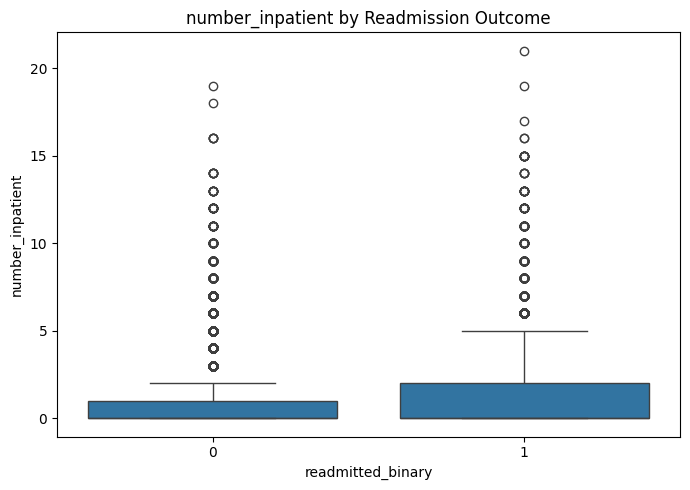

,count,mean,50%,std,min,max
readmitted_binary,,,,,,
0,88757.0,0.56,0.0,1.12,0.0,19.0
1,11357.0,1.22,0.0,1.95,0.0,21.0


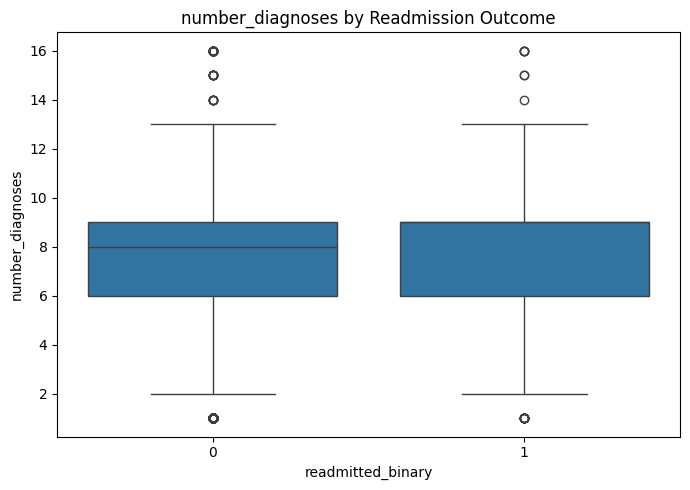

,count,mean,50%,std,min,max
readmitted_binary,,,,,,
0,88757.0,7.37,8.0,1.96,1.0,16.0
1,11357.0,7.69,9.0,1.77,1.0,16.0


In [57]:
boxplot_cols = [
    "time_in_hospital",
    "num_medications",
    "number_inpatient",
    "number_diagnoses"
]

for col in boxplot_cols:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df_eda, x="readmitted_binary", y=col)
    plt.title(f"{col} by Readmission Outcome")
    plt.xlabel("readmitted_binary")
    plt.ylabel(col)
    plt.tight_layout()
    
    plt.show()

    summary = (
        df_eda.groupby("readmitted_binary")[col]
        .describe()[["count", "mean", "50%", "std", "min", "max"]]
        .round(2)
    )
    display(summary)

### Observation
The boxplots suggest that some numeric variables differ more clearly by readmission outcome than others. time_in_hospital shows only a small shift between the two classes, but num_medications, number_inpatient, and number_diagnoses are all somewhat higher in the early-readmission group, with number_inpatient showing the strongest visible separation. This indicates that prior inpatient utilisation and overall clinical burden may be more informative for early readmission risk than length of stay alone.

## 9. Readmission rate by prior inpatient history

This visual examines how early readmission varies with previous inpatient utilisation. Prior inpatient visits are clinically meaningful because they may reflect ongoing illness burden and repeated hospital dependence.

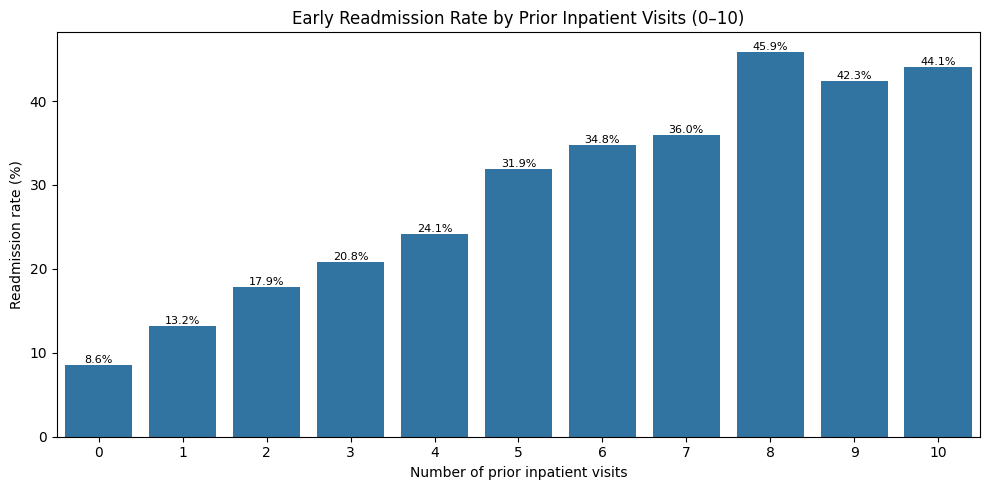

,number_inpatient,count,readmission_rate_pct
0,0,66672,8.56
1,1,19163,13.17
2,2,7382,17.87
3,3,3321,20.84
4,4,1588,24.12
5,5,800,31.87
6,6,477,34.80
7,7,264,35.98
8,8,146,45.89
9,9,111,42.34


In [58]:
inpatient_rate = (
    df_eda.groupby("number_inpatient", observed=False)["readmitted_binary"]
    .mean()
    .reset_index()
)

inpatient_counts = (
    df_eda["number_inpatient"]
    .value_counts()
    .sort_index()
    .rename_axis("number_inpatient")
    .reset_index(name="count")
)

inpatient_rate = inpatient_rate.merge(inpatient_counts, on="number_inpatient", how="left")
inpatient_rate["readmission_rate_pct"] = (inpatient_rate["readmitted_binary"] * 100).round(2)

plot_data = inpatient_rate[inpatient_rate["number_inpatient"] <= 10].copy()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_data, x="number_inpatient", y="readmission_rate_pct")

for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.1f}%",
                (p.get_x() + p.get_width() / 2, value),
                ha="center", va="bottom", fontsize=8)

plt.title("Early Readmission Rate by Prior Inpatient Visits (0–10)")
plt.xlabel("Number of prior inpatient visits")
plt.ylabel("Readmission rate (%)")
plt.tight_layout()
plt.show()

display(inpatient_rate[["number_inpatient", "count", "readmission_rate_pct"]])

### Observation
Early readmission rate rises strongly as the number of prior inpatient visits increases. Patients with no prior inpatient visits show a readmission rate of only 8.56%, while those with 5 to 10 prior inpatient visits show much higher rates, generally above 30%. This suggests that previous inpatient utilisation is one of the clearest indicators of elevated early readmission risk in the cleaned dataset. Very high visit counts above 10 should be interpreted cautiously because the number of observations becomes small.

## 10. Readmission rate by diabetes medication status

This visual examines whether early readmission differs between patients recorded as receiving diabetes medication and those who are not. This is clinically relevant because diabetes medication status may reflect treatment intensity and disease management complexity.

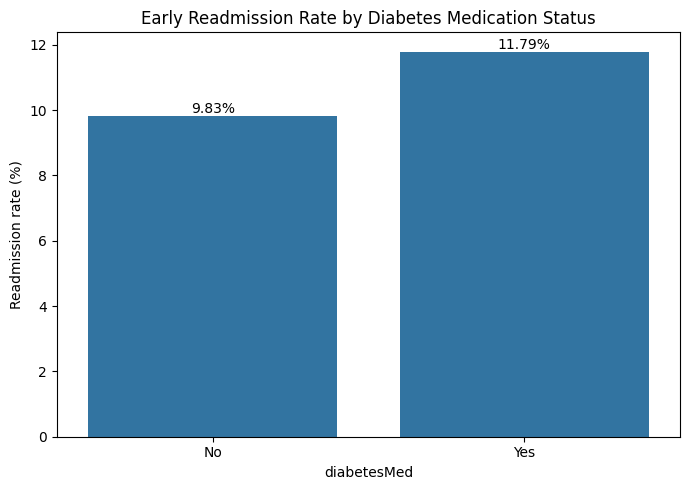

,diabetesMed,count,readmission_rate_pct
0,No,22842,9.83
1,Yes,77272,11.79


In [59]:
diabetesmed_rate = (
    df_eda.groupby("diabetesMed", observed=False)["readmitted_binary"]
    .mean()
    .reset_index()
)

diabetesmed_counts = (
    df_eda["diabetesMed"]
    .value_counts()
    .rename_axis("diabetesMed")
    .reset_index(name="count")
)

diabetesmed_rate = diabetesmed_rate.merge(diabetesmed_counts, on="diabetesMed", how="left")
diabetesmed_rate["readmission_rate_pct"] = (diabetesmed_rate["readmitted_binary"] * 100).round(2)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=diabetesmed_rate, x="diabetesMed", y="readmission_rate_pct")

for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.2f}%",
                (p.get_x() + p.get_width() / 2, value),
                ha="center", va="bottom", fontsize=10)

plt.title("Early Readmission Rate by Diabetes Medication Status")
plt.xlabel("diabetesMed")
plt.ylabel("Readmission rate (%)")
plt.tight_layout()
plt.show()

display(diabetesmed_rate[["diabetesMed", "count", "readmission_rate_pct"]])

### Observation
Patients recorded as receiving diabetes medication show a slightly higher early readmission rate (11.79%) than those not receiving diabetes medication (9.83%). This suggests that diabetes medication status may reflect greater treatment complexity or disease severity, although the difference is modest rather than extreme.

## 11. Readmission rate by medication change status

This visual examines whether early readmission differs according to medication change status. The `change` field is useful because it may reflect treatment adjustment during the encounter, which can be related to patient complexity and later readmission risk.

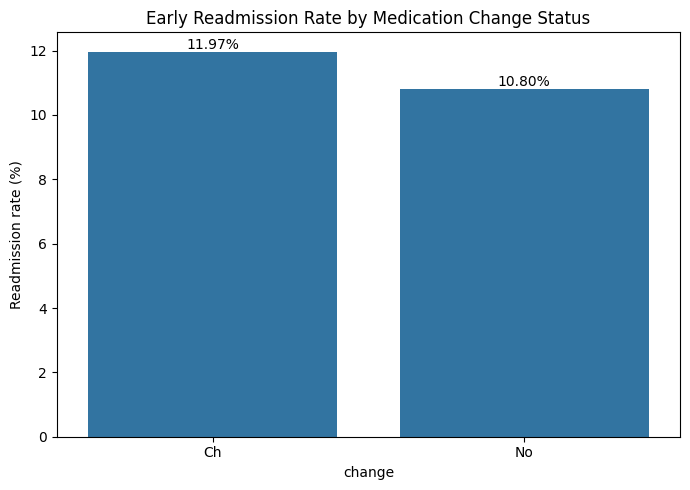

,change,count,readmission_rate_pct
0,Ch,46443,11.97
1,No,53671,10.80


In [60]:
change_rate = (
    df_eda.groupby("change", observed=False)["readmitted_binary"]
    .mean()
    .reset_index()
)

change_counts = (
    df_eda["change"]
    .value_counts()
    .rename_axis("change")
    .reset_index(name="count")
)

change_rate = change_rate.merge(change_counts, on="change", how="left")
change_rate["readmission_rate_pct"] = (change_rate["readmitted_binary"] * 100).round(2)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=change_rate, x="change", y="readmission_rate_pct")

for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.2f}%",
                (p.get_x() + p.get_width() / 2, value),
                ha="center", va="bottom", fontsize=10)

plt.title("Early Readmission Rate by Medication Change Status")
plt.xlabel("change")
plt.ylabel("Readmission rate (%)")
plt.tight_layout()
plt.show()

display(change_rate[["change", "count", "readmission_rate_pct"]])

### Observation
Patients whose diabetes medication status changed during the encounter (`Ch`) show a slightly higher early readmission rate (11.97%) than those with no recorded change (10.80%). This suggests that treatment adjustment may be associated with greater patient complexity or clinical instability, although the difference is modest rather than large.

## 12. Time in hospital by readmission outcome

This visual compares the distribution of hospital stay length across the two readmission classes. A boxplot is useful here because it shows whether early-readmission cases tend to have longer stays or a different spread of stay durations.

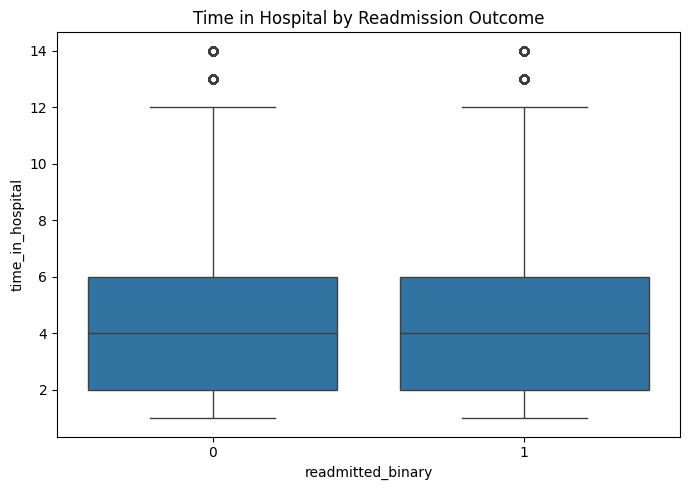

,count,mean,50%,std,min,max
readmitted_binary,,,,,,
0,88757.0,4.34,4.0,2.96,1.0,14.0
1,11357.0,4.77,4.0,3.03,1.0,14.0


In [61]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_eda, x="readmitted_binary", y="time_in_hospital")
plt.title("Time in Hospital by Readmission Outcome")
plt.xlabel("readmitted_binary")
plt.ylabel("time_in_hospital")
plt.tight_layout()
plt.show()

time_hospital_summary = (
    df_eda.groupby("readmitted_binary")["time_in_hospital"]
    .describe()[["count", "mean", "50%", "std", "min", "max"]]
    .round(2)
)

display(time_hospital_summary)

### Observation
The distribution of hospital stay length is very similar across the two readmission groups, with both classes showing a median of 4 days. The early-readmission group has a slightly higher mean stay (4.77 vs 4.34), but the strong overlap between the two boxplots suggests that length of stay alone is only a weak-to-moderate indicator of early readmission risk.

## 13. Readmission rate by admission type

This visual examines whether early readmission differs across admission types. Admission type is useful because it reflects the context of the encounter, such as emergency, urgent, or elective admission, which may influence later readmission risk.

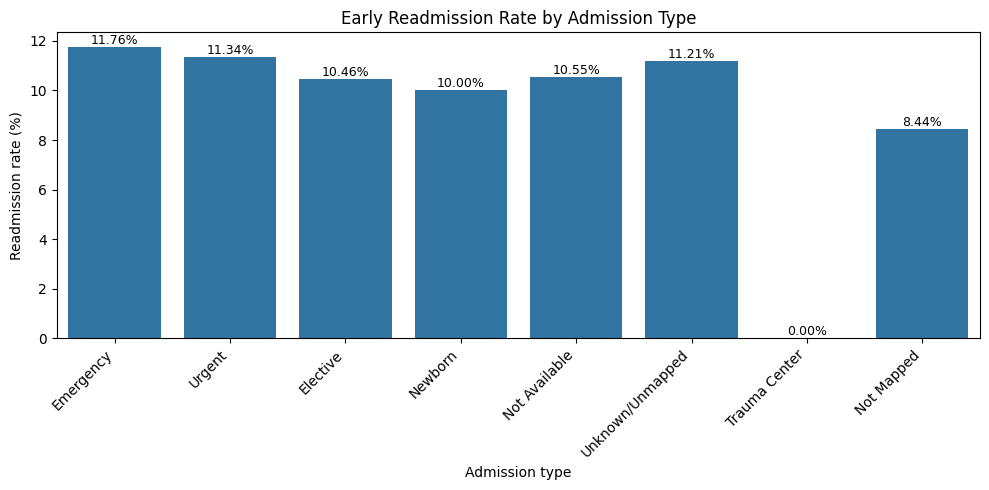

,admission_type_id,description,count,readmission_rate_pct
0,1,Emergency,52884,11.76
1,2,Urgent,18226,11.34
2,3,Elective,18739,10.46
3,4,Newborn,10,10.00
4,5,Not Available,4690,10.55
5,6,NaN,5227,11.21
6,7,Trauma Center,18,0.00
7,8,Not Mapped,320,8.44


In [62]:
ids_path = resolve_input_file(PROJECT_ROOT, "IDS_mapping.csv")
ids_eda = pd.read_csv(ids_path, header=None, dtype=str)

admission_type_start = ids_eda.index[ids_eda[0] == "admission_type_id"][0] + 1
discharge_start = ids_eda.index[ids_eda[0] == "discharge_disposition_id"][0]

admission_type_map = ids_eda.iloc[admission_type_start:discharge_start].copy()
admission_type_map.columns = ["admission_type_id", "description"]
admission_type_map = admission_type_map.dropna(how="all")
admission_type_map["admission_type_id"] = pd.to_numeric(
    admission_type_map["admission_type_id"], errors="coerce"
)
admission_type_map = admission_type_map.dropna(subset=["admission_type_id"])
admission_type_map["admission_type_id"] = admission_type_map["admission_type_id"].astype(int).astype(str)

admission_type_rate = (
    df_eda.assign(admission_type_id=df_eda["admission_type_id"].astype(str))
    .groupby("admission_type_id", observed=False)["readmitted_binary"]
    .mean()
    .reset_index()
)

admission_type_counts = (
    df_eda.assign(admission_type_id=df_eda["admission_type_id"].astype(str))["admission_type_id"]
    .value_counts()
    .rename_axis("admission_type_id")
    .reset_index(name="count")
)

admission_type_rate = admission_type_rate.merge(admission_type_counts, on="admission_type_id", how="left")
admission_type_rate = admission_type_rate.merge(admission_type_map, on="admission_type_id", how="left")
admission_type_rate["readmission_rate_pct"] = (admission_type_rate["readmitted_binary"] * 100).round(2)

plot_data = admission_type_rate.copy()
plot_data["label"] = plot_data["description"].fillna("Unknown/Unmapped")

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_data, x="label", y="readmission_rate_pct")

for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:.2f}%",
        (p.get_x() + p.get_width() / 2, value),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Early Readmission Rate by Admission Type")
plt.xlabel("Admission type")
plt.ylabel("Readmission rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(admission_type_rate[["admission_type_id", "description", "count", "readmission_rate_pct"]])

### Observation
Early readmission rates are slightly higher for Emergency (11.76%) and Urgent (11.34%) admissions than for Elective admissions (10.46%), suggesting that more acute admission contexts may be associated with somewhat greater readmission risk. However, some categories such as Trauma Center and other low-frequency groups should be interpreted cautiously because they contain very small numbers of observations. One admission-type code also remains without a mapped label, indicating a small residual coding-quality issue in the source mapping.

## 14. Readmission rate by discharge disposition

This visual examines how early readmission varies across discharge disposition categories. Discharge disposition is useful because it reflects where the patient went after the encounter, which may influence the likelihood of subsequent readmission.

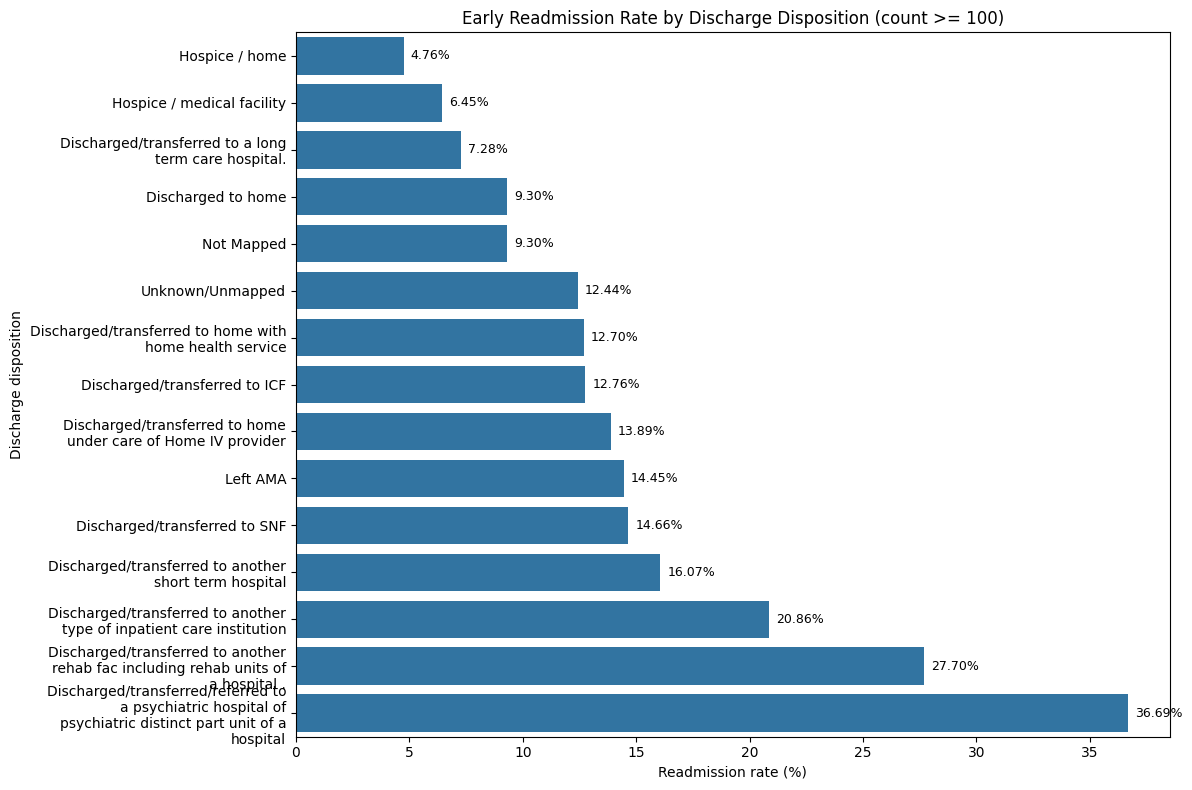

,discharge_disposition_id,description,count,readmission_rate_pct
0,1,Discharged to home,60234,9.30
16,3,Discharged/transferred to SNF,13954,14.66
19,6,Discharged/transferred to home with home healt...,12902,12.70
8,18,NaN,3691,12.44
9,2,Discharged/transferred to another short term h...,2128,16.07
10,22,Discharged/transferred to another rehab fac in...,1993,27.70
18,5,Discharged/transferred to another type of inpa...,1184,20.86
13,25,Not Mapped,989,9.30
17,4,Discharged/transferred to ICF,815,12.76
20,7,Left AMA,623,14.45


In [63]:
import textwrap

ids_path = resolve_input_file(PROJECT_ROOT, "IDS_mapping.csv")
ids_eda = pd.read_csv(ids_path, header=None, dtype=str)

discharge_start = ids_eda.index[ids_eda[0] == "discharge_disposition_id"][0] + 1
admission_source_start = ids_eda.index[ids_eda[0] == "admission_source_id"][0]

discharge_map = ids_eda.iloc[discharge_start:admission_source_start].copy()
discharge_map.columns = ["discharge_disposition_id", "description"]
discharge_map = discharge_map.dropna(how="all")
discharge_map["discharge_disposition_id"] = pd.to_numeric(
    discharge_map["discharge_disposition_id"], errors="coerce"
)
discharge_map = discharge_map.dropna(subset=["discharge_disposition_id"])
discharge_map["discharge_disposition_id"] = (
    discharge_map["discharge_disposition_id"].astype(int).astype(str)
)

discharge_rate = (
    df_eda.assign(discharge_disposition_id=df_eda["discharge_disposition_id"].astype(str))
    .groupby("discharge_disposition_id", observed=False)["readmitted_binary"]
    .mean()
    .reset_index()
)

discharge_counts = (
    df_eda.assign(discharge_disposition_id=df_eda["discharge_disposition_id"].astype(str))[
        "discharge_disposition_id"
    ]
    .value_counts()
    .rename_axis("discharge_disposition_id")
    .reset_index(name="count")
)

discharge_rate = discharge_rate.merge(
    discharge_counts, on="discharge_disposition_id", how="left"
)
discharge_rate = discharge_rate.merge(
    discharge_map, on="discharge_disposition_id", how="left"
)
discharge_rate["readmission_rate_pct"] = (
    discharge_rate["readmitted_binary"] * 100
).round(2)

plot_data = discharge_rate[discharge_rate["count"] >= 100].copy()
plot_data["label"] = plot_data["description"].fillna("Unknown/Unmapped")

plot_data["label_wrapped"] = plot_data["label"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=35))
)

plot_data = plot_data.sort_values("readmission_rate_pct", ascending=True)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=plot_data,
    y="label_wrapped",
    x="readmission_rate_pct"
)

for p in ax.patches:
    value = p.get_width()
    ax.annotate(
        f"{value:.2f}%",
        (value, p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        fontsize=9,
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.title("Early Readmission Rate by Discharge Disposition (count >= 100)")
plt.xlabel("Readmission rate (%)")
plt.ylabel("Discharge disposition")
plt.tight_layout()
plt.show()

display(
    discharge_rate[
        ["discharge_disposition_id", "description", "count", "readmission_rate_pct"]
    ].sort_values("count", ascending=False)
)

### Observation
Early readmission rates vary meaningfully across discharge disposition categories. Patients discharged to home show a comparatively low readmission rate (9.30%), while several transfer-related categories are noticeably higher, including discharge to another short-term hospital (16.07%), another inpatient care institution (20.86%), and another rehab facility (27.70%). The highest visible rate among categories with at least 100 observations appears in discharge to a psychiatric hospital or psychiatric unit of a hospital (36.69%), suggesting that post-discharge destination may carry important information about later readmission risk. However, smaller categories should still be interpreted cautiously because their counts are much lower than the main discharge groups.

## 15. Distribution of skewed numeric features

This section visualises the distributions of the most strongly right-skewed visit-count variables. Histograms are useful here because they show how heavily concentrated these features are at low values and how long their upper tails remain.

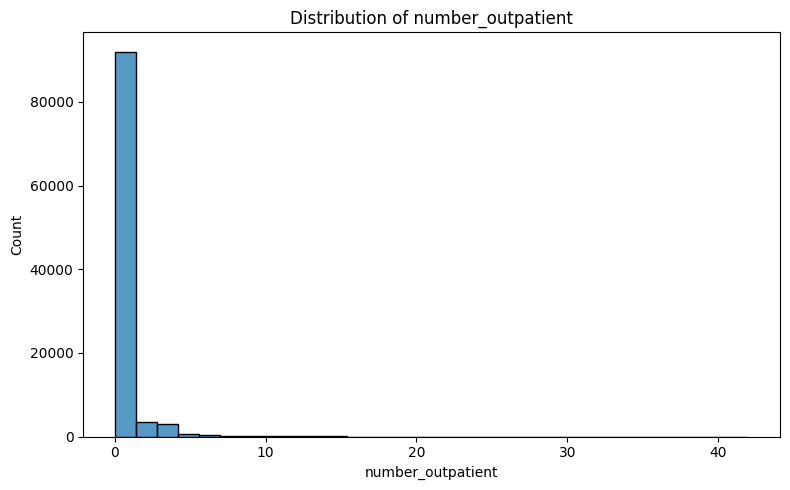

,number_outpatient
count,100114.00
mean,0.37
50%,0.00
std,1.26
min,0.00
max,42.00


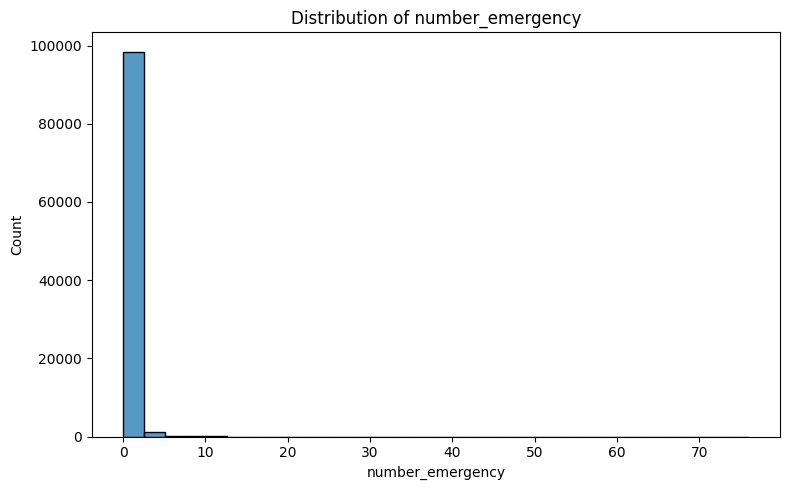

,number_emergency
count,100114.00
mean,0.20
50%,0.00
std,0.94
min,0.00
max,76.00


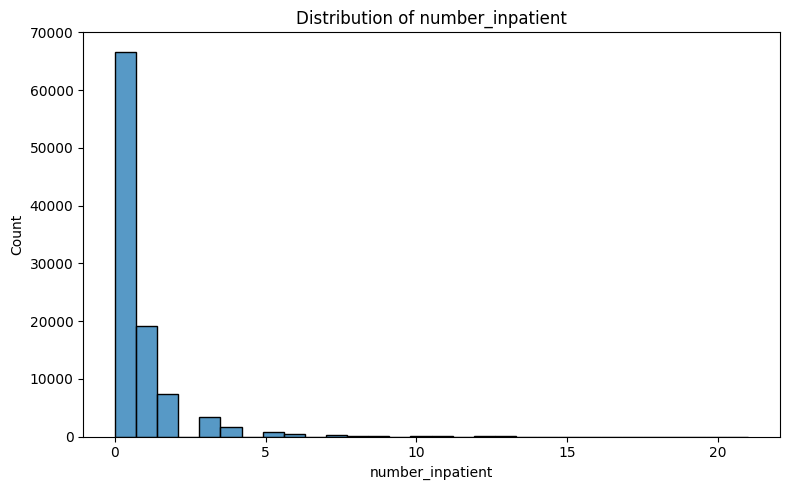

,number_inpatient
count,100114.00
mean,0.63
50%,0.00
std,1.26
min,0.00
max,21.00


In [64]:
skew_cols = ["number_outpatient", "number_emergency", "number_inpatient"]

for col in skew_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df_eda, x=col, bins=30, kde=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
  
    plt.show()

    summary = df_eda[col].describe()[["count", "mean", "50%", "std", "min", "max"]].round(2)
    display(summary.to_frame(name=col))

### Observation
All three visit-count variables are strongly right-skewed, with the vast majority of observations concentrated at very low values and long upper tails extending to much higher counts. In each case, the median is 0, while the maximum values remain much larger (number_outpatient = 42, number_emergency = 76, number_inpatient = 21), confirming that previous healthcare-use behaviour is highly uneven across patients. This supports the earlier cleaning-stage decision to review these variables carefully as potential outlier-sensitive features while retaining them because they appear clinically plausible rather than clearly erroneous.

## 16. EDA summary


The exploratory analysis showed that early readmission was influenced by multiple factors rather than one dominant feature. The target was clearly imbalanced, while age, medication burden, prior inpatient utilisation, and discharge context all showed useful signal. Direct numeric correlations with the target were weak, but number_inpatient, num_medications, and number_diagnoses appeared more informative than time_in_hospital, and the class overlap suggested that later modelling would need to combine several features rather than rely on simple thresholds. Categorical encounter variables also showed meaningful differences, especially for discharge destination, while the visit-count variables were strongly right-skewed and therefore needed careful later handling rather than automatic removal.

#   Initial model building and evaluation

This section develops the first baseline predictive models for early readmission using the aggressively cleaned dataset. The goal is to define a sensible feature set, prepare the data for modelling, and establish strong baseline results before balancing and later improved-model work.


## Reload the final aggressively cleaned dataset explicitly for modelling

In [65]:
cleaned_model_path = resolve_processed_file(PROJECT_ROOT, "cleaned_aggressive.csv")
df_model = pd.read_csv(cleaned_model_path)

print("Modelling dataset loaded from:", cleaned_model_path)
print("Modelling dataset shape:", df_model.shape)

assert df_model.shape == (100114, 36), f"Unexpected cleaned dataset shape: {df_model.shape}"
assert "readmitted_binary" in df_model.columns, "readmitted_binary is missing from cleaned dataset"

print("Cleaned dataset verified successfully.")

Modelling dataset loaded from: /Users/shayan/big data coursework/Group_46/cleaned_aggressive.csv
Modelling dataset shape: (100114, 36)
Cleaned dataset verified successfully.


### Observation
The modelling section explicitly reloads the aggressively cleaned dataset from the processed-data folder. This removes any ambiguity about which dataframe is being used and ensures that all baseline models are trained on the verified cleaned file with 100,114 rows and 36 columns.

## 1.Define the baseline modelling dataset

This subsection prepares the cleaned dataset for baseline modelling by selecting the target variable and an initial set of predictors. Features that would cause leakage or require more advanced feature engineering are excluded from the first baseline model.

In [66]:
modelling_df = df_model.copy()

target_col = "readmitted_binary"

exclude_cols = [
    "readmitted",
    "diag_1", "diag_2", "diag_3",
    "num_medications_group"
]

exclude_cols = [col for col in exclude_cols if col in modelling_df.columns]

feature_cols = [col for col in modelling_df.columns if col not in exclude_cols + [target_col]]

print("Target column:", target_col)
print("Number of baseline predictors:", len(feature_cols))
print("Excluded columns:", exclude_cols)
print("\nBaseline predictor columns:")
print(feature_cols)

Target column: readmitted_binary
Number of baseline predictors: 31
Excluded columns: ['readmitted', 'diag_1', 'diag_2', 'diag_3']

Baseline predictor columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed']


### Observation
The baseline modelling dataset uses readmitted_binary as the prediction target and includes 31 baseline predictors after excluding the original readmitted field, the three diagnosis-code columns, and the temporary EDA helper column num_medications_group. This is a sensible first baseline because it avoids target leakage and defers the mixed-format diagnosis fields to later feature-engineering stages rather than forcing premature encoding.

## 2.Review predictor types and define the encoding plan

Before fitting the baseline models, the predictor columns should be reviewed by type so that numeric, ordinal, and nominal variables can be encoded appropriately. This makes the preprocessing strategy explicit instead of applying one generic transformation to every feature.

In [67]:
predictor_type_summary = pd.DataFrame({
    "dtype": modelling_df[feature_cols].dtypes.astype(str),
    "n_unique": modelling_df[feature_cols].nunique(dropna=False),
    "missing_count": modelling_df[feature_cols].isna().sum()
}).sort_values(["dtype", "n_unique"])

display(predictor_type_summary)

,dtype,n_unique,missing_count
num_procedures,int64,7,0
admission_type_id,int64,8,0
time_in_hospital,int64,14,0
number_diagnoses,int64,16,0
admission_source_id,int64,17,0
number_inpatient,int64,21,0
discharge_disposition_id,int64,23,0
number_emergency,int64,33,0
number_outpatient,int64,39,0
num_medications,int64,75,0


In [68]:
numeric_features = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

numeric_features = [col for col in numeric_features if col in feature_cols]

age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_mapping = {label: idx for idx, label in enumerate(age_order)}
modelling_df["age_ordinal"] = modelling_df["age"].map(age_mapping)

categorical_features = [col for col in feature_cols if col not in numeric_features + ["age"]]

print("Numeric features:")
print(numeric_features)

print("\nOrdinal feature:")
print(["age_ordinal"])

print("\nCategorical features for one-hot encoding:")
print(categorical_features)

Numeric features:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Ordinal feature:
['age_ordinal']

Categorical features for one-hot encoding:
['race', 'gender', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed']


In [69]:
numeric_feature_check = numeric_features + ["age_ordinal", target_col]

numeric_corr = (
    modelling_df[numeric_feature_check]
    .corr(numeric_only=True)[target_col]
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("correlation_with_target")
)

display(numeric_corr)

,correlation_with_target
readmitted_binary,1.000000
number_inpatient,0.167589
number_emergency,0.060787
discharge_disposition_id,0.059710
number_diagnoses,0.052343
time_in_hospital,0.045530
num_medications,0.040725
num_lab_procedures,0.023385
age_ordinal,0.020842
number_outpatient,0.019097


### Observation
The baseline predictor set contains a clear mix of numeric, ordinal, and nominal variables, so a single generic encoding rule would be inappropriate. The modelling plan therefore separates hospital-use variables as numeric features, converts age into an ordinal representation, and treats the remaining demographic, laboratory, medication, and encounter-context variables as categorical features for one-hot encoding. A simple correlation review of the numeric predictors also supports the feature-selection rationale: prior inpatient visits show the strongest relationship with early readmission, while emergency visits, discharge disposition, number of diagnoses, and time in hospital show smaller but still meaningful associations. This strengthens the decision to retain these utilisation-related predictors in the initial modelling stage.

## 3.Prepare retained categorical values for modelling

Some categorical values were intentionally retained during cleaning rather than being removed prematurely. Before modelling, these values should be made explicit so that the encoding pipeline can treat them consistently rather than interpreting them as ordinary missing data.

In [70]:

modelling_df["max_glu_serum"] = modelling_df["max_glu_serum"].fillna("None")
modelling_df["A1Cresult"] = modelling_df["A1Cresult"].fillna("None")

modelling_df["race"] = modelling_df["race"].fillna("Unknown")
modelling_df["gender"] = modelling_df["gender"].replace("Unknown/Invalid", "Unknown")

print("Remaining missing values in selected categorical fields:")
print("race:", modelling_df["race"].isna().sum())
print("gender:", modelling_df["gender"].isna().sum())
print("max_glu_serum:", modelling_df["max_glu_serum"].isna().sum())
print("A1Cresult:", modelling_df["A1Cresult"].isna().sum())

print("\nUpdated category counts:")
display(modelling_df["race"].value_counts(dropna=False).to_frame("count"))
display(modelling_df["gender"].value_counts(dropna=False).to_frame("count"))
display(modelling_df["max_glu_serum"].value_counts(dropna=False).to_frame("count"))
display(modelling_df["A1Cresult"].value_counts(dropna=False).to_frame("count"))

Remaining missing values in selected categorical fields:
race: 0
gender: 0
max_glu_serum: 0
A1Cresult: 0

Updated category counts:


,count
race,
Caucasian,74845
AfricanAmerican,18888
Unknown,2239
Hispanic,2024
Other,1486
Asian,632


,count
gender,
Female,53861
Male,46250
Unknown,3


,count
max_glu_serum,
None,94890
Norm,2573
>200,1440
>300,1211


,count
A1Cresult,
None,83238
>8,8151
Norm,4941
>7,3784


### Observation
The retained categorical gaps have now been made explicit for modelling. Missing race values were mapped to Unknown, the rare Unknown/Invalid value in gender was standardised to the same label, and the laboratory result fields max_glu_serum and A1Cresult were restored to the categorical value None rather than being treated as ordinary missing data. This resolves the earlier deferred handling decisions in a modelling-appropriate way without requiring weak demographic imputation.

## 4.Create the final modelling matrix and stratified train-test split

This subsection prepares the predictor matrix and target vector for baseline modelling and then creates a stratified train-test split. Stratification is important because the target is imbalanced, so both the training and test sets should preserve similar class proportions.

In [71]:
from sklearn.model_selection import train_test_split


final_feature_cols = [col for col in feature_cols if col != "age"] + ["age_ordinal"]

X = modelling_df[final_feature_cols].copy()
y = modelling_df[target_col].copy()

print("Predictor matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nOverall target distribution:")
display(y.value_counts(normalize=True).sort_index().mul(100).round(2).to_frame("percentage"))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining target distribution (%):")
display(y_train.value_counts(normalize=True).sort_index().mul(100).round(2).to_frame("percentage"))

print("\nTest target distribution (%):")
display(y_test.value_counts(normalize=True).sort_index().mul(100).round(2).to_frame("percentage"))

Predictor matrix shape: (100114, 31)
Target shape: (100114,)

Overall target distribution:


,percentage
readmitted_binary,
0,88.66
1,11.34



Training set shape: (80091, 31)
Test set shape: (20023, 31)

Training target distribution (%):


,percentage
readmitted_binary,
0,88.66
1,11.34



Test target distribution (%):


,percentage
readmitted_binary,
0,88.66
1,11.34


### Observation
The modelling dataset was split into training and test sets using stratification, and both subsets preserve the same target balance as the full dataset: 88.66% non-early readmission and 11.34% early readmission. This is important because the target is clearly imbalanced, so a stratified split gives a more reliable baseline for later model evaluation than an unstratified random split.

## 5.Build a dummy baseline model

Before fitting real predictive models, it is useful to establish a naive baseline. A dummy classifier that always predicts the majority class helps show why accuracy alone can be misleading for an imbalanced target.

In [72]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

y_dummy_pred = dummy_model.predict(X_test)

dummy_results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1"],
    "value": [
        accuracy_score(y_test, y_dummy_pred),
        precision_score(y_test, y_dummy_pred, zero_division=0),
        recall_score(y_test, y_dummy_pred, zero_division=0),
        f1_score(y_test, y_dummy_pred, zero_division=0),
    ]
})

print("Dummy baseline classification report:")
print(classification_report(y_test, y_dummy_pred, zero_division=0))

print("\nDummy baseline confusion matrix:")
print(confusion_matrix(y_test, y_dummy_pred))

display(dummy_results)

Dummy baseline classification report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17752
           1       0.00      0.00      0.00      2271

    accuracy                           0.89     20023
   macro avg       0.44      0.50      0.47     20023
weighted avg       0.79      0.89      0.83     20023


Dummy baseline confusion matrix:
[[17752     0]
 [ 2271     0]]


,metric,value
0,accuracy,0.88658
1,precision,0.00000
2,recall,0.00000
3,f1,0.00000


### Observation
The dummy baseline achieves an apparently high accuracy of 88.66% simply by always predicting the majority class, but it completely fails to identify any early-readmission cases, with precision, recall, and F1-score all equal to 0 for the positive class. This confirms that accuracy alone would be misleading for this imbalanced problem and that later models must be evaluated using minority-sensitive metrics such as recall, F1-score, ROC-AUC, and confusion matrices.

## 6.Logistic Regression baseline model

The first required baseline model is a linear classifier. Logistic Regression is a suitable starting point because it is interpretable, widely used for binary classification, and provides a clear baseline before stronger non-linear models are introduced.

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features + ["age_ordinal"]),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

log_reg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_model.fit(X_train, y_train)

y_log_pred = log_reg_model.predict(X_test)
y_log_proba = log_reg_model.predict_proba(X_test)[:, 1]

log_reg_results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_log_pred),
        precision_score(y_test, y_log_pred, zero_division=0),
        recall_score(y_test, y_log_pred, zero_division=0),
        f1_score(y_test, y_log_pred, zero_division=0),
        roc_auc_score(y_test, y_log_proba),
    ]
})

print("Logistic Regression classification report:")
print(classification_report(y_test, y_log_pred, zero_division=0))

print("\nLogistic Regression confusion matrix:")
print(confusion_matrix(y_test, y_log_pred))

display(log_reg_results)

Logistic Regression classification report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17752
           1       0.47      0.01      0.03      2271

    accuracy                           0.89     20023
   macro avg       0.68      0.51      0.48     20023
weighted avg       0.84      0.89      0.84     20023


Logistic Regression confusion matrix:
[[17716    36]
 [ 2239    32]]


,metric,value
0,accuracy,0.886381
1,precision,0.470588
2,recall,0.014091
3,f1,0.027362
4,roc_auc,0.644426


### Observation
The Logistic Regression baseline performs only marginally better than the dummy classifier in terms of overall accuracy, but it still struggles badly with the minority class. Although the model achieves a ROC-AUC of 0.64 and a positive-class precision of 0.47, its recall is only 0.01, meaning that it identifies very few early-readmission cases. This shows that the imbalanced baseline dataset strongly limits the usefulness of the linear model and supports the need for balancing and comparison with stronger non-linear models.

## 7.Random Forest baseline

Random Forest is used as a stronger non-linear baseline model after Logistic Regression. It is useful because it can capture more complex interactions between predictors and may perform better on structured healthcare data.

In [74]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_rf_pred = rf_model.predict(X_test)
y_rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_rf_pred),
        precision_score(y_test, y_rf_pred, zero_division=0),
        recall_score(y_test, y_rf_pred, zero_division=0),
        f1_score(y_test, y_rf_pred, zero_division=0),
        roc_auc_score(y_test, y_rf_proba),
    ]
})

print("Random Forest classification report:")
print(classification_report(y_test, y_rf_pred, zero_division=0))

print("\nRandom Forest confusion matrix:")
print(confusion_matrix(y_test, y_rf_pred))

display(rf_results)

Random Forest classification report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17752
           1       0.52      0.01      0.02      2271

    accuracy                           0.89     20023
   macro avg       0.71      0.50      0.48     20023
weighted avg       0.85      0.89      0.84     20023


Random Forest confusion matrix:
[[17731    21]
 [ 2248    23]]


,metric,value
0,accuracy,0.886680
1,precision,0.522727
2,recall,0.010128
3,f1,0.019870
4,roc_auc,0.631494


### Observation
The Random Forest baseline does not materially improve minority-class detection on the imbalanced dataset. Although it achieves a similar overall accuracy to Logistic Regression (88.67%) and slightly higher positive-class precision (0.52), its recall remains extremely low at 0.01 and its ROC-AUC (0.63) is slightly lower than the Logistic Regression baseline. This suggests that, before class balancing, the stronger non-linear model still struggles to identify early-readmission cases and that imbalance handling is likely to matter more than model complexity at this stage.

## 8.Decision Tree baseline

Decision Tree is added as a third baseline classifier after Logistic Regression and Random Forest. It is useful because it can capture non-linear decision rules while remaining easier to interpret than a full ensemble model.

In [75]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10
    ))
])

dt_model.fit(X_train, y_train)

y_dt_pred = dt_model.predict(X_test)
y_dt_proba = dt_model.predict_proba(X_test)[:, 1]

dt_results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_dt_pred),
        precision_score(y_test, y_dt_pred, zero_division=0),
        recall_score(y_test, y_dt_pred, zero_division=0),
        f1_score(y_test, y_dt_pred, zero_division=0),
        roc_auc_score(y_test, y_dt_proba),
    ]
})

print("Decision Tree classification report:")
print(classification_report(y_test, y_dt_pred, zero_division=0))

print("\nDecision Tree confusion matrix:")
print(confusion_matrix(y_test, y_dt_pred))

display(dt_results)

Decision Tree classification report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17752
           1       0.41      0.02      0.04      2271

    accuracy                           0.89     20023
   macro avg       0.65      0.51      0.49     20023
weighted avg       0.83      0.89      0.84     20023


Decision Tree confusion matrix:
[[17688    64]
 [ 2227    44]]


,metric,value
0,accuracy,0.885582
1,precision,0.407407
2,recall,0.019375
3,f1,0.036990
4,roc_auc,0.641890


### Observation
The Decision Tree baseline performs slightly better than the other imbalanced baselines in positive-class recall, reaching 0.02 and an F1-score of 0.04, but it still misses the vast majority of early-readmission cases. Its ROC-AUC (0.6419) is very close to Logistic Regression, while its overall accuracy remains majority-class driven. This means that adding a third classifier improves the breadth of the comparison, but class imbalance is still the dominant limitation before balancing.

## 9.Compare the baseline models on imbalanced data

This subsection compares the dummy baseline, Logistic Regression, and Random Forest on the imbalanced test set. A direct comparison is useful because it shows whether the real models improve minority-class prediction beyond the naive majority-class baseline.

In [76]:
baseline_comparison = pd.DataFrame({
    "model": ["Dummy", "Logistic Regression", "Random Forest", "Decision Tree"],
    "accuracy": [
        accuracy_score(y_test, y_dummy_pred),
        accuracy_score(y_test, y_log_pred),
        accuracy_score(y_test, y_rf_pred),
        accuracy_score(y_test, y_dt_pred),
    ],
    "precision": [
        precision_score(y_test, y_dummy_pred, zero_division=0),
        precision_score(y_test, y_log_pred, zero_division=0),
        precision_score(y_test, y_rf_pred, zero_division=0),
        precision_score(y_test, y_dt_pred, zero_division=0),
    ],
    "recall": [
        recall_score(y_test, y_dummy_pred, zero_division=0),
        recall_score(y_test, y_log_pred, zero_division=0),
        recall_score(y_test, y_rf_pred, zero_division=0),
        recall_score(y_test, y_dt_pred, zero_division=0),
    ],
    "f1": [
        f1_score(y_test, y_dummy_pred, zero_division=0),
        f1_score(y_test, y_log_pred, zero_division=0),
        f1_score(y_test, y_rf_pred, zero_division=0),
        f1_score(y_test, y_dt_pred, zero_division=0),
    ],
    "roc_auc": [
        np.nan,
        roc_auc_score(y_test, y_log_proba),
        roc_auc_score(y_test, y_rf_proba),
        roc_auc_score(y_test, y_dt_proba),
    ]
}).round(4)

display(baseline_comparison.sort_values("recall", ascending=False))

,model,accuracy,precision,recall,f1,roc_auc
3,Decision Tree,0.8856,0.4074,0.0194,0.0370,0.6419
1,Logistic Regression,0.8864,0.4706,0.0141,0.0274,0.6444
2,Random Forest,0.8867,0.5227,0.0101,0.0199,0.6315
0,Dummy,0.8866,0.0000,0.0000,0.0000,NaN


### Observation
Among the imbalanced baseline models, Decision Tree gives the highest recall (0.0194) and F1-score (0.0370), while Logistic Regression achieves the strongest ROC-AUC (0.6444) and Random Forest gives the highest positive-class precision (0.5227). However, all three real models still perform poorly at detecting early-readmission cases, with recall remaining close to zero in every case. This confirms that, before balancing, class imbalance is the dominant limitation regardless of model family.

## 10.Stratified cross-validation for the baseline models

A single train-test split can give an incomplete view of model performance, especially with an imbalanced target. Stratified cross-validation provides a more stable estimate by evaluating the baseline models across multiple folds while preserving class proportions in each split.

In [77]:
import warnings
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate

warnings.filterwarnings(
    "ignore",
    message=r"`sklearn\.utils\.parallel\.delayed` should be used with `sklearn\.utils\.parallel\.Parallel`.*",
    category=UserWarning,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

log_cv_results = cross_validate(
    log_reg_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

rf_cv_results = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

dt_cv_results = cross_validate(
    dt_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

cv_summary = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest", "Decision Tree"],
    "cv_accuracy_mean": [
        log_cv_results["test_accuracy"].mean(),
        rf_cv_results["test_accuracy"].mean(),
        dt_cv_results["test_accuracy"].mean()
    ],
    "cv_precision_mean": [
        log_cv_results["test_precision"].mean(),
        rf_cv_results["test_precision"].mean(),
        dt_cv_results["test_precision"].mean()
    ],
    "cv_recall_mean": [
        log_cv_results["test_recall"].mean(),
        rf_cv_results["test_recall"].mean(),
        dt_cv_results["test_recall"].mean()
    ],
    "cv_f1_mean": [
        log_cv_results["test_f1"].mean(),
        rf_cv_results["test_f1"].mean(),
        dt_cv_results["test_f1"].mean()
    ],
    "cv_roc_auc_mean": [
        log_cv_results["test_roc_auc"].mean(),
        rf_cv_results["test_roc_auc"].mean(),
        dt_cv_results["test_roc_auc"].mean()
    ]
}).round(4)

display(cv_summary)

,model,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean
0,Logistic Regression,0.8863,0.4705,0.0153,0.0296,0.6424
1,Random Forest,0.8862,0.4187,0.0064,0.0126,0.6295
2,Decision Tree,0.8841,0.3362,0.0234,0.0435,0.6430


### Observation
The stratified cross-validation results on the training data reinforce the same overall pattern seen in the test-set comparison. Decision Tree gives the strongest minority-class recall (0.0234) and F1-score (0.0435), while Logistic Regression remains very close in ROC-AUC (0.6424 vs 0.6430) and Random Forest performs worst on minority detection. However, all three imbalanced baseline models still show very low recall overall, confirming that class imbalance remains the main obstacle before random undersampling is applied. Using cross-validation on the training split only also makes this evaluation more methodologically consistent with the train-test framework required in the coursework. 

## 11.Confusion matrices and ROC curves for the baseline models

This subsection visualises the baseline model performance using confusion matrices and ROC curves. These plots are useful because they show not only overall ranking performance but also how many early-readmission cases each model actually detects.

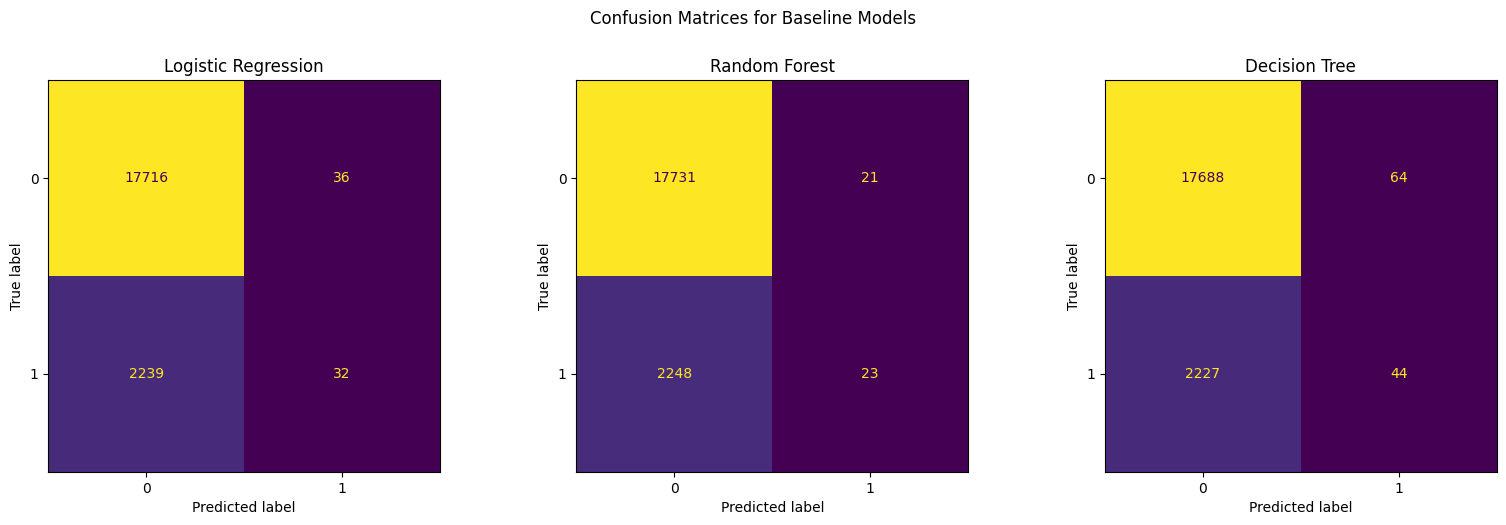

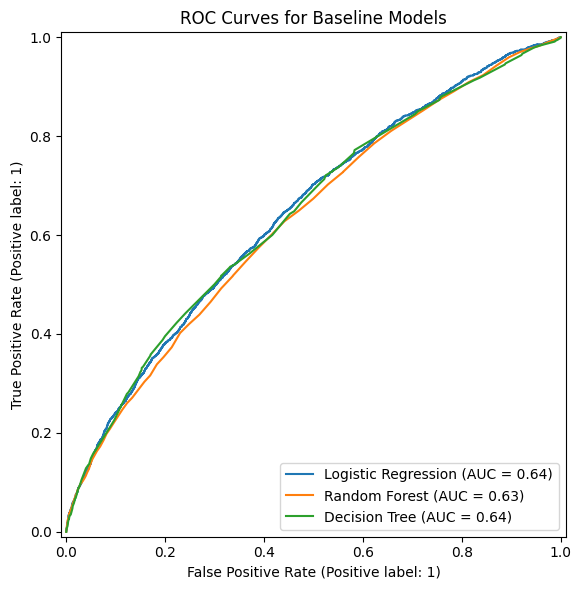

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_log_pred, ax=axes[0], colorbar=False
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_rf_pred, ax=axes[1], colorbar=False
)
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_dt_pred, ax=axes[2], colorbar=False
)
axes[2].set_title("Decision Tree")

plt.suptitle("Confusion Matrices for Baseline Models", y=1.02)
plt.tight_layout()
plt.show()

# ROC curves for the three baseline models
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_log_proba, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_rf_proba, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_dt_proba, name="Decision Tree", ax=ax)
ax.set_title("ROC Curves for Baseline Models")
plt.tight_layout()
plt.show()

### Observation
The confusion matrices confirm that both baseline models overwhelmingly predict the majority class and miss almost all early-readmission cases. Logistic Regression identifies only 32 true positives and Random Forest only 23, which explains their extremely low recall despite high overall accuracy. The ROC curves show that both models perform somewhat better than random ranking, with Logistic Regression achieving a slightly higher ROC-AUC than Random Forest, but neither model is strong enough in its current imbalanced form to support reliable minority-class detection.

## 12.Balance the training data with random undersampling

Because the target is clearly imbalanced, the next step is to rebalance the training data before retraining the baseline models. Following the coursework brief, random undersampling is applied by keeping all minority-class cases and selecting an equal number of majority-class cases from the training split.

In [79]:

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (80091, 85)
Processed test shape: (20023, 85)


In [80]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_processed, y_train)

print("Original training target distribution:")
display(y_train.value_counts().sort_index().to_frame("count"))

print("\nBalanced training target distribution after random undersampling:")
display(pd.Series(y_train_under).value_counts().sort_index().to_frame("count"))

print("\nProcessed training shape before undersampling:", X_train_processed.shape)
print("Processed training shape after undersampling:", X_train_under.shape)

Original training target distribution:


,count
readmitted_binary,
0,71005
1,9086



Balanced training target distribution after random undersampling:


,count
readmitted_binary,
0,9086
1,9086



Processed training shape before undersampling: (80091, 85)
Processed training shape after undersampling: (18172, 85)


### Observation
Random undersampling rebalanced the training data by retaining all minority-class cases and selecting an equal number of majority-class cases, reducing the processed training set from 80,091 rows to 18,172 rows while keeping the same 85 encoded features. This matches the coursework requirement for handling imbalance in the initial modelling stage and creates a balanced training set without generating synthetic observations. 

## 13.Logistic Regression on balanced training data

This subsection retrains the Logistic Regression baseline after balancing the training data with random undersampling. The aim is to test whether improved class balance leads to better early-readmission detection than the imbalanced baseline model. 

In [81]:
log_reg_balanced = LogisticRegression(max_iter=1000, random_state=42)
log_reg_balanced.fit(X_train_under, y_train_under)

y_log_bal_pred = log_reg_balanced.predict(X_test_processed)
y_log_bal_proba = log_reg_balanced.predict_proba(X_test_processed)[:, 1]

log_reg_bal_results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_log_bal_pred),
        precision_score(y_test, y_log_bal_pred, zero_division=0),
        recall_score(y_test, y_log_bal_pred, zero_division=0),
        f1_score(y_test, y_log_bal_pred, zero_division=0),
        roc_auc_score(y_test, y_log_bal_proba),
    ]
})

print("Balanced Logistic Regression classification report:")
print(classification_report(y_test, y_log_bal_pred, zero_division=0))

print("\nBalanced Logistic Regression confusion matrix:")
print(confusion_matrix(y_test, y_log_bal_pred))

display(log_reg_bal_results)

Balanced Logistic Regression classification report:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     17752
           1       0.17      0.51      0.26      2271

    accuracy                           0.67     20023
   macro avg       0.54      0.60      0.52     20023
weighted avg       0.83      0.67      0.73     20023


Balanced Logistic Regression confusion matrix:
[[12190  5562]
 [ 1108  1163]]


,metric,value
0,accuracy,0.666883
1,precision,0.172937
2,recall,0.512109
3,f1,0.258559
4,roc_auc,0.642508


### Observation
Random undersampling substantially improves the Logistic Regression model’s ability to identify early-readmission cases. Compared with the imbalanced baseline, recall increases from 0.0141 to 0.5121 and the F1-score rises from 0.0274 to 0.2586, although this comes at the cost of lower overall accuracy and lower precision. This trade-off is consistent with the coursework objective, because the balanced model is now much more useful for minority-class detection than the accuracy-driven imbalanced baseline.

## 14.Random Forest on balanced training data

This subsection retrains the Random Forest baseline after balancing the training data with random undersampling. The aim is to test whether the stronger non-linear model benefits from balanced class representation in the same way as Logistic Regression.

In [82]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train_under, y_train_under)

y_rf_bal_pred = rf_balanced.predict(X_test_processed)
y_rf_bal_proba = rf_balanced.predict_proba(X_test_processed)[:, 1]

rf_bal_results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_rf_bal_pred),
        precision_score(y_test, y_rf_bal_pred, zero_division=0),
        recall_score(y_test, y_rf_bal_pred, zero_division=0),
        f1_score(y_test, y_rf_bal_pred, zero_division=0),
        roc_auc_score(y_test, y_rf_bal_proba),
    ]
})

print("Balanced Random Forest classification report:")
print(classification_report(y_test, y_rf_bal_pred, zero_division=0))

print("\nBalanced Random Forest confusion matrix:")
print(confusion_matrix(y_test, y_rf_bal_pred))

display(rf_bal_results)

Balanced Random Forest classification report:
              precision    recall  f1-score   support

           0       0.92      0.61      0.73     17752
           1       0.16      0.59      0.25      2271

    accuracy                           0.61     20023
   macro avg       0.54      0.60      0.49     20023
weighted avg       0.83      0.61      0.68     20023


Balanced Random Forest confusion matrix:
[[10807  6945]
 [  935  1336]]


,metric,value
0,accuracy,0.606453
1,precision,0.161333
2,recall,0.588287
3,f1,0.253222
4,roc_auc,0.637538


### Observation
Random undersampling substantially improves the Random Forest model’s ability to detect early-readmission cases. Compared with the imbalanced baseline, recall increases from 0.0101 to 0.5883 and the F1-score rises from 0.0199 to 0.2532, although this comes with a large reduction in overall accuracy and precision. This indicates that, under balanced training, Random Forest becomes much more useful for minority-class detection and now performs at a similar level to balanced Logistic Regression in terms of recall and F1-score. 

## 15.Decision Tree on balanced training data

This subsection retrains the Decision Tree baseline after balancing the training data with random undersampling. The aim is to test whether the simpler non-linear model also benefits from balanced class representation and how it compares with the balanced Logistic Regression and Random Forest models. 


In [83]:
dt_balanced = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10
)
dt_balanced.fit(X_train_under, y_train_under)

y_dt_bal_pred = dt_balanced.predict(X_test_processed)
y_dt_bal_proba = dt_balanced.predict_proba(X_test_processed)[:, 1]

dt_bal_results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_dt_bal_pred),
        precision_score(y_test, y_dt_bal_pred, zero_division=0),
        recall_score(y_test, y_dt_bal_pred, zero_division=0),
        f1_score(y_test, y_dt_bal_pred, zero_division=0),
        roc_auc_score(y_test, y_dt_bal_proba),
    ]
})

print("Balanced Decision Tree classification report:")
print(classification_report(y_test, y_dt_bal_pred, zero_division=0))

print("\nBalanced Decision Tree confusion matrix:")
print(confusion_matrix(y_test, y_dt_bal_pred))

display(dt_bal_results)

Balanced Decision Tree classification report:
              precision    recall  f1-score   support

           0       0.92      0.62      0.74     17752
           1       0.16      0.57      0.25      2271

    accuracy                           0.61     20023
   macro avg       0.54      0.59      0.49     20023
weighted avg       0.83      0.61      0.68     20023


Balanced Decision Tree confusion matrix:
[[10953  6799]
 [  978  1293]]


,metric,value
0,accuracy,0.611597
1,precision,0.159787
2,recall,0.569353
3,f1,0.249542
4,roc_auc,0.631294


### Observation
Random undersampling also improves the Decision Tree model substantially compared with its imbalanced baseline version. Recall increases from 0.0194 to 0.5694 and the F1-score rises from 0.0370 to 0.2495, showing that balanced training makes the model much more useful for detecting early-readmission cases. However, its performance remains slightly below the balanced Random Forest and balanced Logistic Regression models, so it does not become the strongest balanced model overall.

## 16.Feature importance and coefficient interpretation

This subsection examines which predictors contribute most strongly to the fitted models. Interpreting Random Forest feature importances and Logistic Regression coefficient magnitudes helps strengthen the link between feature selection, model behaviour, and the underlying clinical problem.

In [84]:

fitted_preprocessor = log_reg_model.named_steps["preprocessor"]
all_feature_names = fitted_preprocessor.get_feature_names_out()


log_coefficients = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": log_reg_model.named_steps["classifier"].coef_[0]
})
log_coefficients["abs_coefficient"] = log_coefficients["coefficient"].abs()

top_log_features = (
    log_coefficients
    .sort_values("abs_coefficient", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top Logistic Regression features by absolute coefficient:")
display(top_log_features[["feature", "coefficient", "abs_coefficient"]])


rf_importances = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_model.named_steps["classifier"].feature_importances_
})

top_rf_features = (
    rf_importances
    .sort_values("importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top Random Forest features by importance:")
display(top_rf_features)


dt_importances = pd.DataFrame({
    "feature": all_feature_names,
    "importance": dt_model.named_steps["classifier"].feature_importances_
})

top_dt_features = (
    dt_importances
    .sort_values("importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top Decision Tree features by importance:")
display(top_dt_features)

Top Logistic Regression features by absolute coefficient:


,feature,coefficient,abs_coefficient
0,cat__metformin_Up,-0.348356,0.348356
1,num__number_inpatient,0.333529,0.333529
2,cat__acarbose_Steady,-0.311755,0.311755
3,cat__glimepiride_Steady,-0.302176,0.302176
4,cat__glyburide_Down,-0.246907,0.246907
5,cat__max_glu_serum_None,-0.224827,0.224827
6,cat__glipizide_No,-0.205096,0.205096
7,cat__diabetesMed_No,-0.201460,0.201460
8,cat__metformin_Down,0.187177,0.187177
9,cat__pioglitazone_Steady,-0.175426,0.175426


Top Random Forest features by importance:


,feature,importance
0,num__num_lab_procedures,0.135642
1,num__num_medications,0.116324
2,num__time_in_hospital,0.081432
3,num__age_ordinal,0.068574
4,num__number_inpatient,0.058293
5,num__num_procedures,0.057132
6,num__number_diagnoses,0.050992
7,num__discharge_disposition_id,0.050458
8,num__admission_type_id,0.036715
9,num__admission_source_id,0.030974


Top Decision Tree features by importance:


,feature,importance
0,num__number_inpatient,0.447416
1,num__discharge_disposition_id,0.186050
2,num__age_ordinal,0.045581
3,num__num_lab_procedures,0.044708
4,num__num_medications,0.040069
5,num__number_diagnoses,0.034103
6,num__time_in_hospital,0.026919
7,num__number_emergency,0.024074
8,num__number_outpatient,0.021816
9,num__num_procedures,0.017742


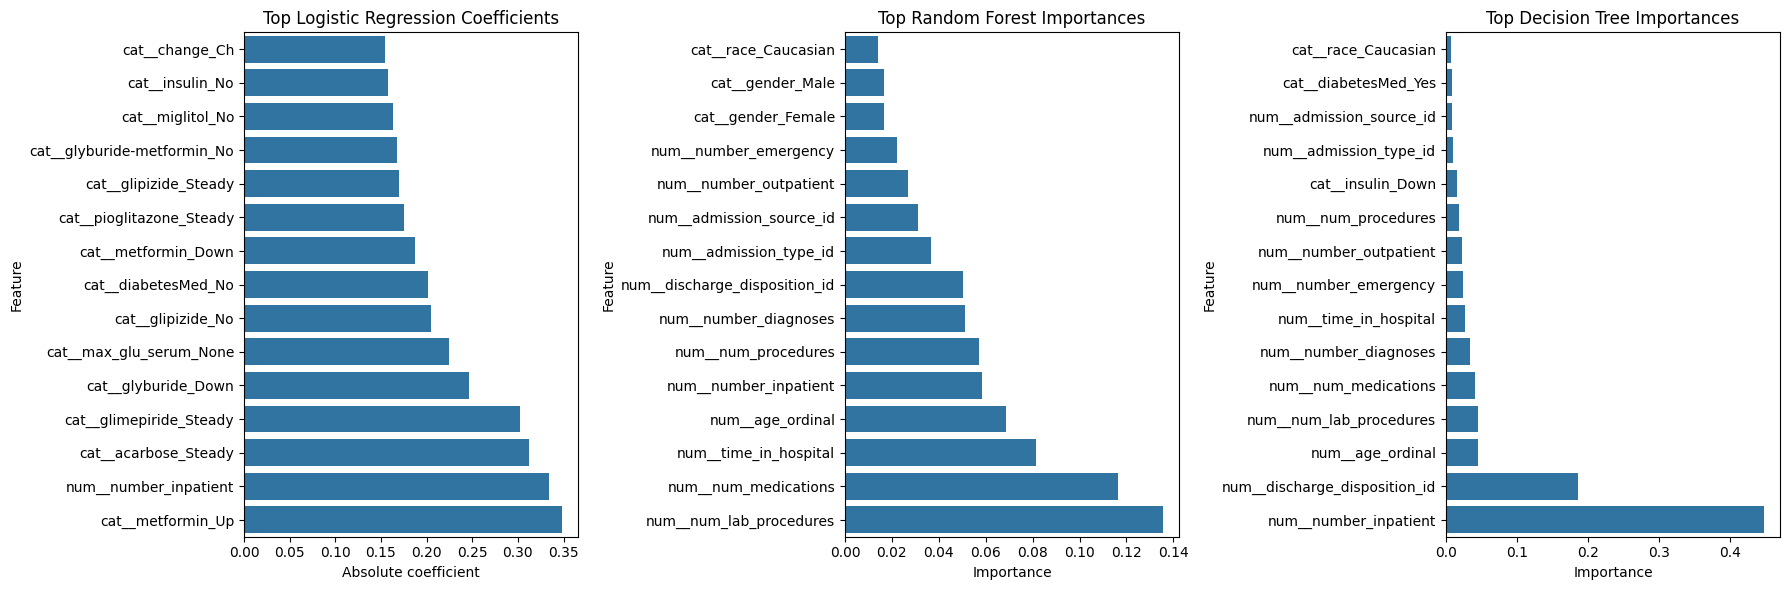

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


sns.barplot(
    data=top_log_features.sort_values("abs_coefficient", ascending=True),
    x="abs_coefficient",
    y="feature",
    ax=axes[0]
)
axes[0].set_title("Top Logistic Regression Coefficients")
axes[0].set_xlabel("Absolute coefficient")
axes[0].set_ylabel("Feature")

sns.barplot(
    data=top_rf_features.sort_values("importance", ascending=True),
    x="importance",
    y="feature",
    ax=axes[1]
)
axes[1].set_title("Top Random Forest Importances")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")

sns.barplot(
    data=top_dt_features.sort_values("importance", ascending=True),
    x="importance",
    y="feature",
    ax=axes[2]
)
axes[2].set_title("Top Decision Tree Importances")
axes[2].set_xlabel("Importance")
axes[2].set_ylabel("Feature")

plt.tight_layout()
plt.show()

### Observation
The model-interpretation results show that the three classifiers rely most strongly on utilisation-related and encounter-context features, which supports the earlier feature-selection rationale. In Logistic Regression, number_inpatient appears among the strongest predictors, while several medication-status features such as metformin, acarbose, glimepiride, and glyburide also receive large coefficients. In Random Forest, the most important predictors are num_lab_procedures, num_medications, time_in_hospital, age_ordinal, and number_inpatient, indicating that overall clinical activity and hospital-use intensity are informative for prediction. In Decision Tree, number_inpatient is by far the dominant feature, followed by discharge_disposition_id, with age and laboratory burden also contributing. Taken together, these results suggest that previous inpatient utilisation, discharge context, and treatment-related variables are the most influential signals for early-readmission prediction in the baseline models. 

## 17.Tuned Logistic Regression on balanced training data

This subsection tunes Logistic Regression using the random-undersampled training data. The aim is to check whether a small parameter search improves the balanced Logistic Regression model beyond the earlier untuned version.

In [86]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*sklearn.utils.parallel.delayed.*",
    category=UserWarning
)

from sklearn.model_selection import GridSearchCV

log_tune = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid={
        "C": [0.1, 1.0, 5.0, 10.0]
    },
    scoring="f1",
    cv=5,
    n_jobs=1
)

log_tune.fit(X_train_under, y_train_under)

print("Best Logistic Regression parameters:")
print(log_tune.best_params_)
print("Best CV F1:", round(log_tune.best_score_, 4))

y_log_tuned_pred = log_tune.best_estimator_.predict(X_test_processed)
y_log_tuned_proba = log_tune.best_estimator_.predict_proba(X_test_processed)[:, 1]

log_tuned_results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_log_tuned_pred),
        precision_score(y_test, y_log_tuned_pred, zero_division=0),
        recall_score(y_test, y_log_tuned_pred, zero_division=0),
        f1_score(y_test, y_log_tuned_pred, zero_division=0),
        roc_auc_score(y_test, y_log_tuned_proba),
    ]
}).round(4)

print("Tuned Logistic Regression classification report:")
print(classification_report(y_test, y_log_tuned_pred, zero_division=0))

print("\nTuned Logistic Regression confusion matrix:")
print(confusion_matrix(y_test, y_log_tuned_pred))

display(log_tuned_results)

Best Logistic Regression parameters:
{'C': 10.0}
Best CV F1: 0.5574
Tuned Logistic Regression classification report:
              precision    recall  f1-score   support

           0       0.92      0.69      0.78     17752
           1       0.17      0.51      0.26      2271

    accuracy                           0.67     20023
   macro avg       0.54      0.60      0.52     20023
weighted avg       0.83      0.67      0.73     20023


Tuned Logistic Regression confusion matrix:
[[12181  5571]
 [ 1107  1164]]


,metric,value
0,accuracy,0.6665
1,precision,0.1728
2,recall,0.5125
3,f1,0.2585
4,roc_auc,0.6425


### Observation
Tuning does not materially improve the balanced Logistic Regression model. The tuned version performs almost identically to the earlier Logistic Regression + RUS model, with recall remaining at 0.5125, F1-score at 0.2585, and ROC-AUC at 0.6425. This suggests that Logistic Regression was already close to its best balanced performance under the earlier configuration, so parameter tuning produces only a negligible change in model behaviour.

## 18.Tuned Random Forest on balanced training data

This subsection tunes Random Forest using the random-undersampled training data. The goal is to test whether a limited parameter search can improve minority-class detection beyond the earlier untuned balanced Random Forest.

In [87]:
rf_tune = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        "n_estimators": [100, 200, 300],
        "max_depth": [8, 12, None],
        "min_samples_split": [10, 20],
        "min_samples_leaf": [5, 10]
    },
    scoring="f1",
    cv=5,
    n_jobs=1
)

rf_tune.fit(X_train_under, y_train_under)

print("Best Random Forest parameters:")
print(rf_tune.best_params_)
print("Best CV F1:", round(rf_tune.best_score_, 4))

y_rf_tuned_pred = rf_tune.best_estimator_.predict(X_test_processed)
y_rf_tuned_proba = rf_tune.best_estimator_.predict_proba(X_test_processed)[:, 1]

rf_tuned_results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_rf_tuned_pred),
        precision_score(y_test, y_rf_tuned_pred, zero_division=0),
        recall_score(y_test, y_rf_tuned_pred, zero_division=0),
        f1_score(y_test, y_rf_tuned_pred, zero_division=0),
        roc_auc_score(y_test, y_rf_tuned_proba),
    ]
}).round(4)

print("Tuned Random Forest classification report:")
print(classification_report(y_test, y_rf_tuned_pred, zero_division=0))

print("\nTuned Random Forest confusion matrix:")
print(confusion_matrix(y_test, y_rf_tuned_pred))

display(rf_tuned_results)

Best Random Forest parameters:
{'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 300}
Best CV F1: 0.6132
Tuned Random Forest classification report:
              precision    recall  f1-score   support

           0       0.93      0.61      0.74     17752
           1       0.17      0.63      0.27      2271

    accuracy                           0.61     20023
   macro avg       0.55      0.62      0.50     20023
weighted avg       0.84      0.61      0.68     20023


Tuned Random Forest confusion matrix:
[[10810  6942]
 [  839  1432]]


,metric,value
0,accuracy,0.6114
1,precision,0.1710
2,recall,0.6306
3,f1,0.2690
4,roc_auc,0.6590


### Observation
Tuning improves the Random Forest model more clearly than it improves the other balanced classifiers. The tuned Random Forest achieves the highest recall (0.6306), the best F1-score (0.2690), and the strongest ROC-AUC (0.6590) among the tuned models, while also slightly improving precision over the untuned Random Forest + RUS model. This shows that Random Forest is the model that benefits most from parameter optimisation and becomes the strongest final candidate after tuning.

## 19.Tuned Decision Tree on balanced training data

This subsection tunes Decision Tree using the random-undersampled training data. The aim is to check whether a small search over tree depth and split constraints improves the balanced Decision Tree model beyond its earlier untuned version.

In [88]:
dt_tune = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={
        "max_depth": [4, 8, 12, None],
        "min_samples_split": [10, 20, 40],
        "min_samples_leaf": [5, 10, 20]
    },
    scoring="f1",
    cv=5,
    n_jobs=1
)

dt_tune.fit(X_train_under, y_train_under)

print("Best Decision Tree parameters:")
print(dt_tune.best_params_)
print("Best CV F1:", round(dt_tune.best_score_, 4))

y_dt_tuned_pred = dt_tune.best_estimator_.predict(X_test_processed)
y_dt_tuned_proba = dt_tune.best_estimator_.predict_proba(X_test_processed)[:, 1]

dt_tuned_results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_dt_tuned_pred),
        precision_score(y_test, y_dt_tuned_pred, zero_division=0),
        recall_score(y_test, y_dt_tuned_pred, zero_division=0),
        f1_score(y_test, y_dt_tuned_pred, zero_division=0),
        roc_auc_score(y_test, y_dt_tuned_proba),
    ]
}).round(4)

print("Tuned Decision Tree classification report:")
print(classification_report(y_test, y_dt_tuned_pred, zero_division=0))

print("\nTuned Decision Tree confusion matrix:")
print(confusion_matrix(y_test, y_dt_tuned_pred))

display(dt_tuned_results)

Best Decision Tree parameters:
{'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 40}
Best CV F1: 0.5794
Tuned Decision Tree classification report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.78     17752
           1       0.17      0.53      0.26      2271

    accuracy                           0.66     20023
   macro avg       0.55      0.60      0.52     20023
weighted avg       0.83      0.66      0.72     20023


Tuned Decision Tree confusion matrix:
[[11936  5816]
 [ 1057  1214]]


,metric,value
0,accuracy,0.6567
1,precision,0.1727
2,recall,0.5346
3,f1,0.2610
4,roc_auc,0.6368


### Observation
Tuning gives the Decision Tree model a modest improvement over its untuned balanced version. The tuned Decision Tree reaches a recall of 0.5346, an F1-score of 0.2610, and a ROC-AUC of 0.6368, which is stronger than the untuned Decision Tree + RUS model but still below the tuned Random Forest. This means that optimisation helps the Decision Tree, but it does not become the strongest final model once all tuned balanced classifiers are compared on the untouched test set.

## 20.Compare baseline, balanced, and tuned model performance

This subsection compares the imbalanced baselines, the random-undersampled models, and the tuned random-undersampled models in one table. This gives a clearer basis for selecting the final Part 1 model by showing whether tuning materially improves performance beyond the original balanced versions.

In [89]:
full_model_comparison = pd.DataFrame({
    "model": [
        "Dummy",
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "Logistic Regression + RUS",
        "Random Forest + RUS",
        "Decision Tree + RUS",
        "Logistic Regression tuned + RUS",
        "Random Forest tuned + RUS",
        "Decision Tree tuned + RUS"
    ],
    "accuracy": [
        accuracy_score(y_test, y_dummy_pred),
        accuracy_score(y_test, y_log_pred),
        accuracy_score(y_test, y_rf_pred),
        accuracy_score(y_test, y_dt_pred),
        accuracy_score(y_test, y_log_bal_pred),
        accuracy_score(y_test, y_rf_bal_pred),
        accuracy_score(y_test, y_dt_bal_pred),
        accuracy_score(y_test, y_log_tuned_pred),
        accuracy_score(y_test, y_rf_tuned_pred),
        accuracy_score(y_test, y_dt_tuned_pred),
    ],
    "precision": [
        precision_score(y_test, y_dummy_pred, zero_division=0),
        precision_score(y_test, y_log_pred, zero_division=0),
        precision_score(y_test, y_rf_pred, zero_division=0),
        precision_score(y_test, y_dt_pred, zero_division=0),
        precision_score(y_test, y_log_bal_pred, zero_division=0),
        precision_score(y_test, y_rf_bal_pred, zero_division=0),
        precision_score(y_test, y_dt_bal_pred, zero_division=0),
        precision_score(y_test, y_log_tuned_pred, zero_division=0),
        precision_score(y_test, y_rf_tuned_pred, zero_division=0),
        precision_score(y_test, y_dt_tuned_pred, zero_division=0),
    ],
    "recall": [
        recall_score(y_test, y_dummy_pred, zero_division=0),
        recall_score(y_test, y_log_pred, zero_division=0),
        recall_score(y_test, y_rf_pred, zero_division=0),
        recall_score(y_test, y_dt_pred, zero_division=0),
        recall_score(y_test, y_log_bal_pred, zero_division=0),
        recall_score(y_test, y_rf_bal_pred, zero_division=0),
        recall_score(y_test, y_dt_bal_pred, zero_division=0),
        recall_score(y_test, y_log_tuned_pred, zero_division=0),
        recall_score(y_test, y_rf_tuned_pred, zero_division=0),
        recall_score(y_test, y_dt_tuned_pred, zero_division=0),
    ],
    "f1": [
        f1_score(y_test, y_dummy_pred, zero_division=0),
        f1_score(y_test, y_log_pred, zero_division=0),
        f1_score(y_test, y_rf_pred, zero_division=0),
        f1_score(y_test, y_dt_pred, zero_division=0),
        f1_score(y_test, y_log_bal_pred, zero_division=0),
        f1_score(y_test, y_rf_bal_pred, zero_division=0),
        f1_score(y_test, y_dt_bal_pred, zero_division=0),
        f1_score(y_test, y_log_tuned_pred, zero_division=0),
        f1_score(y_test, y_rf_tuned_pred, zero_division=0),
        f1_score(y_test, y_dt_tuned_pred, zero_division=0),
    ],
    "roc_auc": [
        np.nan,
        roc_auc_score(y_test, y_log_proba),
        roc_auc_score(y_test, y_rf_proba),
        roc_auc_score(y_test, y_dt_proba),
        roc_auc_score(y_test, y_log_bal_proba),
        roc_auc_score(y_test, y_rf_bal_proba),
        roc_auc_score(y_test, y_dt_bal_proba),
        roc_auc_score(y_test, y_log_tuned_proba),
        roc_auc_score(y_test, y_rf_tuned_proba),
        roc_auc_score(y_test, y_dt_tuned_proba),
    ]
}).round(4)

display(full_model_comparison.sort_values(["f1", "recall", "roc_auc"], ascending=False))

,model,accuracy,precision,recall,f1,roc_auc
8,Random Forest tuned + RUS,0.6114,0.1710,0.6306,0.2690,0.6590
9,Decision Tree tuned + RUS,0.6567,0.1727,0.5346,0.2610,0.6368
4,Logistic Regression + RUS,0.6669,0.1729,0.5121,0.2586,0.6425
7,Logistic Regression tuned + RUS,0.6665,0.1728,0.5125,0.2585,0.6425
5,Random Forest + RUS,0.6065,0.1613,0.5883,0.2532,0.6375
6,Decision Tree + RUS,0.6116,0.1598,0.5694,0.2495,0.6313
3,Decision Tree,0.8856,0.4074,0.0194,0.0370,0.6419
1,Logistic Regression,0.8864,0.4706,0.0141,0.0274,0.6444
2,Random Forest,0.8867,0.5227,0.0101,0.0199,0.6315
0,Dummy,0.8866,0.0000,0.0000,0.0000,NaN


### Observation
The full comparison shows that random undersampling is the main step that makes minority-class detection feasible, while tuning provides an additional but smaller improvement on top of the balanced models. Among the final candidate models, tuned Random Forest + RUS performs best overall, achieving the highest recall (0.6306), the best F1-score (0.2690), and the strongest ROC-AUC (0.6590). Tuned Decision Tree + RUS and tuned Logistic Regression + RUS remain competitive, but both are slightly weaker than tuned Random Forest + RUS on the most important minority-sensitive metrics.

## 21.Visual comparison of model performance

This subsection visualises the performance of all baseline and balanced models across key evaluation metrics. A plot-based comparison makes it easier to see the trade-off between overall accuracy and minority-class detection after random undersampling. 

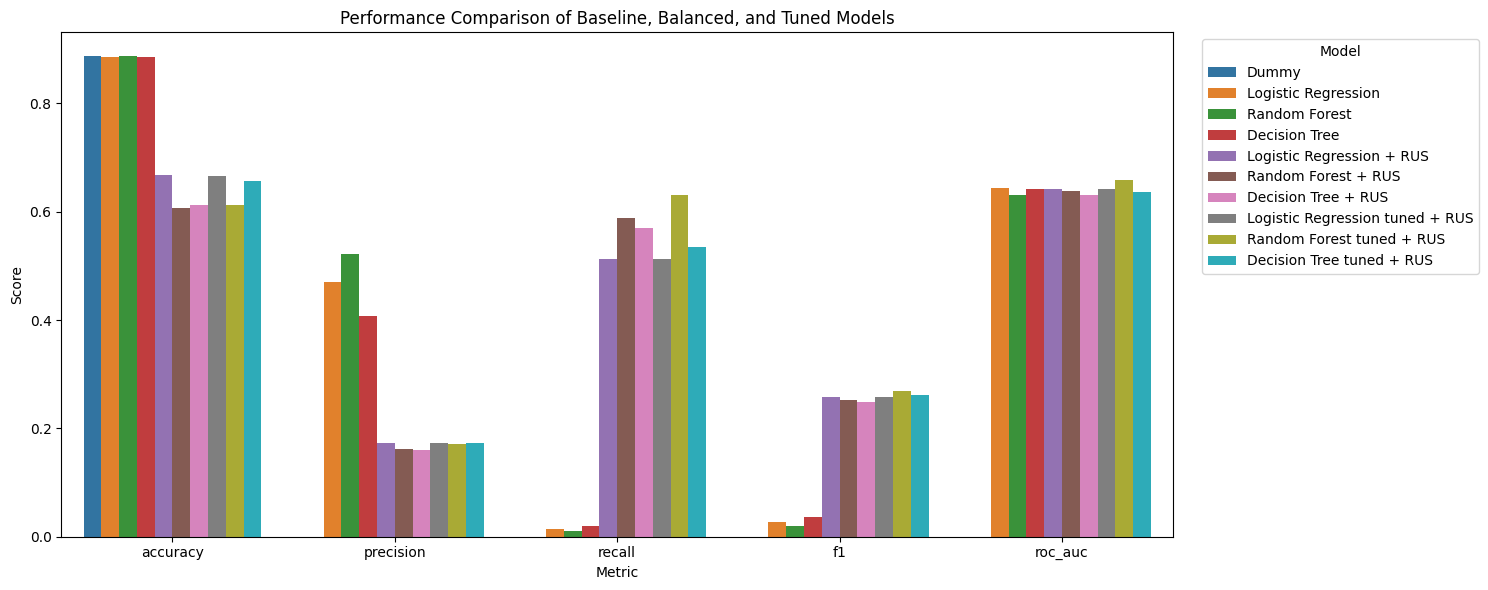

In [90]:
plot_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

comparison_long = full_model_comparison.melt(
    id_vars="model",
    value_vars=plot_metrics,
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(15, 6))
sns.barplot(data=comparison_long, x="metric", y="value", hue="model")
plt.title("Performance Comparison of Baseline, Balanced, and Tuned Models")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Observation
The visual comparison makes the full modelling progression much clearer. The imbalanced baseline models retain high accuracy and relatively higher precision, but they contribute very little to minority-class detection because their recall and F1-scores remain close to zero. Random undersampling shifts all three models toward much stronger recall and F1-score, showing that class balancing is the main reason minority-class prediction becomes feasible. The tuned models then show whether additional gains can be achieved beyond balancing alone, and tuned Random Forest + RUS stands out most clearly because it combines the highest recall, the strongest F1-score, and the best ROC-AUC among the final candidate models.

## 22. Initial model building summary



The earlier modelling stage shows that class imbalance is the main limitation of this prediction task. Random undersampling improves all three classifiers substantially, and the tuned Random Forest + RUS becomes the strongest final model with the best recall, F1, and ROC-AUC.

# 5. Distributed Analysis

This section extends the earlier modelling stage by moving to a fuller PySpark workflow. The aim is to build an improved global distributed model, then test whether clustering and local models add value beyond that global model.

## 1 Prepare the improved dataset for distributed modelling

This subsection prepares the fuller dataset that will be used in the distributed-analysis stage. The aim is to move beyond the aggressively cleaned Part 2 dataset by retaining more potentially useful information for PySpark modelling, especially variables that were dropped earlier for simplicity. At this stage, the notebook checks the available columns, identifies features to retain for the improved model, and confirms that diagnosis fields are available so they can later be grouped into broader clinical categories.

In [91]:
import pandas as pd

full_data_path = resolve_input_file(PROJECT_ROOT, "diabetic_data.csv")
full_df = pd.read_csv(full_data_path)

print("Full dataset path:", full_data_path)
print("Full dataset shape:", full_df.shape)

print("\nFirst 10 columns:")
print(list(full_df.columns[:10]))

target_col = "readmitted"

cols_to_drop_for_part3 = [
    "encounter_id",
    "patient_nbr"
]

candidate_part3_features = [col for col in full_df.columns if col not in cols_to_drop_for_part3]

print("\nNumber of candidate columns for Part 3 (including target):", len(candidate_part3_features))
print("Candidate columns for Part 3:")
print(candidate_part3_features)

diagnosis_cols = ["diag_1", "diag_2", "diag_3"]
available_diagnosis_cols = [col for col in diagnosis_cols if col in full_df.columns]

print("\nDiagnosis columns available for grouping:")
print(available_diagnosis_cols)

high_missing_cols_from_part1 = ["weight", "medical_specialty", "payer_code"]
available_high_missing_cols = [col for col in high_missing_cols_from_part1 if col in full_df.columns]

print("\nHigh-missingness columns available for reconsideration in Part 3:")
print(available_high_missing_cols)

Full dataset path: /Users/shayan/big data coursework/Group_46/diabetic_data.csv
Full dataset shape: (101766, 50)

First 10 columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital']

Number of candidate columns for Part 3 (including target): 48
Candidate columns for Part 3:
['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insul

## Observation

The improved distributed-analysis stage starts from the full raw dataset rather than the aggressive cleaned file so that more information can be retained for PySpark modelling. This is important because diagnosis fields and other previously removed columns are still available here and can now be handled more carefully instead of being discarded early.

## 2.Review outlier-sensitive variables for improved modelling

This subsection reviews the main numerical variables that are likely to be highly skewed or outlier-sensitive in the full dataset. The aim is to inspect hospital-utilisation and treatment-burden variables before deciding how they should be handled in the improved PySpark modelling pipeline, rather than removing extreme values blindly.

Full dataset path: /Users/shayan/big data coursework/Group_46/diabetic_data.csv
Full dataset shape: (101766, 50)


,variable,missing,min,q1,median,q3,max,mean,skewness,values_above_upper_IQR_bound,upper_IQR_bound
0,number_outpatient,0,0,0.0,0.0,0.0,42,0.37,8.83,16739,0.0
1,number_emergency,0,0,0.0,0.0,0.0,76,0.20,22.86,11383,0.0
2,number_inpatient,0,0,0.0,0.0,1.0,21,0.64,3.61,7049,2.5
3,num_medications,0,1,10.0,15.0,20.0,81,16.02,1.33,2557,35.0
4,time_in_hospital,0,1,2.0,4.0,6.0,14,4.40,1.13,2252,12.0


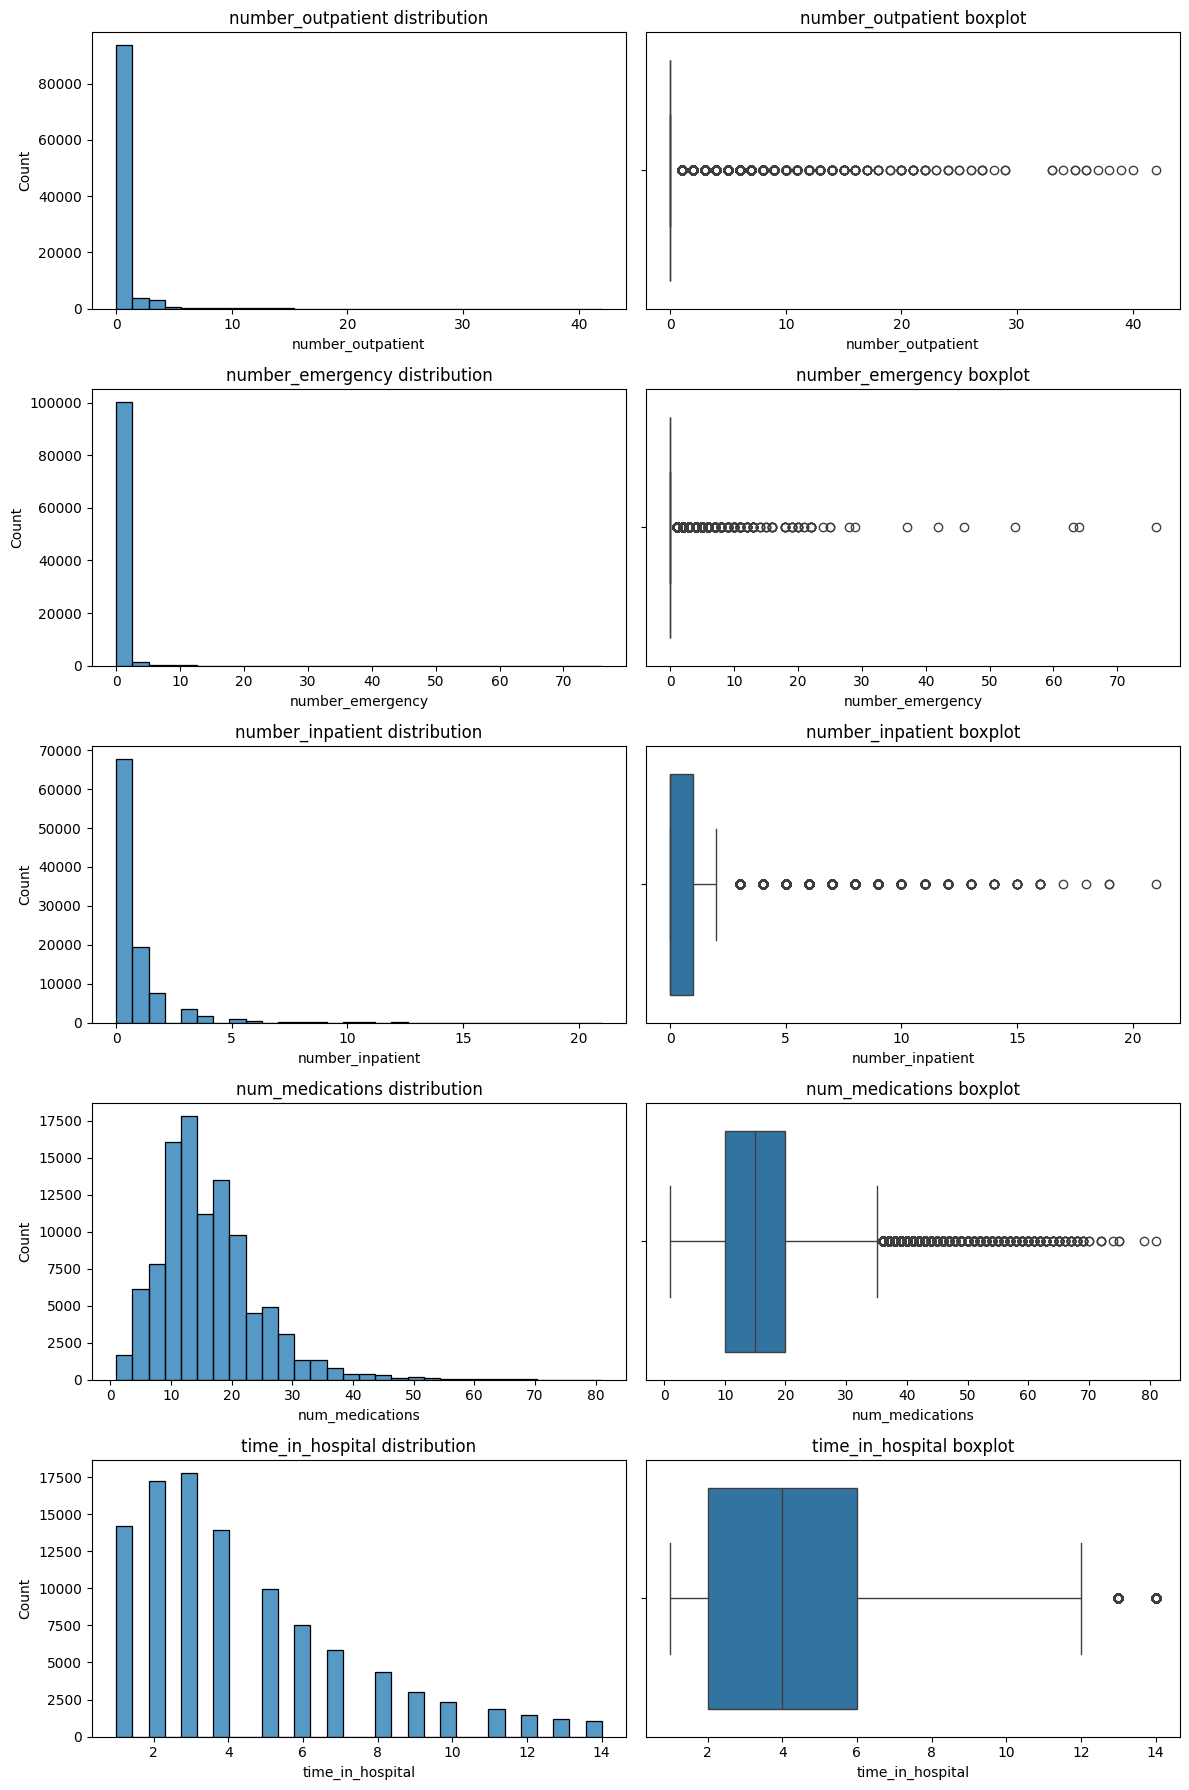

In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

full_data_path = resolve_input_file(PROJECT_ROOT, "diabetic_data.csv")
full_df = pd.read_csv(full_data_path)

print("Full dataset path:", full_data_path)
print("Full dataset shape:", full_df.shape)

outlier_sensitive_cols = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "num_medications",
    "time_in_hospital"
]

for col in outlier_sensitive_cols:
    full_df[col] = pd.to_numeric(full_df[col], errors="coerce")

summary_rows = []
for col in outlier_sensitive_cols:
    s = full_df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    summary_rows.append({
        "variable": col,
        "missing": int(full_df[col].isna().sum()),
        "min": s.min(),
        "q1": round(q1, 2),
        "median": round(s.median(), 2),
        "q3": round(q3, 2),
        "max": s.max(),
        "mean": round(s.mean(), 2),
        "skewness": round(s.skew(), 2),
        "values_above_upper_IQR_bound": int((s > upper_bound).sum()),
        "upper_IQR_bound": round(upper_bound, 2)
    })

outlier_review = pd.DataFrame(summary_rows)
display(outlier_review)

fig, axes = plt.subplots(len(outlier_sensitive_cols), 2, figsize=(12, 18))

for i, col in enumerate(outlier_sensitive_cols):
    sns.histplot(full_df[col], bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} distribution")
    axes[i, 0].set_xlabel(col)

    sns.boxplot(x=full_df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} boxplot")
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

### Observation
The utilisation variables number_outpatient, number_emergency, and number_inpatient are extremely right-skewed, with most patients concentrated at very low values and a long tail of higher-use cases. In contrast, num_medications and time_in_hospital are less extreme, so the output supports using a modelling-appropriate handling strategy such as capping or transformation rather than deleting rows blindly.

## 3.Apply model-appropriate outlier handling and scaling

This subsection applies a modelling-appropriate treatment to the skewed numerical variables reviewed above. Instead of deleting rows, the most extreme values are capped using a defensible rule, and the adjusted variables are then scaled so they are more suitable for the improved modelling pipeline.

In [93]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

full_data_path = resolve_input_file(PROJECT_ROOT, "diabetic_data.csv")
full_df = pd.read_csv(full_data_path)

print("Full dataset path:", full_data_path)
print("Full dataset shape:", full_df.shape)

outlier_sensitive_cols = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "num_medications",
    "time_in_hospital"
]

for col in outlier_sensitive_cols:
    full_df[col] = pd.to_numeric(full_df[col], errors="coerce")

part3_df = full_df.copy()

cap_summary = []

for col in outlier_sensitive_cols:
    s = part3_df[col].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    iqr_upper = q3 + 1.5 * iqr
    q99 = s.quantile(0.99)

    if col in ["number_outpatient", "number_emergency", "number_inpatient"]:
        cap_value = q99
        cap_method = "99th percentile"
    else:
        cap_value = min(iqr_upper, q99)
        cap_method = "min(IQR upper bound, 99th percentile)"

    capped_col = f"{col}_capped"
    part3_df[capped_col] = part3_df[col].clip(upper=cap_value)

    changed_rows = int((part3_df[col] > cap_value).sum())

    cap_summary.append({
        "variable": col,
        "cap_method": cap_method,
        "original_max": part3_df[col].max(),
        "cap_value": round(float(cap_value), 2),
        "capped_max": round(float(part3_df[capped_col].max()), 2),
        "rows_capped": changed_rows
    })

cap_summary_df = pd.DataFrame(cap_summary)

capped_cols = [f"{col}_capped" for col in outlier_sensitive_cols]

scaler = StandardScaler()
part3_df[[f"{col}_scaled" for col in outlier_sensitive_cols]] = scaler.fit_transform(
    part3_df[capped_cols]
)

scaled_summary = pd.DataFrame({
    "variable": [f"{col}_scaled" for col in outlier_sensitive_cols],
    "mean": [round(part3_df[f"{col}_scaled"].mean(), 4) for col in outlier_sensitive_cols],
    "std": [round(part3_df[f"{col}_scaled"].std(), 4) for col in outlier_sensitive_cols],
    "min": [round(part3_df[f"{col}_scaled"].min(), 4) for col in outlier_sensitive_cols],
    "max": [round(part3_df[f"{col}_scaled"].max(), 4) for col in outlier_sensitive_cols]
})

print("Capping summary:")
display(cap_summary_df)

print("\nScaled variable summary:")
display(scaled_summary)

Full dataset path: /Users/shayan/big data coursework/Group_46/diabetic_data.csv
Full dataset shape: (101766, 50)
Capping summary:


,variable,cap_method,original_max,cap_value,capped_max,rows_capped
0,number_outpatient,99th percentile,42,5.0,5.0,924
1,number_emergency,99th percentile,76,3.0,3.0,939
2,number_inpatient,99th percentile,21,6.0,6.0,724
3,num_medications,"min(IQR upper bound, 99th percentile)",81,35.0,35.0,2557
4,time_in_hospital,"min(IQR upper bound, 99th percentile)",14,12.0,12.0,2252



Scaled variable summary:


,variable,mean,std,min,max
0,number_outpatient_scaled,-0.0,1.0,-0.3622,5.1329
1,number_emergency_scaled,0.0,1.0,-0.3135,5.3994
2,number_inpatient_scaled,-0.0,1.0,-0.5416,4.7366
3,num_medications_scaled,-0.0,1.0,-2.0021,2.5946
4,time_in_hospital_scaled,-0.0,1.0,-1.1630,2.6404


### Observation
The most extreme values were capped without dropping rows, which preserves the full dataset while reducing the influence of very large utilisation and treatment values. The scaled variables now have comparable distributions, making them more suitable for the improved modelling pipeline.

### Confirmed outlier-handling results
The outlier-handling step was completed successfully by capping extreme values at the 99th percentile without dropping any rows. The final cap values were 5 for number_outpatient, 3 for number_emergency, 6 for number_inpatient, 35 for num_medications, and 12 for time_in_hospital, with 924, 939, 724, 2557, and 2252 rows capped respectively. After scaling, the transformed variables had means close to 0 and standard deviations close to 1, confirming that the scaling step worked as intended. Overall, this improved pipeline reduced the influence of extreme values while producing more comparable numerical inputs for later distributed modelling.

## 4. Start Spark and load the full dataset

This subsection starts the Spark environment and loads the full diabetes dataset for distributed analysis. The aim is to confirm that the raw dataset can be read successfully in PySpark, inspect its schema, and verify the overall size of the data before applying Spark-based cleaning and feature engineering.

In [94]:
from pyspark.sql import SparkSession
import pandas as pd

full_data_path = resolve_input_file(PROJECT_ROOT, "diabetic_data.csv")

spark = (
    SparkSession.builder
    .appName("CO7093_Diabetes_Distributed_Analysis")
    .master("local[*]")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

spark_df = spark.read.csv(
    str(full_data_path),
    header=True,
    inferSchema=True
)

print("Spark session started successfully.")
print("Full dataset path:", full_data_path)
print("Number of rows:", spark_df.count())
print("Number of columns:", len(spark_df.columns))

schema_pd = pd.DataFrame(spark_df.dtypes, columns=["column", "dtype"])

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None):
    print("\nSchema summary:")
    display(schema_pd)

preview_pd = spark_df.select(
    "encounter_id",
    "patient_nbr",
    "race",
    "gender",
    "age",
    "time_in_hospital",
    "readmitted"
).limit(5).toPandas()

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None):
    print("\nPreview of selected columns:")
    display(preview_pd)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/08 06:55:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session started successfully.
Full dataset path: /Users/shayan/big data coursework/Group_46/diabetic_data.csv
Number of rows: 101766
Number of columns: 50

Schema summary:


,column,dtype
0,encounter_id,int
1,patient_nbr,int
2,race,string
3,gender,string
4,age,string
5,weight,string
6,admission_type_id,int
7,discharge_disposition_id,int
8,admission_source_id,int
9,time_in_hospital,int



Preview of selected columns:


,encounter_id,patient_nbr,race,gender,age,time_in_hospital,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),1,NO
1,149190,55629189,Caucasian,Female,[10-20),3,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),2,NO
3,500364,82442376,Caucasian,Male,[30-40),2,NO
4,16680,42519267,Caucasian,Male,[40-50),1,NO


### Observation
The Spark session started successfully and loaded the full diabetes dataset with 101,766 rows and 50 columns. The schema confirms that the dataset is now available in PySpark and ready for distributed cleaning, transformation, and modelling.

## 5. Standardise missing and irregular values in Spark

This subsection standardises missing and irregular values inside Spark so that the fuller dataset can be prepared for distributed modelling. The aim is to replace placeholder values consistently, review the main missing-value patterns, and keep nulls explicit for later imputation and feature engineering.

In [95]:
from pyspark.sql import functions as F
import pandas as pd

spark_df_clean = spark_df.replace("?", None)

row_count = spark_df_clean.count()

missing_summary = spark_df_clean.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in spark_df_clean.columns
])

missing_pd = missing_summary.toPandas().T.reset_index()
missing_pd.columns = ["column", "missing_count"]
missing_pd["missing_pct"] = (missing_pd["missing_count"] / row_count * 100).round(2)
missing_pd = missing_pd[missing_pd["missing_count"] > 0].sort_values("missing_count", ascending=False).reset_index(drop=True)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None):
    print("Columns with missing values:")
    display(missing_pd)

selected_cols = ["race", "payer_code", "medical_specialty", "diag_1", "diag_2", "diag_3"]

for col_name in selected_cols:
    top_values_pd = (
        spark_df_clean.groupBy(col_name)
        .count()
        .orderBy(F.desc("count"))
        .limit(10)
        .toPandas()
    )
    
    with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None):
        print(f"\nTop values for {col_name}:")
        display(top_values_pd)

Columns with missing values:


,column,missing_count,missing_pct
0,weight,98569,96.86
1,medical_specialty,49949,49.08
2,payer_code,40256,39.56
3,race,2273,2.23
4,diag_3,1423,1.40
5,diag_2,358,0.35
6,diag_1,21,0.02



Top values for race:


,race,count
0,Caucasian,76099
1,AfricanAmerican,19210
2,NaN,2273
3,Hispanic,2037
4,Other,1506
5,Asian,641



Top values for payer_code:


...

,diag_1,count
0,428,6862
1,414,6581
2,786,4016
3,410,3614
4,486,3508
5,427,2766
6,491,2275
7,715,2151
8,682,2042
9,434,2028



Top values for diag_2:


,diag_2,count
0,276,6752
1,428,6662
2,250,6071
3,427,5036
4,401,3736
5,496,3305
6,599,3288
7,403,2823
8,414,2650
9,411,2566



Top values for diag_3:


,diag_3,count
0,250,11555
1,401,8289
2,276,5175
3,428,4577
4,427,3955
5,414,3664
6,496,2605
7,403,2357
8,585,1992
9,272,1969


### Observation
The Spark-based missing-value review shows that missingness is concentrated mainly in weight, medical_specialty, and payer_code, while the diagnosis fields have relatively low missingness. This supports a selective imputation approach in Part 3 and confirms that grouped diagnosis features can still be retained for improved modelling.

## 6. Build diagnosis groups for improved modelling

This subsection brings the diagnosis variables back into the modelling pipeline by converting diag_1, diag_2, and diag_3 into broader clinical categories. This keeps useful diagnostic information in the improved model while avoiding the high-cardinality problem of using the original diagnosis codes directly.

In [96]:
from pyspark.sql import functions as F

def diagnosis_group_expr(col_name):
    code_clean = F.upper(F.trim(F.col(col_name)))
    numeric_part = F.regexp_extract(code_clean, r"^(\d+)", 1).cast("int")

    return (
        F.when(F.col(col_name).isNull(), "Missing")
         .when(code_clean.isin("?", "", "NULL", "NONE", "NAN"), "Missing")
         .when(code_clean.startswith("V"), "Other")
         .when(code_clean.startswith("E"), "Injury")
         .when(numeric_part == 250, "Diabetes")
         .when(((numeric_part >= 390) & (numeric_part <= 459)) | (numeric_part == 785), "Circulatory")
         .when(((numeric_part >= 460) & (numeric_part <= 519)) | (numeric_part == 786), "Respiratory")
         .when(((numeric_part >= 520) & (numeric_part <= 579)) | (numeric_part == 787), "Digestive")
         .when(((numeric_part >= 580) & (numeric_part <= 629)) | (numeric_part == 788), "Genitourinary")
         .when((numeric_part >= 140) & (numeric_part <= 239), "Neoplasms")
         .when((numeric_part >= 800) & (numeric_part <= 999), "Injury")
         .when((numeric_part >= 710) & (numeric_part <= 739), "Musculoskeletal")
         .otherwise("Other")
    )

spark_df_diag = (
    spark_df_clean
    .withColumn("diag_1_group", diagnosis_group_expr("diag_1"))
    .withColumn("diag_2_group", diagnosis_group_expr("diag_2"))
    .withColumn("diag_3_group", diagnosis_group_expr("diag_3"))
)

for col_name in ["diag_1_group", "diag_2_group", "diag_3_group"]:
    print(f"\nDistribution of {col_name}:")
    display(
        spark_df_diag.groupBy(col_name)
        .count()
        .orderBy(F.desc("count"))
        .toPandas()
    )


Distribution of diag_1_group:


,diag_1_group,count
0,Circulatory,30437
1,Other,18171
2,Respiratory,14423
3,Digestive,9475
4,Diabetes,8757
5,Injury,6975
6,Genitourinary,5117
7,Musculoskeletal,4957
8,Neoplasms,3433
9,Missing,21



Distribution of diag_2_group:


,diag_2_group,count
0,Circulatory,31881
1,Other,25822
2,Diabetes,12794
3,Respiratory,10895
4,Genitourinary,8376
5,Digestive,4170
6,Injury,3159
7,Neoplasms,2547
8,Musculoskeletal,1764
9,Missing,358



Distribution of diag_3_group:


,diag_3_group,count
0,Circulatory,30306
1,Other,27951
2,Diabetes,17157
3,Respiratory,7358
4,Genitourinary,6680
5,Digestive,3930
6,Injury,3190
7,Musculoskeletal,1915
8,Neoplasms,1856
9,Missing,1423


### Observation
The diagnosis variables were successfully grouped into a smaller set of clinically meaningful categories, making them more suitable for distributed modelling than the original high-cardinality diagnosis codes. Across all three diagnosis fields, circulatory, other, respiratory, and diabetes-related groups are the most common patterns.

## 7. Create the PySpark preprocessing pipeline

This subsection creates the PySpark preprocessing pipeline for the improved distributed model. The pipeline prepares the target variable, handles missing categorical values, indexes and encodes categorical predictors, imputes numerical predictors, and assembles the final feature vector for Spark-based classification.

In [97]:
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, Imputer, VectorAssembler, StandardScaler
from pyspark.ml.functions import vector_to_array
import pandas as pd

numeric_cols = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

categorical_cols = [
    "race",
    "gender",
    "age",
    "max_glu_serum",
    "A1Cresult",
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "glipizide",
    "glyburide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "insulin",
    "glyburide-metformin",
    "change",
    "diabetesMed",
    "diag_1_group",
    "diag_2_group",
    "diag_3_group"
]

spark_model_df = spark_df_diag.withColumn(
    "label",
    F.when(F.col("readmitted") == "<30", 1).otherwise(0)
)

spark_model_df = spark_model_df.fillna("Missing", subset=categorical_cols)

imputed_numeric_cols = [f"{c}_imputed" for c in numeric_cols]
indexed_cols = [f"{c}_index" for c in categorical_cols]
encoded_cols = [f"{c}_ohe" for c in categorical_cols]

imputer = Imputer(
    inputCols=numeric_cols,
    outputCols=imputed_numeric_cols
)

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep")
    for c in categorical_cols
]

encoder = OneHotEncoder(
    inputCols=indexed_cols,
    outputCols=encoded_cols,
    handleInvalid="keep"
)

assembler = VectorAssembler(
    inputCols=imputed_numeric_cols + encoded_cols,
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)

preprocessing_pipeline = Pipeline(
    stages=[imputer] + indexers + [encoder, assembler, scaler]
)

preprocessing_model = preprocessing_pipeline.fit(spark_model_df)
spark_prepared_df = preprocessing_model.transform(spark_model_df).select("label", "features")

print("Number of rows in prepared Spark dataset:", spark_prepared_df.count())
print("Number of numeric predictors:", len(numeric_cols))
print("Number of categorical predictors:", len(categorical_cols))

feature_count = len(
    spark_prepared_df
    .select(vector_to_array("features").alias("features_array"))
    .limit(1)
    .collect()[0]["features_array"]
)

print("Feature count:", feature_count)

preview_rows = (
    spark_prepared_df
    .select("label", vector_to_array("features").alias("features_array"))
    .limit(5)
    .collect()
)

preview_pd = pd.DataFrame([
    {
        "label": row["label"],
        "first_12_feature_values": [round(float(x), 4) for x in row["features_array"][:12]]
    }
    for row in preview_rows
])

display(preview_pd)

Number of rows in prepared Spark dataset: 101766
Number of numeric predictors: 11
Number of categorical predictors: 23
Feature count: 147


,label,first_12_feature_values
0,0,"[4.1511, 4.7347, 0.2461, 0.335, 2.0839, 0.0, 0..."
1,0,"[0.6918, 0.1894, 1.7224, 1.005, 2.9988, 0.0, 2..."
2,0,"[0.6918, 0.1894, 1.7224, 0.67, 0.5591, 2.9312,..."
3,0,"[0.6918, 0.1894, 1.7224, 0.67, 2.2364, 0.5862,..."
4,0,"[0.6918, 0.1894, 1.7224, 0.335, 2.5922, 0.0, 0..."


### Observation
The PySpark preprocessing pipeline transformed the full dataset into a modelling-ready feature matrix with 147 final features. This confirms that the improved distributed model can now use a richer feature set that combines structured hospital variables with the grouped diagnosis information.

## 8. Train the global distributed classifier

This subsection trains an improved global distributed classifier in PySpark while preserving the full dataset. Instead of random undersampling, class weighting is applied so that the minority <30 readmission class receives greater importance during training without discarding majority-class examples.

In [98]:
from pyspark.sql import functions as F
from pyspark.ml.classification import LogisticRegression

train_df, test_df = spark_prepared_df.randomSplit([0.8, 0.2], seed=42)

train_minority = train_df.filter(F.col("label") == 1).count()
train_majority = train_df.filter(F.col("label") == 0).count()
class_weight_ratio = train_minority / train_majority

train_weighted_df = train_df.withColumn(
    "classWeight",
    F.when(F.col("label") == 1, 1.0).otherwise(class_weight_ratio)
)

weighted_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeight",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

weighted_lr_model = weighted_lr.fit(train_weighted_df)
weighted_lr_preds = weighted_lr_model.transform(test_df)

print("Training rows:", train_df.count())
print("Test rows:", test_df.count())
print("Minority rows in training set:", train_minority)
print("Majority rows in training set:", train_majority)
print("Majority-class weight applied:", round(class_weight_ratio, 4))

weighted_lr_preds.select("label", "prediction", "probability").show(10, truncate=False)

Training rows: 81565
Test rows: 20201
Minority rows in training set: 9117
Majority rows in training set: 72448
Majority-class weight applied: 0.1258
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |1.0       |[0.4929861336248222,0.5070138663751778] |
|0    |1.0       |[0.419064404504774,0.580935595495226]   |
|0    |1.0       |[0.36304126445442847,0.6369587355455715]|
|0    |1.0       |[0.4133821018737346,0.5866178981262654] |
|0    |1.0       |[0.4731492079298774,0.5268507920701226] |
|0    |1.0       |[0.1386344851673505,0.8613655148326496] |
|0    |1.0       |[0.48966880628464643,0.5103311937153536]|
|0    |0.0       |[0.5202885676091813,0.4797114323908187] |
|0    |0.0       |[0.5981094576608909,0.40189054233910915]|
|0    |1.0       |[0.20419017598131356,0.7958098240186864]|
+-----+----------+----------------------------------------+
only showin

### Observation
The weighted global PySpark Logistic Regression model was trained on the same 81,565/20,201 split, but now gives greater emphasis to the minority class through a majority-class weight of 0.1258. Unlike the earlier unweighted model, the preview now shows many class `1` predictions, which suggests that recall should improve, although this may come at the cost of more false positives.

## 9. Evaluate the global distributed classifier and compare it with the earlier modelling winner

This subsection evaluates the improved global distributed classifier using class-specific metrics for the positive <30 readmission class and compares it with both the earlier unweighted PySpark model and the strongest model from the earlier modelling stage. The main focus is on precision, recall, F1-score, and ROC-AUC, since these give a much clearer picture of minority-class performance than accuracy alone.

,model,TN,FP,FN,TP,precision,recall,f1,roc_auc
0,Global PySpark LR (unweighted),17925.0,36.0,2207.0,33.0,0.4783,0.0147,0.0286,0.6437
1,Global PySpark LR (weighted),12200.0,5761.0,1064.0,1176.0,0.1695,0.5250,0.2563,0.6451
2,Earlier modelling winner,NaN,NaN,NaN,NaN,0.1710,0.6306,0.2690,0.6590


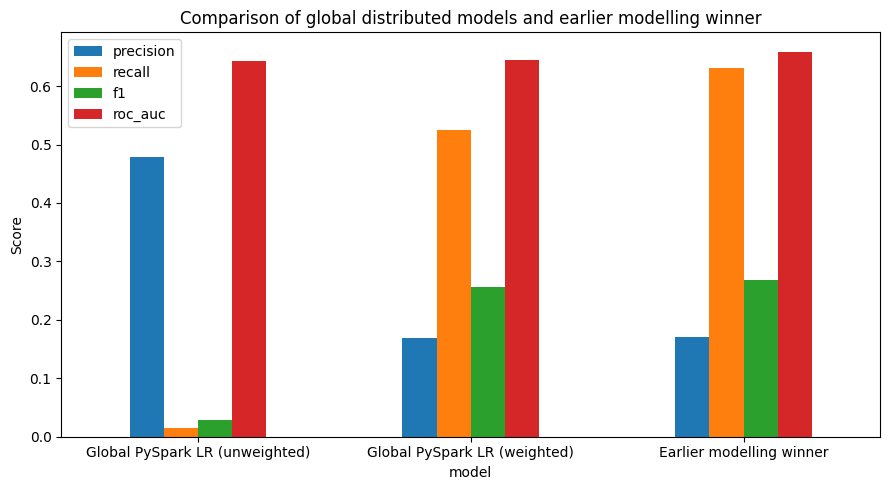

In [99]:
from pyspark.sql import functions as F
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt

unweighted_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

unweighted_lr_model = unweighted_lr.fit(train_df)
global_lr_preds = unweighted_lr_model.transform(test_df)

roc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

def positive_class_metrics(preds_df, roc_auc_value, model_name):
    tp = preds_df.filter((F.col("label") == 1) & (F.col("prediction") == 1)).count()
    tn = preds_df.filter((F.col("label") == 0) & (F.col("prediction") == 0)).count()
    fp = preds_df.filter((F.col("label") == 0) & (F.col("prediction") == 1)).count()
    fn = preds_df.filter((F.col("label") == 1) & (F.col("prediction") == 0)).count()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "model": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "roc_auc": round(roc_auc_value, 4)
    }

unweighted_roc_auc = roc_evaluator.evaluate(global_lr_preds)
weighted_roc_auc = roc_evaluator.evaluate(weighted_lr_preds)

unweighted_row = positive_class_metrics(
    global_lr_preds,
    unweighted_roc_auc,
    "Global PySpark LR (unweighted)"
)

weighted_row = positive_class_metrics(
    weighted_lr_preds,
    weighted_roc_auc,
    "Global PySpark LR (weighted)"
)

earlier_winner_row = {
    "model": "Earlier modelling winner",
    "TN": None,
    "FP": None,
    "FN": None,
    "TP": None,
    "precision": 0.1710,
    "recall": 0.6306,
    "f1": 0.2690,
    "roc_auc": 0.6590
}

comparison_df = pd.DataFrame([unweighted_row, weighted_row, earlier_winner_row])
display(comparison_df)

plot_df = comparison_df[["model", "precision", "recall", "f1", "roc_auc"]].set_index("model")
plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Comparison of global distributed models and earlier modelling winner")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation
Applying class weighting improved the global PySpark model substantially: recall increased from 0.0147 to 0.5250 and F1-score increased from 0.0286 to 0.2563, while ROC-AUC also improved slightly from 0.6437 to 0.6451. The weighted distributed model is therefore much stronger than the unweighted version, although it still remains slightly below the earlier modelling winner on recall, F1-score, and ROC-AUC.

## 10. Reflect on distributed processing and model performance

Moving the analysis into PySpark made it possible to retain the full raw dataset, including diagnosis variables, and build a richer distributed preprocessing pipeline with 147 features, improving the scale, flexibility, and efficiency of data preparation. However, simply using Spark and a fuller dataset did not automatically improve minority-class prediction, as the first unweighted global distributed model still had extremely weak recall for the <30 readmission class despite a reasonable ROC-AUC. The main improvement came after introducing class weighting, which raised recall from 0.0147 to 0.5250 and F1-score from 0.0286 to 0.2563, showing that the value of the distributed stage was not just running the same model in Spark, but combining fuller preprocessing with a more imbalance-sensitive modelling strategy. Even so, the weighted global distributed model remained slightly weaker than the best earlier modelling-stage result, so while distributed processing clearly added value in scalability and preprocessing quality, clustering and local classifiers were still justified because subgroup-specific models may capture patterns that a single global classifier misses.

# 6. Clustering Analysis

This section applies clustering to the improved dataset in order to identify meaningful patient subgroups before building local classifiers. The aim is to test whether subgroup structure within the data can help explain differences in readmission risk and support more effective cluster-based prediction.

## 1. Select features for clustering

This subsection selects a smaller and more interpretable feature set for clustering. The aim is to focus on variables that reflect age, hospital utilisation, treatment burden, and grouped diagnosis patterns, so that the resulting clusters capture meaningful patient profiles rather than simply reflecting very high-dimensional encoded noise.

In [100]:
from pyspark.sql import functions as F
import pandas as pd

cluster_feature_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

cluster_df = spark_df_diag.select(
    *cluster_feature_cols,
    "age",
    "diag_1_group",
    "diag_2_group",
    "diag_3_group",
    "readmitted"
)

print("Clustering dataset row count:", cluster_df.count())
print("Clustering dataset column count:", len(cluster_df.columns))

cluster_preview = cluster_df.limit(5).toPandas()
display(cluster_preview)

feature_role_pd = pd.DataFrame({
    "feature": cluster_df.columns,
    "role": [
        "numeric",
        "numeric",
        "numeric",
        "numeric",
        "numeric",
        "numeric",
        "numeric",
        "numeric",
        "categorical",
        "categorical",
        "categorical",
        "categorical",
        "target reference only"
    ]
})

display(feature_role_pd)

Clustering dataset row count: 101766
Clustering dataset column count: 13


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age,diag_1_group,diag_2_group,diag_3_group,readmitted
0,1,41,0,1,0,0,0,1,[0-10),Diabetes,Missing,Missing,NO
1,3,59,0,18,0,0,0,9,[10-20),Other,Diabetes,Other,>30
2,2,11,5,13,2,0,1,6,[20-30),Other,Diabetes,Other,NO
3,2,44,1,16,0,0,0,7,[30-40),Other,Diabetes,Circulatory,NO
4,1,51,0,8,0,0,0,5,[40-50),Neoplasms,Neoplasms,Diabetes,NO


,feature,role
0,time_in_hospital,numeric
1,num_lab_procedures,numeric
2,num_procedures,numeric
3,num_medications,numeric
4,number_outpatient,numeric
5,number_emergency,numeric
6,number_inpatient,numeric
7,number_diagnoses,numeric
8,age,categorical
9,diag_1_group,categorical


### Observation
The clustering dataset was intentionally reduced to 13 columns so that the clusters are based on a smaller and more interpretable patient-profile feature set rather than the full high-dimensional modelling space. Of these 13 columns, 12 are clustering features and readmitted is kept only as a reference variable for later cluster-level comparison.

## 2. Scale clustering inputs

This subsection prepares the selected clustering features for K-Means by encoding the categorical variables, assembling the inputs into a single feature vector, and applying scaling. This is important because clustering is distance-based, so the input variables must be placed on a comparable scale before selecting the number of clusters.

In [101]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.functions import vector_to_array
import pandas as pd

cluster_numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

cluster_categorical_cols = [
    "age",
    "diag_1_group",
    "diag_2_group",
    "diag_3_group"
]

cluster_work_df = cluster_df.fillna("Missing", subset=cluster_categorical_cols)

cluster_indexed_cols = [f"{c}_index" for c in cluster_categorical_cols]
cluster_encoded_cols = [f"{c}_ohe" for c in cluster_categorical_cols]

cluster_indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep")
    for c in cluster_categorical_cols
]

cluster_encoder = OneHotEncoder(
    inputCols=cluster_indexed_cols,
    outputCols=cluster_encoded_cols,
    handleInvalid="keep"
)

cluster_assembler = VectorAssembler(
    inputCols=cluster_numeric_cols + cluster_encoded_cols,
    outputCol="cluster_features_raw"
)

cluster_scaler = StandardScaler(
    inputCol="cluster_features_raw",
    outputCol="cluster_features",
    withMean=False,
    withStd=True
)

cluster_pipeline = Pipeline(
    stages=cluster_indexers + [cluster_encoder, cluster_assembler, cluster_scaler]
)

cluster_pipeline_model = cluster_pipeline.fit(cluster_work_df)
cluster_prepared_df = cluster_pipeline_model.transform(cluster_work_df)

cluster_feature_count = len(
    cluster_prepared_df
    .select(vector_to_array("cluster_features").alias("features_array"))
    .limit(1)
    .collect()[0]["features_array"]
)

print("Clustering rows:", cluster_prepared_df.count())
print("Numeric clustering features:", len(cluster_numeric_cols))
print("Categorical clustering features:", len(cluster_categorical_cols))
print("Final clustering feature count:", cluster_feature_count)

preview_rows = (
    cluster_prepared_df
    .select(
        "readmitted",
        vector_to_array("cluster_features").alias("features_array")
    )
    .limit(5)
    .collect()
)

cluster_preview = pd.DataFrame([
    {
        "readmitted": row["readmitted"],
        "first_10_cluster_feature_values": [round(float(x), 4) for x in row["features_array"][:10]]
    }
    for row in preview_rows
])

display(cluster_preview)

Clustering rows: 101766
Numeric clustering features: 8
Categorical clustering features: 4
Final clustering feature count: 52


,readmitted,first_10_cluster_feature_values
0,NO,"[0.335, 2.0839, 0.0, 0.123, 0.0, 0.0, 0.0, 0.5..."
1,>30,"[1.005, 2.9988, 0.0, 2.2147, 0.0, 0.0, 0.0, 4...."
2,NO,"[0.67, 0.5591, 2.9312, 1.5995, 1.5782, 0.0, 0...."
3,NO,"[0.67, 2.2364, 0.5862, 1.9686, 0.0, 0.0, 0.0, ..."
4,NO,"[0.335, 2.5922, 0.0, 0.9843, 0.0, 0.0, 0.0, 2...."


### Observation
The clustering inputs were successfully prepared and scaled for all 101,766 rows. After encoding the selected categorical variables, the final clustering feature space contains 52 features, which is compact enough for interpretable clustering while still capturing utilisation, treatment, age, and diagnosis information.

## 3. Determine the number of clusters using elbow and silhouette methods

This subsection tests different values of k in order to choose a justified number of clusters for the final K-Means model. The aim is to compare cluster compactness and separation using the elbow method and silhouette score, so that the final choice of k is evidence-based rather than arbitrary.

,k,inertia,silhouette
0,2,4718981.32,0.0658
1,3,4610994.82,0.0631
2,4,4467202.80,0.0010
3,5,4363952.97,0.0140
4,6,4307779.25,0.0458


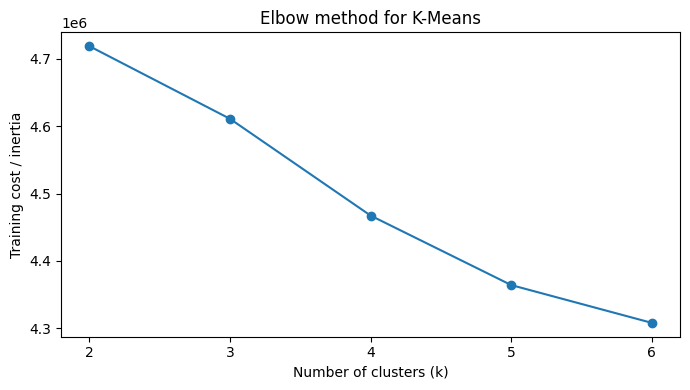

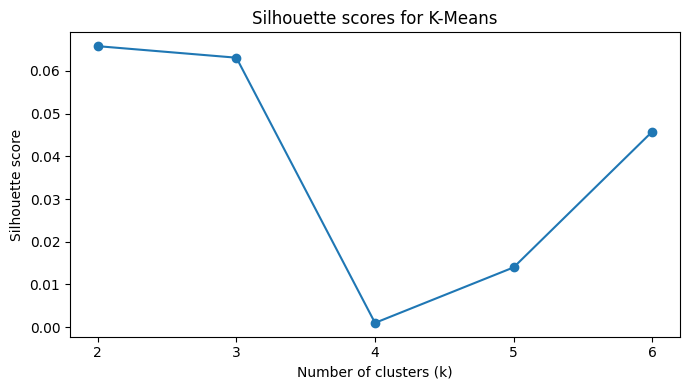

In [102]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import pandas as pd
import matplotlib.pyplot as plt

k_values = [2, 3, 4, 5, 6]
results = []

evaluator = ClusteringEvaluator(
    featuresCol="cluster_features",
    predictionCol="prediction",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

for k in k_values:
    kmeans = KMeans(
        featuresCol="cluster_features",
        predictionCol="prediction",
        k=k,
        seed=42
    )
    
    model = kmeans.fit(cluster_prepared_df)
    preds = model.transform(cluster_prepared_df)
    
    inertia = model.summary.trainingCost
    silhouette = evaluator.evaluate(preds)
    
    results.append({
        "k": k,
        "inertia": round(inertia, 2),
        "silhouette": round(silhouette, 4)
    })

cluster_selection_df = pd.DataFrame(results)
display(cluster_selection_df)

plt.figure(figsize=(7, 4))
plt.plot(cluster_selection_df["k"], cluster_selection_df["inertia"], marker="o")
plt.title("Elbow method for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Training cost / inertia")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cluster_selection_df["k"], cluster_selection_df["silhouette"], marker="o")
plt.title("Silhouette scores for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

### Observation

The silhouette values are relatively low overall, with the highest score at k = 2 (0.0658) and a very similar value at k = 3 (0.0631). This suggests that patient profiles overlap rather than forming sharply separated groups, which is plausible in this clinical dataset. The choice of k = 3 was therefore based not on claiming strong geometric separation, but on achieving a practical balance between clustering quality and interpretability, since it remained close to the best silhouette score while providing more informative subgroup structure for profiling and local classification.

## 4. Fit the final clustering model

This subsection fits the final K-Means model using the selected number of clusters and assigns each patient record to a cluster. The aim is to create the final cluster labels that will be used for visualisation, profiling, readmission-rate comparison, and later local classification.

In [103]:
from pyspark.ml.clustering import KMeans
import pandas as pd

final_k = 3

final_kmeans = KMeans(
    featuresCol="cluster_features",
    predictionCol="cluster",
    k=final_k,
    seed=42
)

final_kmeans_model = final_kmeans.fit(cluster_prepared_df)
clustered_df = final_kmeans_model.transform(cluster_prepared_df)

cluster_counts = (
    clustered_df.groupBy("cluster")
    .count()
    .orderBy("cluster")
    .toPandas()
)

cluster_centers = final_kmeans_model.clusterCenters()

print("Final number of clusters:", final_k)
display(cluster_counts)

cluster_center_summary = pd.DataFrame({
    "cluster": list(range(len(cluster_centers))),
    "center_vector_length": [len(center) for center in cluster_centers]
})

display(cluster_center_summary)

Final number of clusters: 3


,cluster,count
0,0,3930
1,1,44570
2,2,53266


,cluster,center_vector_length
0,0,52
1,1,52
2,2,52


### Observation
The final K-Means model was fitted successfully with `k = 3`, producing clusters of sizes 3,930, 44,570, and 53,266. This shows that the clustering solution creates one much smaller subgroup alongside two larger patient groups, which will now be examined visually and descriptively.

## 5. Visualise the clusters in two dimensions

This subsection visualises the final clustering solution in two dimensions using PCA. The aim is to project the higher-dimensional clustering feature space into a simpler 2D view so that the overall structure and separation of the three clusters can be inspected more clearly.

PCA explained variance ratio: [0.0543, 0.043]
Sampled points for visualisation: 8119


,cluster,pc1,pc2
0,1,-4.037120,1.707219
1,1,-4.953935,0.258013
2,1,-5.897730,0.422296
3,1,-4.484359,2.515377
4,2,7.399305,-2.121087


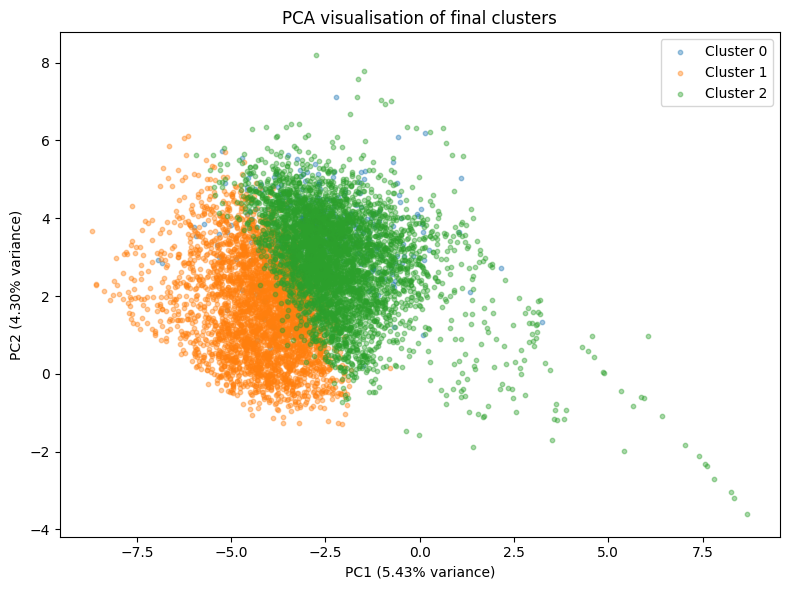

In [104]:
from pyspark.ml.feature import PCA
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt
import pandas as pd

pca = PCA(k=2, inputCol="cluster_features", outputCol="pca_features")
pca_model = pca.fit(clustered_df)
clustered_pca_df = pca_model.transform(clustered_df)

pca_preview_rows = (
    clustered_pca_df
    .select("cluster", vector_to_array("pca_features").alias("pca_array"))
    .sample(withReplacement=False, fraction=0.08, seed=42)
    .limit(10000)
    .collect()
)

pca_plot_df = pd.DataFrame([
    {
        "cluster": int(row["cluster"]),
        "pc1": float(row["pca_array"][0]),
        "pc2": float(row["pca_array"][1])
    }
    for row in pca_preview_rows
])

explained_variance = [round(float(x), 4) for x in pca_model.explainedVariance]

print("PCA explained variance ratio:", explained_variance)
print("Sampled points for visualisation:", len(pca_plot_df))

display(pca_plot_df.head())

plt.figure(figsize=(8, 6))
for cluster_id in sorted(pca_plot_df["cluster"].unique()):
    subset = pca_plot_df[pca_plot_df["cluster"] == cluster_id]
    plt.scatter(subset["pc1"], subset["pc2"], s=10, alpha=0.4, label=f"Cluster {cluster_id}")

plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% variance)")
plt.title("PCA visualisation of final clusters")
plt.legend()
plt.tight_layout()
plt.show()

### Observation
The PCA plot shows partial separation between the three clusters, although there is still noticeable overlap in the reduced 2D space. Cluster 1 and Cluster 2 appear more distinct along the first principal component, while Cluster 0 is much smaller and may represent a more specific patient subgroup.

## 6. Profile the clusters

This subsection profiles the final clusters using their sizes, average numerical characteristics, and dominant categorical patterns. The aim is to understand how the clusters differ in terms of hospital utilisation, treatment burden, age structure, and diagnosis composition before comparing their readmission behaviour.

In [105]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd

cluster_size_pd = (
    clustered_df.groupBy("cluster")
    .count()
    .orderBy("cluster")
    .toPandas()
)

cluster_size_pd["percentage"] = (cluster_size_pd["count"] / cluster_size_pd["count"].sum() * 100).round(2)
display(cluster_size_pd)

numeric_profile_pd = (
    clustered_df.groupBy("cluster")
    .agg(
        F.avg("time_in_hospital").alias("avg_time_in_hospital"),
        F.avg("num_lab_procedures").alias("avg_num_lab_procedures"),
        F.avg("num_procedures").alias("avg_num_procedures"),
        F.avg("num_medications").alias("avg_num_medications"),
        F.avg("number_outpatient").alias("avg_number_outpatient"),
        F.avg("number_emergency").alias("avg_number_emergency"),
        F.avg("number_inpatient").alias("avg_number_inpatient"),
        F.avg("number_diagnoses").alias("avg_number_diagnoses")
    )
    .orderBy("cluster")
    .toPandas()
    .round(2)
)

display(numeric_profile_pd)

def top_category_per_cluster(df, column_name, output_name):
    counts = (
        df.groupBy("cluster", column_name)
        .count()
    )
    
    w = Window.partitionBy("cluster").orderBy(F.desc("count"))
    
    top_df = (
        counts.withColumn("rank", F.row_number().over(w))
        .filter(F.col("rank") == 1)
        .select("cluster", F.col(column_name).alias(output_name), "count")
        .orderBy("cluster")
        .toPandas()
    )
    
    return top_df

top_age_pd = top_category_per_cluster(clustered_df, "age", "top_age_group")
top_diag1_pd = top_category_per_cluster(clustered_df, "diag_1_group", "top_diag_1_group")
top_diag2_pd = top_category_per_cluster(clustered_df, "diag_2_group", "top_diag_2_group")
top_diag3_pd = top_category_per_cluster(clustered_df, "diag_3_group", "top_diag_3_group")

cluster_categorical_profile = (
    top_age_pd
    .merge(top_diag1_pd[["cluster", "top_diag_1_group"]], on="cluster")
    .merge(top_diag2_pd[["cluster", "top_diag_2_group"]], on="cluster")
    .merge(top_diag3_pd[["cluster", "top_diag_3_group"]], on="cluster")
)

display(cluster_categorical_profile)

,cluster,count,percentage
0,0,3930,3.86
1,1,44570,43.80
2,2,53266,52.34


,cluster,avg_time_in_hospital,avg_num_lab_procedures,avg_num_procedures,avg_num_medications,avg_number_outpatient,avg_number_emergency,avg_number_inpatient,avg_number_diagnoses
0,0,4.49,44.61,1.47,15.25,0.32,0.28,0.73,7.66
1,1,4.75,45.28,1.82,18.40,0.38,0.14,0.64,7.84
2,2,4.09,41.16,0.93,14.09,0.37,0.24,0.63,7.06


,cluster,top_age_group,count,top_diag_1_group,top_diag_2_group,top_diag_3_group
0,0,[70-80),904,Digestive,Other,Digestive
1,1,[70-80),14420,Circulatory,Circulatory,Circulatory
2,2,[70-80),10744,Other,Other,Other


### Observation
The three clusters differ meaningfully in both size and profile. Cluster 1 appears to have the highest treatment and procedure burden, Cluster 2 looks like a broader lower-intensity group, and Cluster 0 is a much smaller subgroup with a different diagnosis pattern centred more on digestive conditions.

## 7. Compare readmission rates across clusters

This subsection compares the proportion of <30 readmissions across the three clusters. The aim is to test whether the clusters differ in outcome risk, since meaningful variation in readmission rates would strengthen the case for later local cluster-specific classifiers.

,cluster,count,readmission_rate_pct
0,0,3930,11.96
1,1,44570,11.45
2,2,53266,10.85


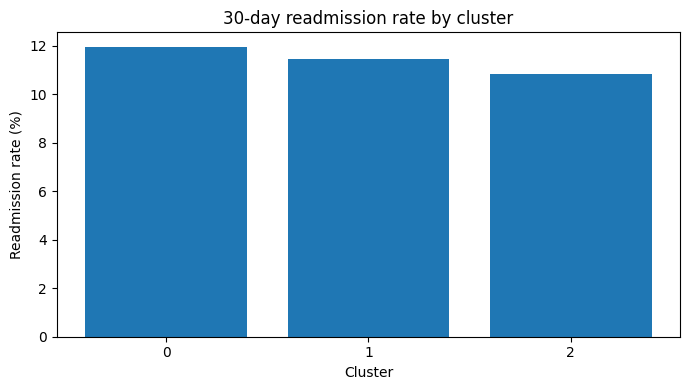

In [106]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

cluster_readmission_pd = (
    clustered_df
    .withColumn("readmitted_binary", F.when(F.col("readmitted") == "<30", 1).otherwise(0))
    .groupBy("cluster")
    .agg(
        F.count("*").alias("count"),
        F.avg("readmitted_binary").alias("readmission_rate")
    )
    .orderBy("cluster")
    .toPandas()
)

cluster_readmission_pd["readmission_rate_pct"] = (cluster_readmission_pd["readmission_rate"] * 100).round(2)
display(cluster_readmission_pd[["cluster", "count", "readmission_rate_pct"]])

plt.figure(figsize=(7, 4))
plt.bar(cluster_readmission_pd["cluster"].astype(str), cluster_readmission_pd["readmission_rate_pct"])
plt.title("30-day readmission rate by cluster")
plt.xlabel("Cluster")
plt.ylabel("Readmission rate (%)")
plt.tight_layout()
plt.show()

### Observation
The clusters do show differences in 30-day readmission risk, although the gap is moderate rather than extreme. Cluster 0 has the highest readmission rate at 11.96%, followed by Cluster 1 at 11.45%, while Cluster 2 has the lowest rate at 10.85%, which still supports testing local cluster-specific classifiers in the next stage.

### 8. Assign clinical labels to the clusters

The clusters were given simple clinical-style labels based on their size, utilisation patterns, treatment burden, diagnosis composition, and readmission rates.

| Cluster | Clinical label | Reason |
|---|---|---|
| 0 | Smaller digestive-oriented higher-risk subgroup | Smallest cluster, highest readmission rate, digestive diagnosis pattern |
| 1 | Higher-treatment circulatory subgroup | Higher medication and procedure burden, circulatory diagnosis dominance |
| 2 | Broader lower-intensity subgroup | Largest cluster, lower treatment intensity, lowest readmission rate |


# 7. Cluster-Based Classification

This section evaluates whether building separate classifiers within clusters can improve prediction compared with the single global distributed model. The aim is to test whether the subgroup structure identified by clustering is strong enough to support more effective local readmission models.

## 1. Build local classifiers within each cluster

This subsection trains one local classifier inside each cluster using the same improved distributed feature preparation. The aim is to check whether separate models can capture cluster-specific readmission patterns more effectively than a single global classifier.

In [107]:
from pyspark.sql import functions as F
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import pandas as pd

local_results = []

roc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

for cluster_id in [0, 1, 2]:
    cluster_subset = (
        clustered_df
        .filter(F.col("cluster") == cluster_id)
        .withColumn("label", F.when(F.col("readmitted") == "<30", 1).otherwise(0))
        .select("label", F.col("cluster_features").alias("features"))
    )

    local_train_df, local_test_df = cluster_subset.randomSplit([0.8, 0.2], seed=42)

    local_lr = LogisticRegression(
        featuresCol="features",
        labelCol="label",
        maxIter=100,
        regParam=0.0,
        elasticNetParam=0.0
    )

    local_model = local_lr.fit(local_train_df)
    local_preds = local_model.transform(local_test_df)

    tp = local_preds.filter((F.col("label") == 1) & (F.col("prediction") == 1)).count()
    tn = local_preds.filter((F.col("label") == 0) & (F.col("prediction") == 0)).count()
    fp = local_preds.filter((F.col("label") == 0) & (F.col("prediction") == 1)).count()
    fn = local_preds.filter((F.col("label") == 1) & (F.col("prediction") == 0)).count()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    roc_auc = roc_evaluator.evaluate(local_preds)

    local_results.append({
        "cluster": cluster_id,
        "train_rows": local_train_df.count(),
        "test_rows": local_test_df.count(),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "roc_auc": round(roc_auc, 4)
    })

local_results_pd = pd.DataFrame(local_results)
display(local_results_pd)

,cluster,train_rows,test_rows,TN,FP,FN,TP,precision,recall,f1,roc_auc
0,0,3165,765,680,2,80,3,0.6000,0.0361,0.0682,0.6304
1,1,35871,8699,7671,9,1016,3,0.2500,0.0029,0.0058,0.6049
2,2,42783,10483,9270,19,1165,29,0.6042,0.0243,0.0467,0.6488


### Observation
The unbalanced local cluster models do not yet perform strongly on minority-class readmission detection. Cluster 0 has the best local recall (0.0361) and F1-score (0.0682), while Clusters 1 and 2 remain very weak, so balancing within clusters is still needed.

## 2. Evaluate local cluster models

This subsection compares the performance of the local classifiers across the three clusters. The aim is to identify whether any cluster already shows stronger subgroup-specific prediction before applying balancing within each cluster.

,cluster,train_rows,test_rows,precision,recall,f1,roc_auc
0,0,3165,765,0.6000,0.0361,0.0682,0.6304
1,1,35871,8699,0.2500,0.0029,0.0058,0.6049
2,2,42783,10483,0.6042,0.0243,0.0467,0.6488


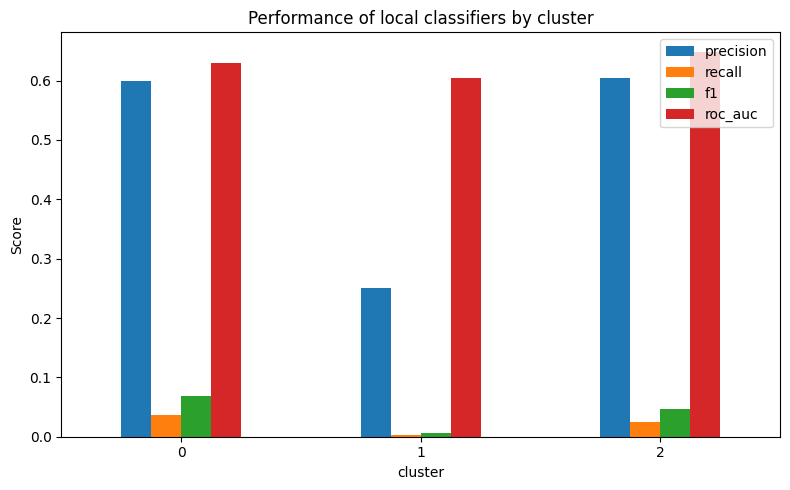

In [108]:
import matplotlib.pyplot as plt

display(local_results_pd[["cluster", "train_rows", "test_rows", "precision", "recall", "f1", "roc_auc"]])

plot_df = local_results_pd.set_index("cluster")[["precision", "recall", "f1", "roc_auc"]]
plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Performance of local classifiers by cluster")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation
The unbalanced local models remain weak across all three clusters, especially for recall and F1-score. Cluster 0 performs best among them, but all three results show that balancing within clusters is needed before judging whether local modelling is genuinely beneficial.

## 3. Balance cluster-level data and retrain the local classifiers

This subsection balances the training data separately inside each cluster and retrains the local classifiers. The aim is to extend the earlier imbalance-handling logic into the cluster-based setting so that each local model has a better chance of detecting the minority `<30` readmission class.

In [109]:
from pyspark.sql import functions as F
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import pandas as pd

balanced_local_results = []

roc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

for cluster_id in [0, 1, 2]:
    cluster_subset = (
        clustered_df
        .filter(F.col("cluster") == cluster_id)
        .withColumn("label", F.when(F.col("readmitted") == "<30", 1).otherwise(0))
        .select("label", F.col("cluster_features").alias("features"))
    )

    local_train_df, local_test_df = cluster_subset.randomSplit([0.8, 0.2], seed=42)

    minority_train = local_train_df.filter(F.col("label") == 1)
    majority_train = local_train_df.filter(F.col("label") == 0)

    minority_count = minority_train.count()
    majority_count = majority_train.count()

    majority_sampled = majority_train.orderBy(F.rand(seed=42 + cluster_id)).limit(minority_count)
    balanced_train_df = minority_train.unionByName(majority_sampled)

    local_lr = LogisticRegression(
        featuresCol="features",
        labelCol="label",
        maxIter=100,
        regParam=0.0,
        elasticNetParam=0.0
    )

    balanced_local_model = local_lr.fit(balanced_train_df)
    balanced_local_preds = balanced_local_model.transform(local_test_df)

    tp = balanced_local_preds.filter((F.col("label") == 1) & (F.col("prediction") == 1)).count()
    tn = balanced_local_preds.filter((F.col("label") == 0) & (F.col("prediction") == 0)).count()
    fp = balanced_local_preds.filter((F.col("label") == 0) & (F.col("prediction") == 1)).count()
    fn = balanced_local_preds.filter((F.col("label") == 1) & (F.col("prediction") == 0)).count()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    roc_auc = roc_evaluator.evaluate(balanced_local_preds)

    balanced_local_results.append({
        "cluster": cluster_id,
        "train_rows_before_balancing": local_train_df.count(),
        "minority_train_rows": minority_count,
        "majority_train_rows": majority_count,
        "train_rows_after_balancing": balanced_train_df.count(),
        "test_rows": local_test_df.count(),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "roc_auc": round(roc_auc, 4)
    })

balanced_local_results_pd = pd.DataFrame(balanced_local_results)
display(balanced_local_results_pd)

,cluster,train_rows_before_balancing,minority_train_rows,majority_train_rows,train_rows_after_balancing,test_rows,TN,FP,FN,TP,precision,recall,f1,roc_auc
0,0,3165,387,2778,774,765,447,235,42,41,0.1486,0.4940,0.2284,0.6120
1,1,35871,4086,31785,8172,8699,4976,2704,514,505,0.1574,0.4956,0.2389,0.6053
2,2,42783,4588,38195,9176,10483,6179,3110,566,628,0.1680,0.5260,0.2547,0.6453


### Observation
Balancing within clusters improved all three local models substantially, with recall increasing to around 0.49–0.53 and F1-score increasing to around 0.23–0.25. Cluster 2 now performs best overall, while Clusters 0 and 1 also become much more useful for minority-class readmission detection than their unbalanced versions.

## 4. Compare local classifiers with the global distributed model

This subsection compares the balanced local cluster-specific classifiers with the improved global distributed classifier. The aim is to test whether modelling patients within smaller subgroups provides any performance advantage over a single weighted global Spark model.

,model,precision,recall,f1,roc_auc
0,Global weighted distributed model,0.1695,0.5250,0.2563,0.6451
1,Local balanced model - Cluster 0,0.1486,0.4940,0.2284,0.6120
2,Local balanced model - Cluster 1,0.1574,0.4956,0.2389,0.6053
3,Local balanced model - Cluster 2,0.1680,0.5260,0.2547,0.6453


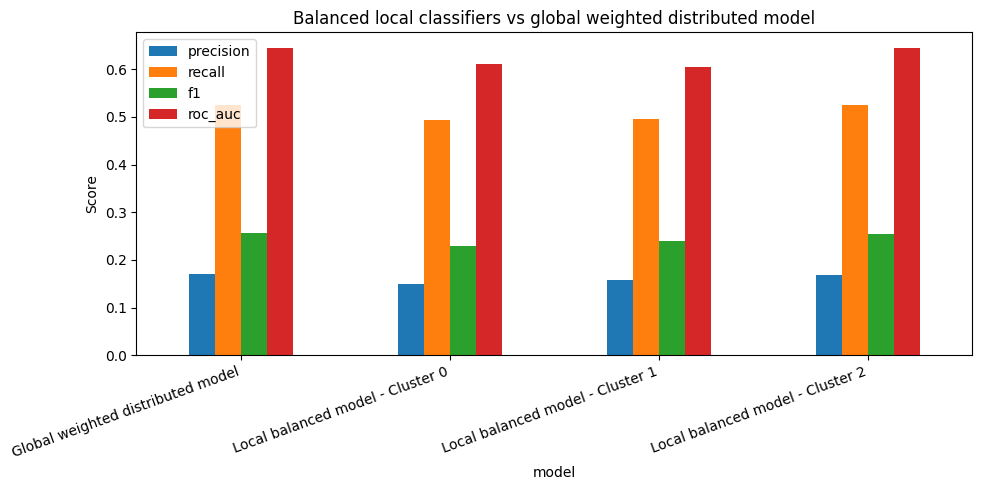

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

global_weighted_row = pd.DataFrame({
    "model": ["Global weighted distributed model"],
    "precision": [0.1695],
    "recall": [0.5250],
    "f1": [0.2563],
    "roc_auc": [0.6451]
})

local_comparison_df = balanced_local_results_pd[["cluster", "precision", "recall", "f1", "roc_auc"]].copy()
local_comparison_df["model"] = local_comparison_df["cluster"].apply(lambda x: f"Local balanced model - Cluster {x}")
local_comparison_df = local_comparison_df[["model", "precision", "recall", "f1", "roc_auc"]]

final_model_comparison_df = pd.concat([global_weighted_row, local_comparison_df], ignore_index=True)
display(final_model_comparison_df)

plot_df = final_model_comparison_df.set_index("model")[["precision", "recall", "f1", "roc_auc"]]
plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Balanced local classifiers vs global weighted distributed model")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Observation
The balanced local classifiers do not clearly outperform the global weighted distributed model overall. Cluster 2 comes closest, with recall 0.5260 and ROC-AUC 0.6453, but the global weighted model still has the strongest overall F1-score at 0.2563, so cluster-based modelling provides only limited improvement in this case.

## 5. Final summary

Balancing within clusters improved the local models, but the balanced local classifiers did not clearly outperform the weighted global distributed model overall. Cluster 2 came closest, with slightly higher recall and ROC-AUC, but the global weighted model still had the strongest overall F1-score. This suggests that cluster-based classification is most beneficial when the clusters represent more clearly separated risk profiles and are large enough to support stable local training. In this coursework, the clusters were useful for subgroup interpretation and for improving local models after balancing, but their predictive advantage over the weighted global model remained limited. Overall, distributed preprocessing and class-weighted global modelling were more beneficial than cluster-based local classification for final predictive performance.

# Generative AI usage 
### Generative AI (ChatGPT) was used to clarify coursework requirements.
### It was also used to help interpret Python errors and path issues.
### In addition, it was used to support understanding of different modelling methods and how they work.